# SBER AI Journey 2026 — 3D Mesh Quality Control
## Версия 7: два бэкбона в один проход

**Метрика:** `10 · F1(quality) + 10 · F1_weighted(10 дефектов)`, максимум 20.

### Как запускать

`Runtime -> Run all`. Один проход сверху вниз делает всё: качает данные, считает признаки,
обучает **две** конфигурации сети подряд, ансамблирует их, строит второй уровень и пишет
`submission.csv`. Переподключаться и что-то запускать вручную не требуется.

Если сессия оборвётся — просто `Run all` заново. Всё тяжёлое лежит на Google Drive
(`CFG.drive_dir`), и каждый шаг сначала проверяет, не посчитан ли он уже: кэш рендеров,
таблицы признаков, CLIP, чекпоинты обучения с состоянием ГСЧ, предсказания фолдов,
модели второго уровня, решающее правило. Обучение продолжается **с той же эпохи**,
а не с нуля.

### Почему два бэкбона

Правило отбора в ансамбль — не сила модели, а **некоррелированность её ошибок**. ViT режет
картинку на патчи и сразу смотрит глобально; ConvNeXt свёрточный, наращивает контекст
постепенно и лучше улавливает локальную текстуру поверхности — а это ровно то, чем
различаются `noisy` и `lowpoly`. Ансамбль двух разумных конфигураций складывается
предсказуемо, одиночные архитектурные улучшения — нет.

Обе конфигурации объявлены в §1 как `CONFIG_A` и `CONFIG_B`, и им соответствуют две
отдельные ячейки-прогона (§9A и §9B) с явными значениями — чтобы было видно, что именно
меняется между ними.

### История прогонов

| версия | OOF | вложенная | лидерборд |
|---|---|---|---|
| 4 (DINOv2 + CLIP) | 14.90 | — | — |
| 5 (+ самопересечения, качество треугольников) | 14.474 | **14.124** | 14.987 |
| 7 (эта) | — | — | — |

Ориентир — **вложенная** оценка, а не OOF. На прошлом прогоне OOF показывал 14.474,
вложенная — 14.124, а лидерборд дал 14.987 при собственном бутстрапе [13.45, 14.95]:
то есть 14.99 было верхней границей интервала, а не реальным уровнем решения.


## 0.1. Что изменено против прогона, давшего 14.99

Каждый пункт отвечает на вопрос «какой конкретно дефект прошлого прогона он чинит».

| # | изменение | что было не так |
|---|---|---|
| 1 | **Два бэкбона в одном проходе** (§9A, §9B) и ансамбль (§9C) | прошлый прогон был одиночной моделью; §9.2 предлагала ансамбль, но требовала ручного второго запуска, которого не случилось |
| 2 | **DINOv3** (LVD-1689M) вместо DINOv2 (142M) | тот же тип признаков, на порядок больше претрейна; patch16 при 224 даёт 196 токенов против 256 — прогон ещё и дешевле |
| 3 | **10 эпох вместо 16** | в логе прошлого прогона лучшая эпоха приходилась на 4–9 из 16, дальше метрика падала на 0.2–0.4 и не восстанавливалась. Освободившееся время идёт на второй бэкбон |
| 4 | **Раздельный кэш признаков**: геометрия считается один раз, силуэты — по `tile` | раньше всё кэшировалось под именем с `tile`, и второй прогон с другим разрешением пересчитывал бы геометрию (сварка, топология, самопересечения на 9633 мешах) — часы впустую |
| 5 | **CLIP читается через DataLoader** | декодирование PNG шло в один поток в теле цикла: 83 минуты при простаивающем GPU |
| 6 | **Кросс-вью трансформер** + кодирование ракурса | прежняя схема (общий бэкбон + attention-pooling) была полностью инвариантна к порядку видов и не могла отличить ракурс сверху от азимутального — при том что `partial` определён именно через ракурсы |
| 7 | **Циклическая аугментация азимутов + TTA ×8** | поворот на 90° переименовывает виды по кругу, множество картинок не меняется → все метки инвариантны. Гипотеза о раскладке проверяется данными (§7) и авто-отключается, если не подтвердится |
| 8 | **Soft-F1 в лоссе** с весами самой метрики | обучались на правдоподобии, оценивались взвешенным F1. Классы, которых нет в батче, маскируются — иначе soft-F1 давит `intersection`/`scale` в ноль |
| 9 | **Голова «число дефектов» + согласование `quality`** | `quality = 1` ⟺ ни одного дефекта, но 11-я голова об этом не знала |
| 10 | **EMA весов** | бесплатно по времени, каждую эпоху сравнивается с сырыми весами |
| 11 | **Спектр Лапласа-Бельтрами** | глобальный инвариант формы; §14.E прошлого разбора, так и не реализованный |
| 12 | **Бэггинг решающего правила + ранговый бленд, выбор по вложенной оценке** | разрыв OOF 14.474 против вложенной 14.124 — 0.35 балла чистого переобучения правила |
| 13 | **Пороги по целевой доле вместо абсолютных** (§12) | вероятность OOF даёт одна модель, тестовая — среднее пяти фолдов и двух прогонов; среднее менее разбросано, и один и тот же порог отсекает на тесте другую долю объектов |
| 14 | **Исправлен выбор порога при совпадающих вероятностях** | порог попадал между двумя одинаковыми `p`, и `p > th` выбрасывал оба объекта |

### Чего ожидать

| источник прироста | вклад к вложенной оценке |
|---|---|
| ансамбль двух бэкбонов | +0.3 … +0.6 |
| бэггинг правила + пороги по доле | +0.2 … +0.5 |
| DINOv3, кросс-вью, soft-F1, EMA, спектр | +0.3 … +0.8 |
| **итого от 14.12** | **≈ 14.9 … 16.0** |

Диапазон честно включает значения ниже 16. Обещать 16 нельзя: при тесте в 669 объектов
одна и та же модель даёт разброс ±0.4 балла (§9.1), так что даже хорошее решение может
показать и 15.5, и 16.3.


## 0. Установка зависимостей

In [1]:
!pip -q install kagglehub 'timm>=1.0.20' lightgbm iterative-stratification pyarrow open_clip_torch --upgrade
!pip -q install scikit-learn pandas matplotlib tqdm pillow scipy
# timm >= 1.0.20 обязателен: именно с этой версии в нём есть веса DINOv3.
# Если Colab ругается на несовместимость — Runtime -> Restart session и выполнить заново.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.6 MB/s eta 0:00:00


## 1. Конфиг и seed

Все ручки собраны здесь. `RUN_ALL_FOLDS=False` — быстрый режим (1 фолд, ~1.5 ч на T4).
Для финального сабмита ставим `RUN_ALL_FOLDS=True` (5 фолдов, ~7 ч на T4 / ~2 ч на A100).

In [2]:
import os, gc, json, math, random, re, sys, time, copy, warnings, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#fbfbfd',
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
})
PAL = {'good': '#2e9e5b', 'bad': '#d1495b', 'warn': '#e8a33d', 'main': '#2d6cdf',
       'alt': '#8a4fbd', 'grey': '#9aa0a6', 'dark': '#1f2933'}


class CFG:
    seed = 42

    # ---- данные ----
    dataset  = 'daniilantonov5/3d-mesh-quality-control'
    work     = Path('/content/work'); work.mkdir(parents=True, exist_ok=True)
    cache    = work / 'cache';        cache.mkdir(parents=True, exist_ok=True)

    # ---- вход CNN ----
    view_mode = 'multiview'
    tile      = 224                 # переопределяется конфигурацией прогона

    # ---- бэкбон (переопределяется конфигурацией) ----
    backbone    = 'vit_small_patch16_dinov3.lvd1689m'
    backbone_lr = 5e-5
    layer_decay = 0.75
    drop_rate   = 0.2
    drop_path   = 0.1
    batch_size  = 10
    accum       = 3
    run_tag     = 'A'

    # ---- обучение (общее для обоих прогонов) ----
    # 10, а не 16: в логе прошлого прогона лучшая эпоха приходилась на 4-9 из 16,
    # дальше метрика падала и не восстанавливалась. Освободившееся время идёт
    # на второй бэкбон, который даёт предсказуемый прирост, в отличие от лишних эпох.
    epochs     = 10
    mixup      = 0.4
    lr         = 3e-4
    head_lr_mult = 10.0
    weight_decay = 0.05
    warmup_frac  = 0.1
    label_smooth = 0.01
    amp        = True
    num_workers = 4

    # ---- кросс-вью блок ----
    xview_layers = 2
    xview_dim    = 384
    view_pos     = True
    cyclic_aug   = True
    azimuth_idx  = [0, 1, 2, 3]
    pole_idx     = [4, 5]

    # ---- составная функция потерь ----
    asl_weight = 0.45
    softf1_w   = 0.35
    softf1_q   = 0.5
    count_w    = 0.10
    consist_w  = 0.05

    use_ema   = True
    ema_decay = 0.999

    # ---- дополнительные источники ----
    use_clip   = True
    clip_model = ('ViT-B-32', 'laion2b_s34b_b79k')
    use_dino_frozen = True
    dino_frozen_model = 'vit_base_patch16_dinov3.lvd1689m'
    dino_pca   = 128
    # Спектр лапласиана ВЫКЛЮЧЕН по умолчанию: ожидаемый вклад +0.05...0.2 — самый
    # слабый пункт версии 7, а расчёт замерен в ~10 c/меш, то есть часы на train.
    # Включайте только если время девать некуда (и тогда см. SPEC_VCAP в §5).
    use_spectral = False

    # ---- CV ----
    n_folds = 5
    RUN_ALL_FOLDS = True
    folds_to_run  = [0]

    # ---- инференс ----
    tta = 'flip+cyclic'
    n_snapshots = 3

    # ---- устойчивость к перезапускам ----
    use_drive  = True
    drive_dir  = '/content/drive/MyDrive/sber_meshqc_v7'
    resume     = True
    ckpt_every = 1
    ckpt_fp16  = True
    keep_fold_ckpt = False
    force_recompute = []

    live_plot_every = 0          # 0 = не перерисовывать дашборд внутри обучения
    verbose_epoch   = True

    artifact_cols = ['abstract','artifacts','intersection','lowpoly','noisy',
                     'open','partial','scale','set','simple']
    target_cols   = artifact_cols + ['quality']
    n_targets     = 11

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# =====================================================================================
#  ДВЕ КОНФИГУРАЦИИ ОДНОГО ПРОГОНА
#
#  Зачем два бэкбона. Правило отбора в ансамбль — не сила модели, а НЕКОРРЕЛИРОВАННОСТЬ
#  её ошибок. ViT режет картинку на патчи и сразу смотрит глобально; ConvNeXt свёрточный
#  и наращивает контекст постепенно, лучше улавливая локальную текстуру поверхности —
#  а это ровно то, чем различаются noisy и lowpoly. Ансамбль двух разумных конфигураций
#  складывается предсказуемо (+0.3…0.6), одиночные архитектурные улучшения — нет.
#
#  Оба прогона идут в ОДИН проход ноутбука, артефакты изолированы по run_tag, и любой
#  уже посчитанный шаг подхватывается с Drive. Если сессия оборвётся — просто Run all
#  заново, посчитанное не пересчитывается.
# =====================================================================================
CONFIG_A = dict(
    run_tag     = 'dinov3s_224',
    backbone    = 'vit_small_patch16_dinov3.lvd1689m',
    tile        = 224,
    backbone_lr = 5e-5,
    layer_decay = 0.75,
    batch_size  = 10,
    accum       = 3,
    xview_dim   = 384,
)

CONFIG_B = dict(
    run_tag     = 'cnxs_256',
    backbone    = 'convnext_small.dinov3_lvd1689m',
    tile        = 256,            # свёрточной сети размер не обязан быть кратен патчу
    backbone_lr = 1e-4,           # свёртки переносят больший LR, чем ViT после SSL
    layer_decay = 1.0,            # послойное затухание — приём для ViT, здесь не нужен
    batch_size  = 8,
    accum       = 4,
    xview_dim   = 384,
)

CONFIGS = [CONFIG_A, CONFIG_B]

if CFG.RUN_ALL_FOLDS:
    CFG.folds_to_run = list(range(CFG.n_folds))


def seed_everything(seed=CFG.seed):
    random.seed(seed); np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything()


class Reporter:
    W = 86
    _t0 = {}

    @classmethod
    def section(cls, title, sub=''):
        print('\n' + '=' * cls.W); print(f'  {title}')
        if sub: print(f'  {sub}')
        print('=' * cls.W)
        cls._t0[title] = time.time()

    @classmethod
    def done(cls, title, extra=''):
        dt = time.time() - cls._t0.get(title, time.time())
        print(f'  [OK] {title} — {dt / 60:.1f} мин' + (f' | {extra}' if extra else ''))

    @staticmethod
    def kv(**kw):
        for k, v in kw.items(): print(f'    {k:<30s} {v}')

    @staticmethod
    def ok(m): print(f'  [+] {m}')

    @staticmethod
    def warn(m): print(f'  [!] {m}')

    @staticmethod
    def fail(m): print(f'  [x] {m}')

    @staticmethod
    def bar(v, lo=10, hi=20, w=36, label=''):
        f = 0.0 if hi <= lo else max(0.0, min(1.0, (v - lo) / (hi - lo)))
        n = int(round(f * w))
        print(f'    {label:<20s} |{"█" * n}{"·" * (w - n)}| {v:.3f}')


R = Reporter
IS_VIT = True


def apply_config(cfg):
    """Переключает CFG на конфигурацию прогона. Вызывается перед каждым обучением."""
    global IS_VIT
    for k, v in cfg.items():
        setattr(CFG, k, v)
    IS_VIT = any(k in CFG.backbone for k in ('vit_', 'dinov2', 'dinov3', 'deit', 'eva'))
    if IS_VIT:
        patch = 16 if 'patch16' in CFG.backbone else (14 if 'patch14' in CFG.backbone else 8)
        if CFG.tile % patch:
            CFG.tile = int(round(CFG.tile / patch) * patch)
            R.warn(f'tile округлён до кратного патчу {patch}: {CFG.tile}')
    return CFG


RUN_T0 = time.time()

R.section('Конфигурация')
R.kv(**{'устройство': f'{CFG.device} '
                      f'({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"})',
        'прогонов в этом ноутбуке': len(CONFIGS),
        'эпох x фолдов на прогон': f'{CFG.epochs} x {len(CFG.folds_to_run)}',
        'loss': f'BCE {1 - CFG.asl_weight:.2f} + ASL {CFG.asl_weight:.2f} + '
                f'softF1 {CFG.softf1_w:.2f} + count {CFG.count_w:.2f} + consist {CFG.consist_w:.2f}',
        'EMA': f'decay={CFG.ema_decay}' if CFG.use_ema else 'выкл',
        'TTA': CFG.tta})
for i, c in enumerate(CONFIGS):
    R.kv(**{f'прогон {chr(65 + i)}': f"{c['run_tag']}: {c['backbone']} @ {c['tile']}"})

try:
    import timm
    _tv = tuple(int(x) for x in timm.__version__.split('.')[:3])
    if _tv < (1, 0, 20):
        R.fail(f'timm {timm.__version__} < 1.0.20 — веса DINOv3 не подхватятся. '
               f'Выполните §0 и Runtime -> Restart session.')
    else:
        R.ok(f'timm {timm.__version__}')
except Exception as e:
    R.warn(f'timm ещё не импортирован: {e}')



  Конфигурация
    устройство                     cuda (NVIDIA A100-SXM4-40GB)
    прогонов в этом ноутбуке       2
    эпох x фолдов на прогон        10 x 5
    loss                           BCE 0.55 + ASL 0.45 + softF1 0.35 + count 0.10 + consist 0.05
    EMA                            decay=0.999
    TTA                            flip+cyclic
    прогон A                       dinov3s_224: vit_small_patch16_dinov3.lvd1689m @ 224
    прогон B                       cnxs_256: convnext_small.dinov3_lvd1689m @ 256
  [+] timm 1.0.29


## 1.1. Чекпоинты, кэш и возобновление

Colab рвёт сессию по таймауту и по лимиту GPU, а `/content` стирается **вместе с рантаймом**.
Поэтому весь прогресс уезжает на Google Drive, и каждый тяжёлый шаг сначала проверяет,
не посчитан ли он уже.

| артефакт | чем сохраняется | что даёт при обрыве |
|---|---|---|
| кэш рендеров (`img_*`) | PNG на диске | пересобираются только недостающие файлы |
| таблицы фич | parquet + чекпоинт раз в 1024 объекта | продолжает с последнего чанка |
| список фич после дедупликации | `joblib` | не пересчитывается |
| **состояние обучения фолда** | `torch.save`: веса, оптимизатор, scheduler, scaler, снапшоты, состояния ГСЧ | обучение продолжается **с той же эпохи**, а не с нуля |
| предсказания фолда (OOF + тест) | `joblib` | готовый фолд пропускается целиком |
| модели и предсказания GBM / стэкинга | `joblib` | не переобучаются |
| решающее правило | `joblib` | — |
| лог обучения по эпохам | дописываемый CSV | нужен для презентации (критерий «логи экспериментов») |

Запись **атомарная** (во временный файл, затем `os.replace`): обрыв прямо во время сохранения
не оставит битый чекпоинт. Состояния ГСЧ тоже в чекпоинте, поэтому продолженное обучение
идёт по той же траектории, что и непрерывное.

In [3]:
import joblib, zipfile, time

if CFG.use_drive:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        CFG.work = Path(CFG.drive_dir)
    except Exception as e:
        print('Drive недоступен, работаем в /content/work — прогресс исчезнет при перезапуске:', e)
CFG.work.mkdir(parents=True, exist_ok=True)
CFG.cache = CFG.work / 'cache'; CFG.cache.mkdir(parents=True, exist_ok=True)
ART  = CFG.work / 'artifacts'; ART.mkdir(parents=True, exist_ok=True)
CKPT = CFG.work / 'ckpt';      CKPT.mkdir(parents=True, exist_ok=True)
LOG_CSV = CFG.work / 'training_log.csv'
R.section('Хранилище и чекпоинты')
R.kv(**{'рабочая директория': CFG.work})

def _atomic(path, writer):
    """Пишем во временный файл рядом и подменяем: обрыв не испортит существующий артефакт."""
    path = Path(path)
    tmp = path.with_suffix(path.suffix + '.tmp')
    writer(tmp)
    os.replace(tmp, path)

def art_path(name):
    return ART / f'{name}.joblib'

def rt(name):
    """Имя артефакта, привязанное к конфигурации прогона (run_tag)."""
    return f'{CFG.run_tag}_{name}'

def has_artifact(name):
    return art_path(name).exists() and name not in CFG.force_recompute

def save_artifact(name, obj, compress=3):
    _atomic(art_path(name), lambda p: joblib.dump(obj, p, compress=compress))
    return obj

def load_artifact(name):
    return joblib.load(art_path(name))

def cached(name, fn, compress=3):
    """Единая точка «проверить существование -> иначе посчитать и сохранить»."""
    if CFG.resume and has_artifact(name):
        obj = load_artifact(name)
        print(f'  [кэш] {name}: загружено')
        return obj
    t0 = time.time()
    obj = fn()
    save_artifact(name, obj, compress=compress)
    print(f'  [новое] {name}: посчитано за {time.time() - t0:.0f} c')
    return obj

# ---- состояния генераторов случайных чисел (для точного продолжения обучения) ----
def rng_state():
    st = {'py': random.getstate(), 'np': np.random.get_state(), 'torch': torch.get_rng_state()}
    if torch.cuda.is_available():
        st['cuda'] = torch.cuda.get_rng_state_all()
    return st

def set_rng_state(st):
    try:
        random.setstate(st['py']); np.random.set_state(st['np'])
        torch.set_rng_state(st['torch'].cpu() if torch.is_tensor(st['torch']) else st['torch'])
        if 'cuda' in st and torch.cuda.is_available():
            torch.cuda.set_rng_state_all([s.cpu() if torch.is_tensor(s) else s for s in st['cuda']])
    except Exception as e:
        print('  не удалось восстановить состояние ГСЧ (продолжаем с текущим):', e)

# ---- чекпоинт обучения фолда ----
def _to_fp16(sd):
    return {k: (v.half() if torch.is_tensor(v) and v.is_floating_point() else v)
            for k, v in sd.items()}

def _to_fp32(sd):
    return {k: (v.float() if torch.is_tensor(v) and v.is_floating_point() else v)
            for k, v in sd.items()}

def save_ckpt(fold, payload):
    _atomic(CKPT / f'{CFG.run_tag}_fold{fold}.pt', lambda p: torch.save(payload, p))

def load_ckpt(fold):
    p = CKPT / f'{CFG.run_tag}_fold{fold}.pt'
    if not (CFG.resume and p.exists()):
        return None
    try:
        return torch.load(p, map_location='cpu', weights_only=False)
    except Exception as e:
        print(f'  чекпоинт фолда {fold} не читается ({e}), начинаем фолд заново')
        return None

def drop_ckpt(fold):
    p = CKPT / f'{CFG.run_tag}_fold{fold}.pt'
    if p.exists() and not CFG.keep_fold_ckpt:
        p.unlink()

def log_epoch(row):
    """Дописываемый лог: переживает обрывы, нужен для отчёта об экспериментах."""
    df = pd.DataFrame([row])
    header = not LOG_CSV.exists()
    df.to_csv(LOG_CSV, mode='a', header=header, index=False)

done_folds = sorted(p.stem for p in ART.glob(f'{CFG.run_tag}_fold*_preds.joblib'))
R.kv(**{'посчитанные фолды': done_folds or 'нет',
        'незавершённые чекпоинты': [p.name for p in CKPT.glob(f'{CFG.run_tag}_fold*.pt')] or 'нет'})

Mounted at /content/drive

  Хранилище и чекпоинты
    рабочая директория             /content/drive/MyDrive/sber_meshqc_v7
    посчитанные фолды              нет
    незавершённые чекпоинты        нет


## 2. Загрузка датасета с Kaggle

Структура на Kaggle: `train/train/{item_id}.png|.npz`, `test/test/...`, плюс `train.csv`, `test.csv`, `submission.csv`.
Пути ищем автопоиском, чтобы ноутбук не ломался при переименовании папок.

In [4]:
import kagglehub

root = Path(kagglehub.dataset_download(CFG.dataset))
print('dataset root:', root)

def _pick_dir(mode):
    """Папка с максимальным числом .npz, в пути которой встречается train/test."""
    best, best_n = None, -1
    for p in root.rglob('*'):
        if not p.is_dir():
            continue
        if mode not in str(p).lower():
            continue
        n = sum(1 for _ in p.glob('*.npz'))
        if n > best_n:
            best, best_n = p, n
    if best is None or best_n == 0:
        raise FileNotFoundError(f'не найдена папка с .npz для {mode}')
    return best

def _pick_csv(mode):
    cands = list(root.rglob('*.csv'))
    def score(p):
        n = p.name.lower(); s = 0
        if mode == 'train':
            s += 10 * ('train' in n) - 20 * ('submission' in n) - 20 * ('test' in n)
        else:
            s += 10 * ('test' in n) - 5 * ('submission' in n) - 20 * ('train' in n)
        return s - 0.001 * len(n)
    return sorted(cands, key=score, reverse=True)[0]

TRAIN_DIR, TEST_DIR = _pick_dir('train'), _pick_dir('test')
TRAIN_CSV, TEST_CSV = _pick_csv('train'), _pick_csv('test')
print('train dir :', TRAIN_DIR, len(list(TRAIN_DIR.glob('*.npz'))), 'npz /',
      len(list(TRAIN_DIR.glob('*.png'))), 'png')
print('test  dir :', TEST_DIR,  len(list(TEST_DIR.glob('*.npz'))),  'npz /',
      len(list(TEST_DIR.glob('*.png'))),  'png')
print('train csv :', TRAIN_CSV)
print('test  csv :', TEST_CSV)

train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)[['item_id']].copy()
train_df['item_id'] = train_df['item_id'].astype(str)
test_df['item_id']  = test_df['item_id'].astype(str)

if 'quality' not in train_df.columns:
    train_df['quality'] = (train_df[CFG.artifact_cols].sum(1) == 0).astype(int)

print(train_df.shape, test_df.shape)
train_df.head()

Using Colab cache for faster access to the '3d-mesh-quality-control' dataset.
dataset root: /kaggle/input/3d-mesh-quality-control
train dir : /kaggle/input/3d-mesh-quality-control/train (2)/train 8964 npz / 8964 png
test  dir : /kaggle/input/3d-mesh-quality-control/test (1)/test 669 npz / 669 png
train csv : /kaggle/input/3d-mesh-quality-control/train.csv
test  csv : /kaggle/input/3d-mesh-quality-control/test (1).csv
(8964, 12) (669, 1)


,item_id,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
0,0001be62-bf9c-4c15-8a09-dce209be9715,0,1,0,0,0,0,0,0,0,0,0
1,000ad3b9-75cf-4b8f-9786-de63f9a8ffa8,0,0,0,0,0,0,0,0,0,1,0
2,0012e069-5caf-44fd-85e4-9a38f6eefd2e,0,0,0,0,0,0,0,0,0,1,0
3,0024dc8f-a2d7-4556-94dc-6b4b0f46ca0d,1,0,0,1,0,0,0,0,0,0,0
4,002b097b-4237-4610-952c-6095d48fb7a0,0,0,0,0,0,0,0,0,0,1,0


## 3. EDA: что реально приносит баллы

Три вещи, которые нужно увидеть до обучения:
1. `quality == (сумма дефектов == 0)` — проверяем тождество на train;
2. **веса** во второй половине метрики (`average='weighted'` взвешивает по support истинных меток) — редкие классы почти не влияют на скор, а `noisy`/`simple` влияют сильно;
3. **матрица корреляций/ко-встречаемости** — основа для stacking-а.

In [5]:
n = len(train_df)
prev = train_df[CFG.target_cols].mean()
derived = (train_df[CFG.artifact_cols].sum(1) == 0).astype(int)
print('quality == (no defects) для всех строк:', bool((derived == train_df['quality']).all()))
print('объектов:', n)

sup = train_df[CFG.artifact_cols].sum()
w   = sup / sup.sum()
eda = pd.DataFrame({'prevalence': prev[CFG.artifact_cols].round(4),
                    'support': sup,
                    'weight_in_metric': w.round(4),
                    'max_points': (10 * w).round(3)}).sort_values('weight_in_metric', ascending=False)
display(eda)
print('\n>>> Вывод: noisy+simple+abstract+lowpoly = %.1f%% веса второй половины метрики.'
      % (100 * w[['noisy','simple','abstract','lowpoly']].sum()))
print('>>> intersection и scale вместе стоят < %.2f балла — их не надо вылизывать.'
      % (10 * w[['intersection','scale']].sum()))

quality == (no defects) для всех строк: True
объектов: 8964


,prevalence,support,weight_in_metric,max_points
noisy,0.2844,2549,0.2746,2.746
simple,0.2152,1929,0.2078,2.078
abstract,0.1332,1194,0.1286,1.286
lowpoly,0.1235,1107,0.1192,1.192
set,0.1044,936,0.1008,1.008
open,0.0607,544,0.0586,0.586
artifacts,0.0485,435,0.0469,0.469
partial,0.0419,376,0.0405,0.405
intersection,0.0119,107,0.0115,0.115
scale,0.0119,107,0.0115,0.115



>>> Вывод: noisy+simple+abstract+lowpoly = 73.0% веса второй половины метрики.
>>> intersection и scale вместе стоят < 0.23 балла — их не надо вылизывать.


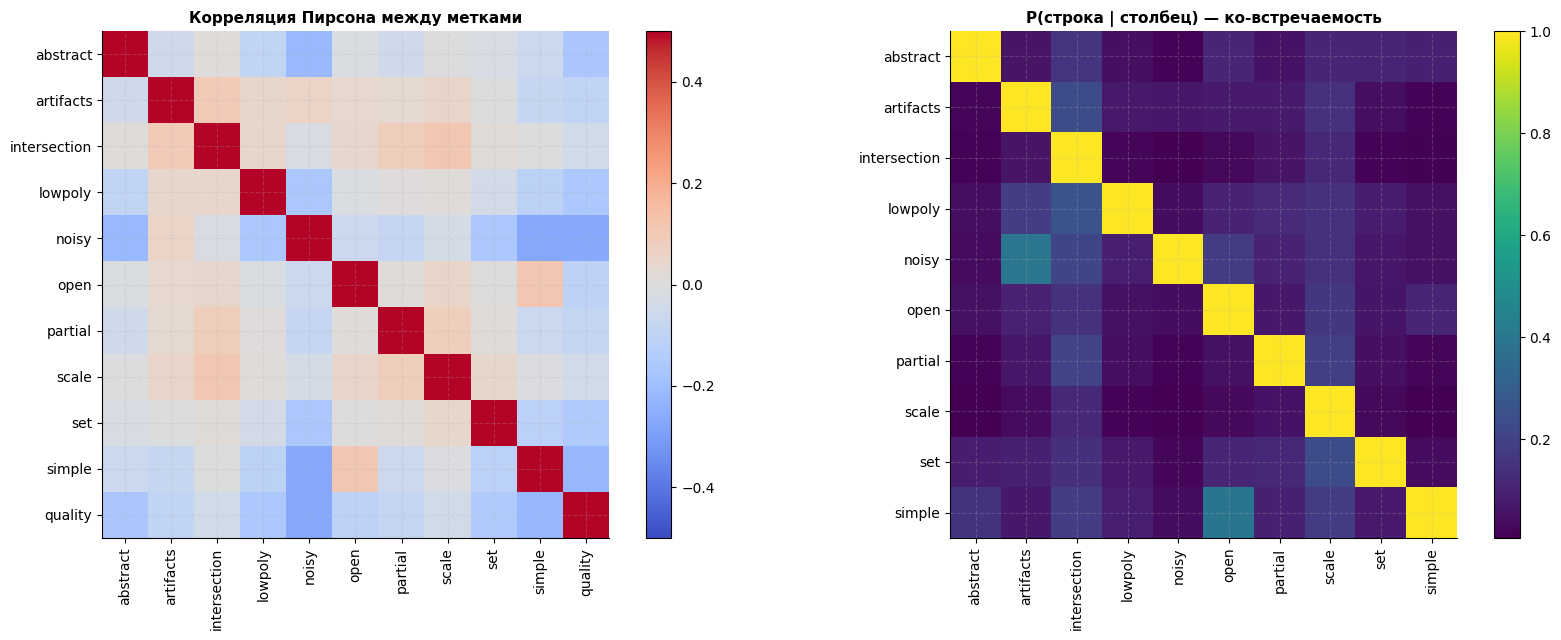

Число дефектов на объект:
0    1372
1    6372
2     878
3     251
4      59
5      25
6       7


In [6]:
# --- корреляции меток и ко-встречаемость ---
corr = train_df[CFG.target_cols].corr()
fig, ax = plt.subplots(1, 2, figsize=(17, 6.5))
im = ax[0].imshow(corr, cmap='coolwarm', vmin=-.5, vmax=.5)
ax[0].set_xticks(range(11)); ax[0].set_xticklabels(CFG.target_cols, rotation=90)
ax[0].set_yticks(range(11)); ax[0].set_yticklabels(CFG.target_cols)
ax[0].set_title('Корреляция Пирсона между метками'); plt.colorbar(im, ax=ax[0], fraction=0.046)

A = train_df[CFG.artifact_cols].values
cond = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        cond[i, j] = A[A[:, j] == 1, i].mean() if A[:, j].sum() else 0
im2 = ax[1].imshow(cond, cmap='viridis')
ax[1].set_xticks(range(10)); ax[1].set_xticklabels(CFG.artifact_cols, rotation=90)
ax[1].set_yticks(range(10)); ax[1].set_yticklabels(CFG.artifact_cols)
ax[1].set_title('P(строка | столбец) — ко-встречаемость'); plt.colorbar(im2, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

print('Число дефектов на объект:')
print(train_df[CFG.artifact_cols].sum(1).value_counts().sort_index().to_string())


  Бюджет метрики
  сколько баллов максимум можно получить на каждом классе


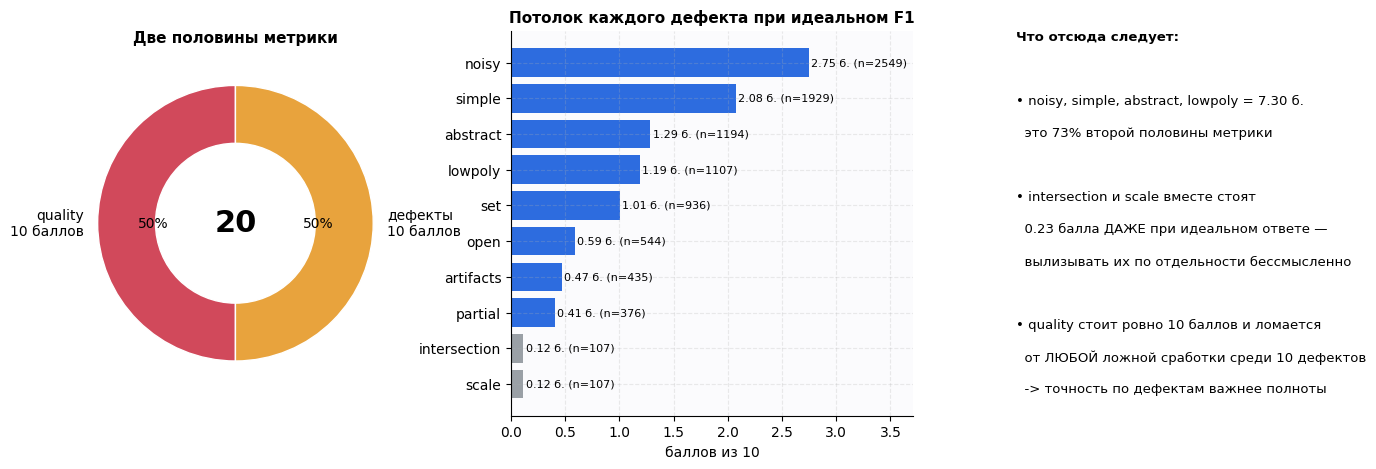

,support,вес в метрике,"потолок, баллов"
noisy,2549,0.2746,2.746
simple,1929,0.2078,2.078
abstract,1194,0.1286,1.286
lowpoly,1107,0.1192,1.192
set,936,0.1008,1.008
open,544,0.0586,0.586
artifacts,435,0.0469,0.469
partial,376,0.0405,0.405
intersection,107,0.0115,0.115
scale,107,0.0115,0.115


>>> Чтобы получить 16 из 20, нужно, грубо, F1(quality) ≈ 0.80 и weighted F1 дефектов ≈ 0.80.
>>> Прогон v5 дал ≈ 0.72 / 0.72. Разрыв закрывается не одним приёмом, а суммой: бэкбон + кросс-вью + loss под метрику + EMA + ансамбль двух конфигураций.


In [7]:
# ============ инфографика «бюджет метрики»: куда физически можно потратить усилия ============
R.section('Бюджет метрики', 'сколько баллов максимум можно получить на каждом классе')

sup = train_df[CFG.artifact_cols].sum()
w = sup / sup.sum()
budget = pd.DataFrame({'support': sup.astype(int), 'вес в метрике': w.round(4),
                       'потолок, баллов': (10 * w).round(3)}).sort_values('потолок, баллов',
                                                                         ascending=False)

fig = plt.figure(figsize=(16, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.4, 1.0], wspace=0.3)

ax = fig.add_subplot(gs[0, 0])
ax.pie([10, 10], labels=['quality\n10 баллов', 'дефекты\n10 баллов'],
       colors=[PAL['bad'], PAL['warn']], autopct='%1.0f%%',
       wedgeprops=dict(width=0.42, edgecolor='w'), startangle=90)
ax.set_title('Две половины метрики')
ax.text(0, 0, '20', ha='center', va='center', fontsize=22, weight='bold')

ax = fig.add_subplot(gs[0, 1])
b = budget.sort_values('потолок, баллов')
cols = [PAL['grey'] if v < 0.3 else PAL['main'] for v in b['потолок, баллов']]
ax.barh(b.index, b['потолок, баллов'], color=cols)
for i, (n, v) in enumerate(b['потолок, баллов'].items()):
    ax.text(v + 0.02, i, f'{v:.2f} б. (n={int(b.loc[n, "support"])})', va='center', fontsize=8)
ax.set_xlim(0, b['потолок, баллов'].max() * 1.35)
ax.set_title('Потолок каждого дефекта при идеальном F1')
ax.set_xlabel('баллов из 10')

ax = fig.add_subplot(gs[0, 2]); ax.axis('off'); ax.grid(False)
cheap = budget['потолок, баллов'].nsmallest(2)
top4 = budget['потолок, баллов'].nlargest(4)
txt = [
    'Что отсюда следует:',
    '',
    f'• {", ".join(top4.index)} = {top4.sum():.2f} б.',
    f'  это {100 * top4.sum() / 10:.0f}% второй половины метрики',
    '',
    f'• {" и ".join(cheap.index)} вместе стоят',
    f'  {cheap.sum():.2f} балла ДАЖЕ при идеальном ответе —',
    '  вылизывать их по отдельности бессмысленно',
    '',
    '• quality стоит ровно 10 баллов и ломается',
    '  от ЛЮБОЙ ложной сработки среди 10 дефектов',
    '  -> точность по дефектам важнее полноты',
]
for i, t in enumerate(txt):
    ax.text(0, 1 - 0.083 * i, t, fontsize=9.5, va='top',
            weight='bold' if t.startswith('Что') else 'normal')
plt.show()

display(budget)
print(f'>>> Чтобы получить 16 из 20, нужно, грубо, F1(quality) ≈ 0.80 и weighted F1 дефектов ≈ 0.80.')
print(f'>>> Прогон v5 дал ≈ 0.72 / 0.72. Разрыв закрывается не одним приёмом, а суммой: '
      f'бэкбон + кросс-вью + loss под метрику + EMA + ансамбль двух конфигураций.')


### 3.2. Бюджет метрики: куда вообще можно потратить усилия

Прежде чем что-то улучшать, надо знать цену каждого класса. `average='weighted'` взвешивает по support **истинных** меток, поэтому вес класса известен заранее и от предсказаний не зависит — а значит и потолок его вклада тоже.


### 3.1. Диагностика «проблемных» классов (2-й и 12-й столбцы)

В прошлой модели просели `abstract` (2-й столбец train.csv после `item_id`) и `quality`
(12-й, последний столбец). Это самая дорогая пара:

* `quality` — это ровно **10 из 20 баллов**, и он «ломается» от **любой** ложной сработки среди 10 дефектов.
  На инфографике прошлой модели `pred_rate(quality) = 0.09` при истинной доле `0.153` —
  модель ставила слишком много дефектов, и хорошие объекты вымывались.
* `abstract` — 13% данных и ~3-й по весу класс в метрике, при этом он **чисто семантический**
  (надписи, графики, поддержки для 3D-печати, Minecraft-стиль). Из облака точек он невыразим в принципе —
  отсюда провал baseline. Он лечится только рендерами.

Ниже — что именно даёт `quality` в метрике и почему прямой порог по нему обязателен.

In [8]:
from sklearn.metrics import f1_score

def competition_metric(y_true, y_pred):
    """10*F1(quality) + 10*F1_weighted(10 дефектов) — точная формула организаторов."""
    f1_q = f1_score(y_true[:, 10], y_pred[:, 10], zero_division=0)
    f1_a = f1_score(y_true[:, :10], y_pred[:, :10], average='weighted', zero_division=0)
    return 10 * f1_q + 10 * f1_a, f1_q, f1_a

# сколько стоит "OR-правило" quality = нет дефектов, если по дефектам ошибаться независимо
Y = train_df[CFG.target_cols].values
for err in [0.02, 0.05, 0.10]:
    rng = np.random.default_rng(0)
    fake = Y.copy()
    flip = rng.random(fake[:, :10].shape) < err
    fake[:, :10] = np.abs(fake[:, :10] - flip)
    fake[:, 10] = (fake[:, :10].sum(1) == 0).astype(int)
    s, fq, fa = competition_metric(Y, fake)
    print(f'FPR/FNR по дефектам {err:.0%} -> метрика {s:5.2f} (quality F1={fq:.3f}, artefacts F1={fa:.3f})')
print('\n>>> Ошибка 5% по дефектам уже срезает quality F1 до ~0.7. '
      'Поэтому quality предсказывается ОТДЕЛЬНОЙ головой, а не только правилом.')

FPR/FNR по дефектам 2% -> метрика 17.99 (quality F1=0.878, artefacts F1=0.921)
FPR/FNR по дефектам 5% -> метрика 15.21 (quality F1=0.694, artefacts F1=0.827)
FPR/FNR по дефектам 10% -> метрика 11.69 (quality F1=0.462, artefacts F1=0.706)

>>> Ошибка 5% по дефектам уже срезает quality F1 до ~0.7. Поэтому quality предсказывается ОТДЕЛЬНОЙ головой, а не только правилом.


## 4. Рендеры: разрезаем мозаику на 6 видов и кэшируем

В `{item_id}.png` лежат 6 видов одним листом (4 азимута с шагом 90° + top + bottom).
Раскладку определяем по соотношению сторон (поддержаны 3×2, 2×3, 6×1, 1×6), поэтому
ноутбук не сломается, если у части файлов сетка транспонирована.

Кэш: каждая картинка ужимается так, чтобы один вид был `CFG.tile` пикселей, и складывается
обратно в мозаику — один PNG на объект (~150 КБ), декодирование в DataLoader-е дешёвое.

In [9]:
from PIL import Image
from concurrent.futures import ProcessPoolExecutor

Image.MAX_IMAGE_PIXELS = None

def infer_grid(w, h):
    """(rows, cols) для 6 видов по соотношению сторон."""
    ar = w / h
    cands = {(2, 3): 3 / 2, (3, 2): 2 / 3, (1, 6): 6.0, (6, 1): 1 / 6}
    return min(cands, key=lambda k: abs(math.log(ar / cands[k])))

def split_views(img):
    """PIL.Image -> список из 6 PIL.Image в каноническом порядке чтения."""
    w, h = img.size
    r, c = infer_grid(w, h)
    tw, th = w // c, h // r
    return [img.crop((j * tw, i * th, (j + 1) * tw, (i + 1) * th)) for i in range(r) for j in range(c)]

def make_cache(args):
    src, dst, tile = args
    try:
        img = Image.open(src).convert('RGB')
        views = [v.resize((tile, tile), Image.BILINEAR) for v in split_views(img)]
        out = Image.new('RGB', (3 * tile, 2 * tile))
        for k, v in enumerate(views):
            out.paste(v, ((k % 3) * tile, (k // 3) * tile))
        out.save(dst, format='PNG', optimize=False, compress_level=1)
        return 1
    except Exception:
        return 0

def build_image_cache(ids, src_dir, split):
    out_dir = CFG.cache / f'img_{split}_{CFG.tile}'
    out_dir.mkdir(parents=True, exist_ok=True)
    jobs = [(str(Path(src_dir) / f'{i}.png'), str(out_dir / f'{i}.png'), CFG.tile)
            for i in ids if not (out_dir / f'{i}.png').exists()
            and (Path(src_dir) / f'{i}.png').exists()]
    if jobs:
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
            ok = list(tqdm(ex.map(make_cache, jobs, chunksize=32), total=len(jobs),
                           desc=f'cache {split}'))
        print(f'{split}: закэшировано {sum(ok)}/{len(jobs)}')
    missing = [i for i in ids if not (out_dir / f'{i}.png').exists()]
    print(f'{split}: всего в кэше {len(ids) - len(missing)}/{len(ids)}, нет картинки у {len(missing)}')
    return out_dir, set(missing)

# --- сколько пикселей на вид даёт исходный рендер: апскейл выше этого бессмысленно ---
NATIVE_TILE = None
_probe = [Image.open(Path(TRAIN_DIR) / f'{i}.png').size
          for i in train_df['item_id'].head(40) if (Path(TRAIN_DIR) / f'{i}.png').exists()]
if _probe:
    _sizes = pd.Series([f'{w}x{h}' for w, h in _probe]).value_counts()
    print('исходные размеры листа с 6 видами:'); print(_sizes.head(5).to_string())
    _w, _h = _probe[0]
    _r, _c = infer_grid(_w, _h)
    NATIVE_TILE = int(min(_w // _c, _h // _r))
    R.kv(**{'раскладка': f'{_r}x{_c}', 'нативный размер вида': f'~{NATIVE_TILE} px'})
    for _c_ in CONFIGS:
        if _c_['tile'] > NATIVE_TILE:
            R.warn(f"{_c_['run_tag']}: tile {_c_['tile']} больше нативного {NATIVE_TILE} — "
                   f'это апскейл, снижаю до {NATIVE_TILE}')
            _c_['tile'] = NATIVE_TILE

# Кэш рендеров строится ПОД КАЖДОЕ разрешение отдельно, внутри run_configuration (§9A/§9B),
# потому что у двух конфигураций разный tile. Здесь только определения.
IMG_TRAIN = IMG_TEST = None
MISS_TRAIN = MISS_TEST = set()

исходные размеры листа с 6 видами:
1536x1024    40
    раскладка                      2x3
    нативный размер вида           ~512 px


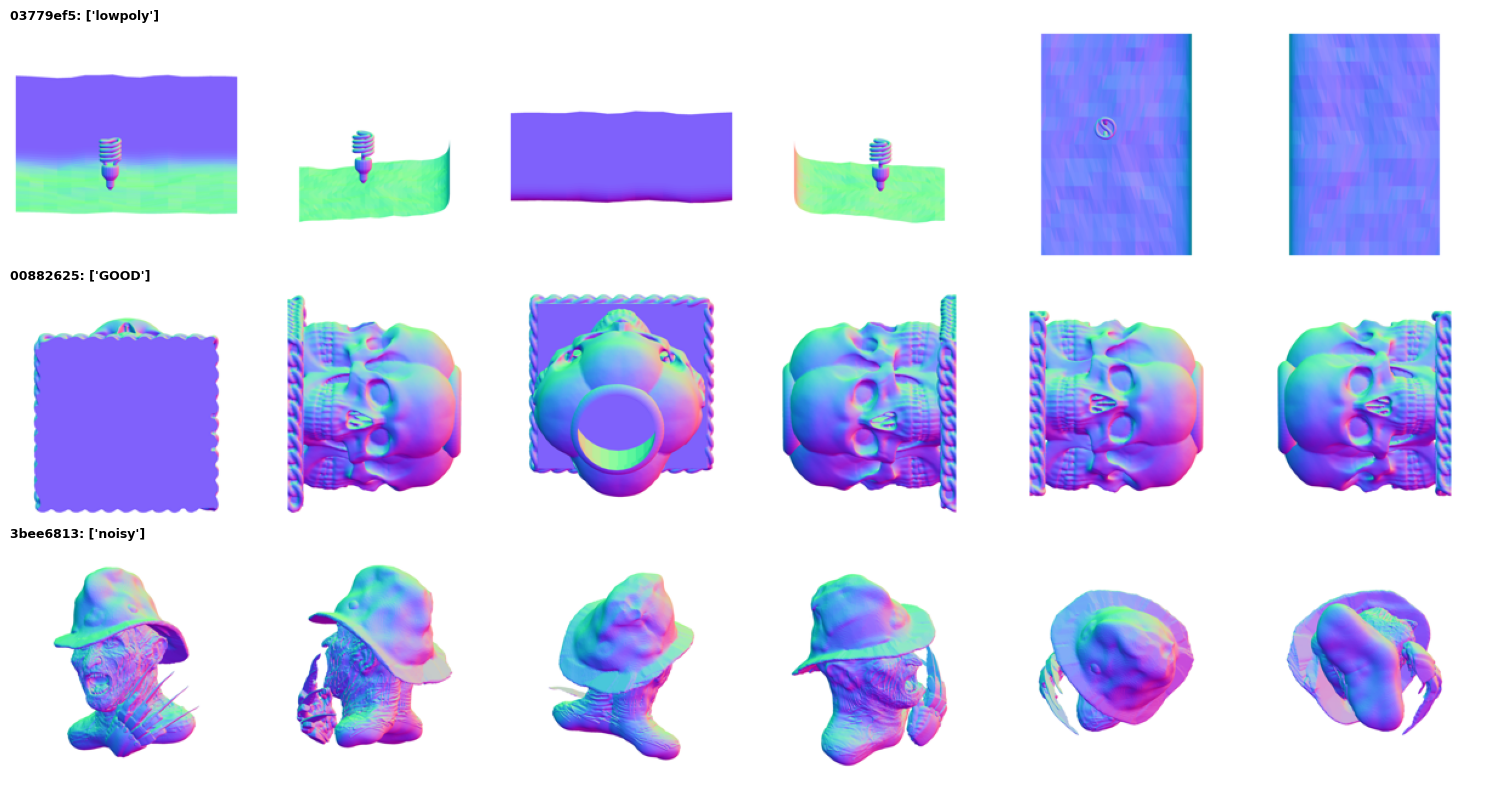

In [10]:
# --- визуальная проверка раскладки: 3 случайных объекта, 6 видов ---
seed_everything()
sample_ids = train_df.sample(3, random_state=0)['item_id'].tolist()
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for r_, iid in enumerate(sample_ids):
    views = split_views(Image.open(Path(TRAIN_DIR) / f'{iid}.png').convert('RGB'))
    lbl = [c for c in CFG.artifact_cols if train_df.loc[train_df.item_id == iid, c].iloc[0] == 1]
    for k, v in enumerate(views):
        axes[r_, k].imshow(v.resize((192, 192))); axes[r_, k].axis('off')
        if k == 0:
            axes[r_, k].set_title(f'{iid[:8]}: {lbl or ["GOOD"]}', loc='left', fontsize=9)
plt.tight_layout(); plt.show()


## 5. Геометрические фичи из `.npz` — **со сваркой вершин**

### Что было сломано в прошлом прогоне

В диагностике «топ-фича на класс» не оказалось **ни одной** топологической фичи:
`open` объяснялся картиночной `pxstd_min`, `set` — `bbox_fill_view`, `lowpoly` — `uniq_normals`.
Это подпись **несваренных вершин**: экспортёры (glTF/OBJ с раздельными нормалями и UV)
дублируют вершину на каждую грань, поэтому в сыром массиве индексов
**ни одно ребро не принадлежит двум граням**. Следствие:

* двугранных углов не существует вовсе (`dihed_*` тождественно 0);
* `boundary_edge_ratio = 1.0` у **любого** меша, включая замкнутый;
* `n_comp` = числу треугольников, `watertight = 0` всегда.

То есть вся топологическая ветка была мертва, а `open`/`artifacts` (F1 ≈ 0.30) вытягивались
случайными прокси. Ниже — сварка вершин по квантованной сетке `1e-6` диагонали bbox
(упаковка трёх координат в один int64, без коллизий), удаление вырожденных и дублирующихся
граней, и только потом топология.

### Новые фичи и их мишени

| фича | класс | обоснование |
|---|---|---|
| `boundary_edge_ratio`, `n_boundary_loops`, `watertight`, `boundary_vert_frac` | `open` | «полые внутри либо состоят из плоских поверхностей» = незамкнутая поверхность с граничными петлями |
| `nonmanifold_edge_ratio`, `dup_face_ratio`, `degen_after_weld`, `vol_ratio` | `artifacts` | non-manifold рёбра, дубли граней и несогласованная намотка = «объект выглядит сломанным» |
| `solidity` (V/V выпуклой оболочки), `sphericity`, `normal_top6_mass` | `simple` | у примитивов вся площадь лежит в нескольких кластерах нормалей, solidity → 1 |
| `dihedf_*` (folded углы), `dihed_entropy`, `smoothness`, `valence_*` | `lowpoly` / `noisy` | фасетчатость регулярна (низкая энтропия), скан шумит хаотично (высокая) |
| угловой дефект `defect_*` (гауссова кривизна) | `noisy`, `lowpoly` | точечная кривизна: у гладкой поверхности ≈ 0, у шума разброс |
| `n_comp`, `comp_top1`, `comp_entropy` | `set` | «объект разделён в пространстве» — теперь считается по сваренному мешу |
| `bbox_iou_max`, `inside_frac_max` | `intersection` | доля вершин одной компоненты внутри bbox другой |

Проверка на синтетике (несваренный куб/сфера дают ровно те же значения, что сваренные):
гладкая сфера `dihedf=3.0°`, lowpoly-40 `22.9°`, шумный скан `13.6°`;
`normal_top6_mass`: куб `1.00`, сфера `0.02`; `solidity`: куб `1.00`, плоскость `0.00`;
сфера с вырезанной шапкой — `watertight=0`, `n_boundary_loops=1`.

In [11]:
import os, gc, math, numpy as np, pandas as pd
from pathlib import Path
from PIL import Image
from scipy import ndimage
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import ConvexHull, QhullError
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures.process import BrokenProcessPool
import multiprocessing as mp

FACE_CAP  = 300_000
VERT_CAP  = 200_000
HULL_CAP  = 20_000
COMP_CAP  = 3_000_000
WELD_TOL  = 1e-6         # доля диагонали bbox
FEAT_VER  = 'v6fast'
SPECTRAL_ON = CFG.use_spectral  # версия набора фич: входит в имя кэша. Поднята с v3weld, т.к.
                         # добавлены §4.5.1-4.5.3 (самопересечения/качество треугольников/
                         # non-manifold вершины) и v6 (§5.4, спектр лапласиана) —
                         # старый parquet без них не подхватится молча
# Было min(4, ...) — на машине с 8-12 ядрами это резало пропускную способность
# в два-три раза на самом дорогом шаге всего ноутбука.
N_WORKERS = max(1, (os.cpu_count() or 4) - 1)
CHUNK     = 512          # чаще чекпоинт: при обрыве теряется меньше посчитанного

def _pack21(q):
    """Три целых из [0, 2**21) -> один int64. Точно, без коллизий."""
    return (q[:, 0] << 42) | (q[:, 1] << 21) | q[:, 2]

def _hash3(q):
    q = q.astype(np.int64, copy=False)
    return (q[:, 0] * 73856093) ^ (q[:, 1] * 19349663) ^ (q[:, 2] * 83492791)

def _stats(x, pref):
    keys = ['mean', 'std', 'p10', 'p50', 'p90', 'max', 'cv']
    if len(x) == 0:
        return {f'{pref}_{k}': 0.0 for k in keys}
    x = np.asarray(x, dtype=np.float32)
    m, s = float(x.mean()), float(x.std())
    q10, q50, q90 = np.percentile(x, [10, 50, 90])
    return {f'{pref}_mean': m, f'{pref}_std': s, f'{pref}_p10': float(q10),
            f'{pref}_p50': float(q50), f'{pref}_p90': float(q90),
            f'{pref}_max': float(x.max()), f'{pref}_cv': float(s / (abs(m) + 1e-9))}

def _edge_table(Fi, nfw):
    """Рёбра -> (номер группы, число граней на ребро, отсортированные id граней)."""
    E = np.concatenate([Fi[:, [0, 1]], Fi[:, [1, 2]], Fi[:, [2, 0]]], 0)
    E.sort(axis=1)
    fid = np.tile(np.arange(nfw, dtype=np.int32), 3)
    order = np.lexsort((E[:, 1], E[:, 0]))
    Es, fids = E[order], fid[order]
    new = np.ones(len(Es), dtype=bool)
    new[1:] = (Es[1:] != Es[:-1]).any(1)
    grp = np.cumsum(new) - 1
    counts = np.bincount(grp)
    return E, Es, fids, grp, counts, new

SPEC_K    = 24           # сколько собственных чисел берём
SPEC_VCAP = 8_000        # было 60k. Замер показал, почему это было ошибкой: у сеточных
                         # лапласианов малые собственные числа КЛАСТЕРИЗОВАНЫ возле нуля,
                         # а на кластерах Ланцош сходится плохо и вырабатывает maxiter
                         # почти на каждом меше. Отсюда ~10 c/меш и 27 часов на train.


def _laplace_spectrum(Fi, nvp, k=SPEC_K):
    """Спектр нормированного лапласиана меша — инвариант формы (§14.E).

    Зачем. `simple` (примитивы), `lowpoly` (регулярная фасетчатая сетка) и `noisy`
    (хаотичный скан) различаются не локально, а структурой сетки в целом. Спектр
    Лапласа-Бельтрами — классический глобальный дескриптор («Shape-DNA», Reuter et al.
    2006): он инвариантен к повороту, сдвигу и перенумерации вершин, а у нормированной
    версии ещё и к масштабу, поскольку все собственные числа лежат в [0, 2].

    Как считаем дёшево. Нужны САМЫЕ МАЛЕНЬКИЕ собственные числа, а Ланцош хорошо
    сходится только к крайним. Поэтому ищем самые БОЛЬШИЕ у матрицы `2I - L_norm`:
    её спектр — это зеркально отражённый спектр `L_norm`, и `which='LA'` сходится
    за несколько десятков матвеков. Никакой факторизации и shift-invert не нужно,
    поэтому фича стоит миллисекунды на меш и не ломает бюджет прогона.
    """
    out = {'spec_ok': 0.0, 'spec_gap': 0.0, 'spec_sum': 0.0, 'spec_slope': 0.0,
           'spec_n_zero': 0.0, 'spec_entropy': 0.0}
    for j in range(k):
        out[f'spec_{j:02d}'] = 0.0
    if nvp < 32 or nvp > SPEC_VCAP or len(Fi) == 0:
        return out
    try:
        from scipy.sparse import coo_matrix, diags, identity
        from scipy.sparse.linalg import eigsh, LinearOperator
        E = np.concatenate([Fi[:, [0, 1]], Fi[:, [1, 2]], Fi[:, [2, 0]]], 0)
        w = np.ones(len(E), dtype=np.float32)
        A = coo_matrix((w, (E[:, 0], E[:, 1])), shape=(nvp, nvp)).tocsr()
        A = ((A + A.T) > 0).astype(np.float32)              # симметричная 0/1 смежность
        deg = np.asarray(A.sum(1)).ravel()
        keep = deg > 0
        if keep.sum() < 32:
            return out
        A = A[keep][:, keep]
        deg = np.asarray(A.sum(1)).ravel()
        dm = diags(1.0 / np.sqrt(deg + 1e-12))
        Ln = identity(A.shape[0], format='csr') - dm @ A @ dm        # спектр в [0, 2]
        M = 2.0 * identity(A.shape[0], format='csr') - Ln            # крайние -> самые большие
        kk = int(min(k + 1, A.shape[0] - 2))
        if kk < 3:
            return out
        ev = eigsh(M, k=kk, which='LA', return_eigenvectors=False, maxiter=300, tol=1e-2)
        lam = np.sort(np.clip(2.0 - ev, 0, 2))                       # обратно в спектр L_norm
        out['spec_ok'] = 1.0
        out['spec_n_zero'] = float((lam < 1e-6).sum())               # ~ число компонент
        nz = lam[lam >= 1e-6]
        if len(nz):
            out['spec_gap'] = float(nz[0])                           # щель Фидлера -> связность/`set`
            out['spec_sum'] = float(lam[:k].sum())
            p = nz / (nz.sum() + 1e-12)
            out['spec_entropy'] = float(-(p * np.log(p + 1e-12)).sum())
            if len(nz) >= 4:
                x = np.log1p(np.arange(len(nz)))
                out['spec_slope'] = float(np.polyfit(x, np.log(nz + 1e-9), 1)[0])
        for j in range(min(k, len(lam))):
            out[f'spec_{j:02d}'] = float(lam[j])
    except Exception:
        pass
    return out


def mesh_features(npz_path):
    f = {'geo_ok': 0.0, 'geo_subsampled': 0.0}
    try:
        f['npz_mb'] = os.path.getsize(npz_path) / 1e6
    except Exception:
        return f
    try:
        with np.load(npz_path, allow_pickle=False) as d:
            keys = list(d.keys())
            V = np.asarray(d['vertices' if 'vertices' in keys else keys[0]], dtype=np.float32)
            Fc = None
            for k in ('faces', 'triangles', 'f'):
                if k in keys:
                    Fc = np.asarray(d[k], dtype=np.int64); break
            if Fc is None and len(keys) > 1:
                Fc = np.asarray(d[keys[1]], dtype=np.int64)
    except Exception:
        return f
    if V.ndim != 2 or V.shape[1] != 3 or len(V) == 0:
        return f
    if Fc is None or Fc.ndim != 2 or Fc.shape[1] != 3 or len(Fc) == 0:
        Fc = np.zeros((0, 3), dtype=np.int64)
    else:
        Fc = Fc[(Fc >= 0).all(1) & (Fc < len(V)).all(1)]

    f['geo_ok'] = 1.0
    nv_raw, nf_raw = len(V), len(Fc)
    vmin, vmax = V.min(0), V.max(0)
    ext = (vmax - vmin).astype(np.float64)
    ext_s = np.sort(ext)[::-1]
    diag = float(np.linalg.norm(ext)) + 1e-12
    center = ((vmin + vmax) / 2).astype(np.float32)
    inv_s = np.float32(1.0 / diag)
    f.update({'n_verts_raw': float(nv_raw), 'n_faces': float(nf_raw),
              'log_verts': math.log1p(nv_raw), 'log_faces': math.log1p(nf_raw),
              'ext_max': float(ext_s[0]), 'ext_mid': float(ext_s[1]), 'ext_min': float(ext_s[2]),
              'ext_ratio_min': float(ext_s[2] / (ext_s[0] + 1e-12)),
              'ext_ratio_mid': float(ext_s[1] / (ext_s[0] + 1e-12)),
              'bbox_diag': diag,
              'bbox_fill': float(nv_raw / (ext.prod() + 1e-12)) if ext.prod() > 0 else 0.0})

    # ================== СВАРКА ВЕРШИН ==================
    # Экспортёры (glTF/OBJ с раздельными нормалями и UV) дублируют вершины на каждую грань.
    # Без сварки НИ ОДНО ребро не имеет двух граней: двугранные углы пусты, boundary=1.0,
    # компонент столько же, сколько треугольников. Вся топология обязана считаться после сварки.
    step = np.float32(diag * WELD_TOL)
    q = np.clip(np.rint((V - vmin) / step), 0, (1 << 21) - 1).astype(np.int64)
    code = _pack21(q)
    del q
    ucode, first, invmap = np.unique(code, return_index=True, return_inverse=True)
    del code, ucode
    nv = len(first)
    f['n_verts'] = float(nv)
    f['weld_ratio'] = float(1.0 - nv / max(nv_raw, 1))          # 0 = уже сварен, ~0.83 = по 3 вершины на грань
    f['f_per_v'] = nf_raw / max(nv, 1)
    Vw_full = V[first]
    del first

    if nf_raw:
        Fw = invmap[Fc]
        ok = (Fw[:, 0] != Fw[:, 1]) & (Fw[:, 1] != Fw[:, 2]) & (Fw[:, 0] != Fw[:, 2])
        f['degen_after_weld'] = float(1.0 - ok.mean())
        Fw = Fw[ok]
        hf = _hash3(np.sort(Fw, axis=1))
        _, uidx = np.unique(hf, return_index=True)
        f['dup_face_ratio'] = float(1.0 - len(uidx) / max(len(Fw), 1))
        Fw = Fw[np.sort(uidx)]
        del hf, uidx, ok
    else:
        Fw = np.zeros((0, 3), dtype=np.int64)
        f['degen_after_weld'] = 0.0; f['dup_face_ratio'] = 0.0
    del invmap, Fc
    nf = len(Fw)

    # ---- вершинные статистики (подвыборка) ----
    Vs = Vw_full[::max(1, int(np.ceil(nv / VERT_CAP)))]
    if nv > VERT_CAP:
        f['geo_subsampled'] = 1.0
    Vs = (Vs - center) * inv_s
    try:
        if len(Vs) < 3:
            raise ValueError('too few vertices')
        ev = np.clip(np.linalg.eigvalsh(np.cov(Vs.T.astype(np.float64)))[::-1], 1e-16, None)
        f.update({'pca_1': float(ev[0]), 'pca_2': float(ev[1]), 'pca_3': float(ev[2]),
                  'pca_flat': float(ev[2] / ev[0]), 'pca_lin': float(ev[1] / ev[0]),
                  'pca_aniso': float((ev[0] - ev[2]) / ev.sum())})
    except Exception:
        f.update({k: 0.0 for k in ['pca_1', 'pca_2', 'pca_3', 'pca_flat', 'pca_lin', 'pca_aniso']})

    # ---- выпуклая оболочка: solidity/сферичность -> simple, open ----
    f.update({'hull_ok': 0.0, 'solidity': 0.0, 'solidity_signed': 0.0, 'hull_area_ratio': 0.0,
              'hull_pts_frac': 0.0, 'sphericity': 0.0, 'hull_vol': 0.0, 'hull_area': 0.0})
    try:
        Vh = Vs[::max(1, int(np.ceil(len(Vs) / HULL_CAP)))].astype(np.float64)
        if len(Vh) >= 8:
            hull = ConvexHull(Vh, qhull_options='QJ')
            f['hull_ok'] = 1.0
            f['hull_vol'] = float(hull.volume)
            f['hull_pts_frac'] = len(hull.vertices) / len(Vh)
            f['hull_area'] = float(hull.area)
    except (QhullError, ValueError, MemoryError):
        pass

    if nf == 0:
        f['no_faces'] = 1.0
        f.update({'area_total': 0.0, 'volume': 0.0, 'abs_volume': 0.0, 'vol_ratio': 0.0,
                  'vol_over_area': 0.0, 'absvol_over_area': 0.0, 'vol_over_bbox': 0.0,
                  'absvol_over_bbox': 0.0})
        for pref in ('dihed', 'dihedf', 'farea', 'elen', 'aspect', 'valence', 'defect'):
            f.update(_stats([], pref))
        return f
    f['no_faces'] = 0.0

    # ---- точные площадь/объём по полному сваренному мешу ----
    total_area, vol6, absvol6 = 0.0, 0.0, 0.0
    for s0 in range(0, nf, 500_000):
        Pc = ((Vw_full[Fw[s0:s0 + 500_000]] - center) * inv_s).astype(np.float64)
        cr_c = np.cross(Pc[:, 1] - Pc[:, 0], Pc[:, 2] - Pc[:, 0])
        total_area += 0.5 * float(np.linalg.norm(cr_c, axis=1).sum())
        contrib = (Pc[:, 0] * np.cross(Pc[:, 1], Pc[:, 2])).sum(1)
        vol6 += float(contrib.sum()); absvol6 += float(np.abs(contrib).sum())
        del Pc, cr_c, contrib
    total_area += 1e-12
    vol = abs(vol6 / 6.0)
    absvol = absvol6 / 6.0
    # vol_ratio ~1 у корректно ориентированного меша и ~0 при несогласованной намотке граней
    # (сама по себе сильная улика для artifacts/noisy). Объём для solidity берём устойчивый.
    f.update({'area_total': total_area, 'volume': vol, 'abs_volume': absvol,
              'vol_ratio': vol / (absvol + 1e-12),
              'vol_over_area': vol / (total_area ** 1.5 + 1e-12),
              'absvol_over_area': absvol / (total_area ** 1.5 + 1e-12),
              'vol_over_bbox': vol / (float(np.prod(ext * inv_s)) + 1e-12),
              'absvol_over_bbox': absvol / (float(np.prod(ext * inv_s)) + 1e-12)})
    if f['hull_ok']:
        f['solidity'] = absvol / (f['hull_vol'] + 1e-12)
        f['solidity_signed'] = vol / (f['hull_vol'] + 1e-12)
        f['hull_area_ratio'] = total_area / (f.get('hull_area', 0.0) + 1e-12)
        f['sphericity'] = (math.pi ** (1 / 3)) * (6 * absvol) ** (2 / 3) / (total_area + 1e-12)

    # ---- компоненты связности на полном СВАРЕННОМ меше ----
    f.update({'n_comp': 1.0, 'n_comp_big': 1.0, 'comp_top1': 1.0, 'comp_top2': 0.0,
              'comp_entropy': 0.0, 'bbox_iou_max': 0.0, 'bbox_iou_mean': 0.0,
              'bbox_iou_frac_pos': 0.0, 'comp_sep_max': 0.0, 'comp_sep_mean': 0.0,
              'inside_frac_max': 0.0, 'comp_exact': 1.0})
    if nf <= COMP_CAP:
        try:
            Ef = np.concatenate([Fw[:, [0, 1]], Fw[:, [1, 2]], Fw[:, [2, 0]]], 0).astype(np.int32)
            A = coo_matrix((np.ones(len(Ef), dtype=np.int8), (Ef[:, 0], Ef[:, 1])), shape=(nv, nv))
            del Ef
            ncomp, lab = connected_components(A, directed=False)
            del A
            used = np.unique(Fw)
            sizes_all = np.bincount(lab[used], minlength=ncomp).astype(np.float64)
            sizes = np.sort(sizes_all[sizes_all > 0])[::-1]
            tot = sizes.sum()
            big_idx = np.where(sizes_all > 0.005 * tot)[0]
            f.update({'n_comp': float(len(sizes)), 'n_comp_big': float(len(big_idx)),
                      'comp_top1': float(sizes[0] / tot),
                      'comp_top2': float(sizes[1] / tot) if len(sizes) > 1 else 0.0,
                      'comp_entropy': float(-((sizes / tot) * np.log(sizes / tot + 1e-12)).sum())})
            if len(big_idx) > 1:
                top = big_idx[np.argsort(-sizes_all[big_idx])][:8]
                pts_l, boxes = [], []
                for c in top:
                    ic = used[lab[used] == c]
                    if len(ic) > 20_000:
                        ic = ic[::len(ic) // 20_000 + 1]
                    p = (Vw_full[ic] - center) * inv_s
                    pts_l.append(p); boxes.append((p.min(0), p.max(0)))
                ious, seps, insides = [], [], []
                for i in range(len(boxes)):
                    for j in range(len(boxes)):
                        if i == j:
                            continue
                        lo, hi = boxes[j]
                        insides.append(float(((pts_l[i] >= lo) & (pts_l[i] <= hi)).all(1).mean()))
                        if j <= i:
                            continue
                        lo2 = np.maximum(boxes[i][0], boxes[j][0])
                        hi2 = np.minimum(boxes[i][1], boxes[j][1])
                        it = float(np.prod(np.clip(hi2 - lo2, 0, None)))
                        vi = float(np.prod(np.clip(boxes[i][1] - boxes[i][0], 1e-6, None)))
                        vj = float(np.prod(np.clip(boxes[j][1] - boxes[j][0], 1e-6, None)))
                        ious.append(it / (vi + vj - it + 1e-12))
                        seps.append(float(np.linalg.norm(
                            (boxes[i][0] + boxes[i][1]) / 2 - (boxes[j][0] + boxes[j][1]) / 2)))
                f.update({'bbox_iou_max': float(max(ious)), 'bbox_iou_mean': float(np.mean(ious)),
                          'bbox_iou_frac_pos': float(np.mean(np.asarray(ious) > 1e-6)),
                          'comp_sep_max': float(max(seps)), 'comp_sep_mean': float(np.mean(seps)),
                          'inside_frac_max': float(max(insides))})
            del lab, sizes_all, sizes, used
        except Exception:
            f['comp_exact'] = 0.0
    else:
        f['comp_exact'] = 0.0

    # ---- пространственный патч для рёберной топологии ----
    if nf > FACE_CAP:
        f['geo_subsampled'] = 1.0
        anchor = (Vw_full[Fw[:, 0]] - vmin) / (ext.astype(np.float32) + 1e-9)
        Fp, g = None, 1
        while g < 40:
            g += 1
            cid = np.minimum((anchor * g).astype(np.int32), g - 1)
            key = (cid[:, 0] * g + cid[:, 1]) * g + cid[:, 2]
            cnt = np.bincount(key, minlength=g ** 3)
            best = int(np.argmax(cnt))
            if cnt[best] <= FACE_CAP:
                Fp = Fw[key == best]; break
        if Fp is None or len(Fp) < 1000:
            Fp = Fw[:FACE_CAP]
        f['patch_grid'] = float(g)
        del anchor
    else:
        Fp = Fw
        f['patch_grid'] = 1.0
    f['patch_face_frac'] = len(Fp) / max(nf, 1)
    del Fw
    nfw = len(Fp)

    uvp, Fi = np.unique(Fp, return_inverse=True)
    Fi = Fi.reshape(nfw, 3).astype(np.int32)
    Vp = ((Vw_full[uvp] - center) * inv_s).astype(np.float32)
    nvp = len(uvp)
    del uvp, Fp, Vw_full, V

    P = Vp[Fi]
    cr = np.cross(P[:, 1] - P[:, 0], P[:, 2] - P[:, 0])
    area2 = np.linalg.norm(cr, axis=1)
    area = 0.5 * area2
    nrm = cr / (area2[:, None] + 1e-12)
    del cr
    f.update(_stats(area / (area.mean() + 1e-12), 'farea'))
    f['degenerate_ratio'] = float((area < 1e-10).mean())

    L = np.stack([np.linalg.norm(P[:, 1] - P[:, 0], axis=1),
                  np.linalg.norm(P[:, 2] - P[:, 1], axis=1),
                  np.linalg.norm(P[:, 0] - P[:, 2], axis=1)], 1)
    f.update(_stats(L.ravel() / (L.mean() + 1e-12), 'elen'))
    aspect = L.max(1) / (L.min(1) + 1e-12)
    f.update(_stats(np.log1p(aspect), 'aspect'))
    f['sliver_ratio'] = float((aspect > 20).mean())

    # ---- §4.5.2 качество треугольников: худший угол + нормализованная форма ----
    # min-угол — классический индикатор "плохого" элемента (aspect ratio его не всегда
    # ловит: длинный тупоугольный треугольник может иметь умеренный aspect, но острый
    # min-угол). tri_quality = 4*sqrt(3)*area/(l0^2+l1^2+l2^2) -> 1.0 для равностороннего,
    # ->0 для вырожденного; оба считаются векторно из уже посчитанных L и area, без
    # дополнительного прохода по мешу.
    L0, L1, L2 = L[:, 0], L[:, 1], L[:, 2]
    with np.errstate(divide='ignore', invalid='ignore'):
        cA = np.clip((L1 ** 2 + L2 ** 2 - L0 ** 2) / (2 * L1 * L2 + 1e-12), -1, 1)
        cB = np.clip((L0 ** 2 + L2 ** 2 - L1 ** 2) / (2 * L0 * L2 + 1e-12), -1, 1)
        cC = np.clip((L0 ** 2 + L1 ** 2 - L2 ** 2) / (2 * L0 * L1 + 1e-12), -1, 1)
    tri_ang = np.degrees(np.arccos(np.stack([cA, cB, cC], 1)))
    min_ang, max_ang = tri_ang.min(1), tri_ang.max(1)
    f.update(_stats(min_ang, 'minang')); f.update(_stats(max_ang, 'maxang'))
    f['sliver_angle_ratio'] = float((min_ang < 5).mean())
    tri_quality = np.clip((4 * math.sqrt(3) * area) / (L0 ** 2 + L1 ** 2 + L2 ** 2 + 1e-12), 0, 1)
    f.update(_stats(tri_quality, 'triq'))
    del L0, L1, L2, cA, cB, cC, tri_ang, min_ang, max_ang, tri_quality

    for qd in (1, 2):
        f[f'uniq_normals_q{qd}'] = len(np.unique(_hash3(np.rint(nrm * 10 ** qd)))) / nfw
    # концентрация нормалей: доля площади в 6 крупнейших кластерах -> примитивы
    hn = _hash3(np.rint(nrm * 20))
    _, ninv = np.unique(hn, return_inverse=True)
    mass = np.bincount(ninv, weights=area)
    mass = np.sort(mass)[::-1]
    f['normal_top6_mass'] = float(mass[:6].sum() / (mass.sum() + 1e-12))
    f['normal_top1_mass'] = float(mass[0] / (mass.sum() + 1e-12))
    del hn, ninv, mass

    # ---- §4.5.1 самопересечения: близкие по центроиду грани без общей вершины ----
    # intersection сейчас ловится только CNN с рендеров; хуже того, его confusion
    # портит quality (10 из 16 баллов), даже когда сам класс почти ничего не весит
    # (см. §14, "потолок по классам": intersection+scale = 0.18 балла при идеальном
    # предсказании) — поэтому цель этих фич не "поднять F1(intersection)" сама по себе,
    # а снизить количество ложных срабатываний, которые размывают quality.
    # cKDTree.query_pairs даёт кандидатов почти даром; точный тест — 6 рёберно-плоскостных
    # проверок на кандидата (Möller-style), полностью векторизован по всем парам разом.
    f.update({'selfint_ok': 0.0, 'selfint_pair_ratio': 0.0, 'selfint_face_ratio': 0.0,
              'selfint_any': 0.0, 'selfint_capped': 0.0})
    # 40k вместо 120k: самопересечения нужны для intersection, который стоит
    # 0.115 балла ДАЖЕ при идеальном предсказании — точность там не окупает времени.
    SELFINT_FACE_CAP = 40_000
    SELFINT_PAIR_CAP = 400_000
    if 0 < nfw <= SELFINT_FACE_CAP:
        try:
            from scipy.spatial import cKDTree
            cen = Vp[Fi].mean(1)
            elen_med = float(np.median(L)) if len(L) else 1e-6
            r = max(elen_med * 2.5, 1e-6)
            pairs = cKDTree(cen).query_pairs(r=r, output_type='ndarray')
            if len(pairs):
                share = (Fi[pairs[:, 0], :, None] == Fi[pairs[:, 1], None, :]).any((1, 2))
                pairs = pairs[~share]
            if len(pairs) > SELFINT_PAIR_CAP:
                sel = np.random.default_rng(0).choice(len(pairs), SELFINT_PAIR_CAP, replace=False)
                pairs = pairs[sel]
                f['selfint_capped'] = 1.0
            f['selfint_ok'] = 1.0
            if len(pairs):
                ii, jj = pairs[:, 0], pairs[:, 1]
                PA, PB = Vp[Fi[ii]], Vp[Fi[jj]]
                nA, nB = nrm[ii], nrm[jj]

                def _edge_hits(a, b, p0, p1, p2, n):
                    d = np.einsum('ij,ij->i', n, p0)
                    ta = np.einsum('ij,ij->i', n, a) - d
                    tb = np.einsum('ij,ij->i', n, b) - d
                    denom = ta - tb
                    safe = np.abs(denom) > 1e-12
                    t = np.clip(np.divide(ta, denom, out=np.zeros_like(ta), where=safe), 0.0, 1.0)
                    pt = a + t[:, None] * (b - a)
                    e0 = np.cross(p1 - p0, pt - p0); e1 = np.cross(p2 - p1, pt - p1)
                    e2 = np.cross(p0 - p2, pt - p2)
                    s0 = np.einsum('ij,ij->i', e0, n); s1 = np.einsum('ij,ij->i', e1, n)
                    s2 = np.einsum('ij,ij->i', e2, n)
                    inside = (((s0 >= -1e-9) & (s1 >= -1e-9) & (s2 >= -1e-9)) |
                              ((s0 <= 1e-9) & (s1 <= 1e-9) & (s2 <= 1e-9)))
                    return (ta * tb <= 0) & safe & inside

                hit = np.zeros(len(pairs), dtype=bool)
                for e in range(3):
                    hit |= _edge_hits(PA[:, e], PA[:, (e + 1) % 3], PB[:, 0], PB[:, 1], PB[:, 2], nB)
                for e in range(3):
                    hit |= _edge_hits(PB[:, e], PB[:, (e + 1) % 3], PA[:, 0], PA[:, 1], PA[:, 2], nA)
                n_hit = int(hit.sum())
                f['selfint_pair_ratio'] = float(n_hit / max(nfw, 1))
                f['selfint_any'] = float(n_hit > 0)
                if n_hit:
                    f['selfint_face_ratio'] = float(
                        len(np.unique(np.concatenate([ii[hit], jj[hit]]))) / max(nfw, 1))
                del PA, PB, nA, nB, hit
            del cen, pairs
        except Exception:
            pass
    else:
        f['selfint_capped'] = 1.0

    # ---- рёбра/углы ПОСЛЕ сварки + диагностика "как было бы БЕЗ сварки" ----
    E, Es, fids, grp, counts, _ = _edge_table(Fi, nfw)
    n_edges = len(counts)
    f.update({'n_edges': float(n_edges),
              'boundary_edge_ratio': float((counts == 1).mean()),
              'nonmanifold_edge_ratio': float((counts >= 3).mean()),
              'euler_norm': float((nvp - n_edges + nfw) / max(nfw, 1)),
              'euler_char': float(nvp - n_edges + nfw),
              'watertight': float((counts == 1).sum() == 0 and (counts >= 3).sum() == 0),
              'manifold_edge_ratio': float((counts == 2).mean())})

    # число граничных петель -> сколько «дыр» в поверхности (open)
    bnd = np.where(counts == 1)[0]
    f['nonmanifold_vert_ratio'] = 0.0
    if len(bnd):
        st = np.searchsorted(grp, bnd)
        be = Es[st]
        try:
            Ab = coo_matrix((np.ones(len(be), dtype=np.int8), (be[:, 0], be[:, 1])), shape=(nvp, nvp))
            nb_comp, lb = connected_components(Ab, directed=False)
            used_b = np.unique(be)
            f['n_boundary_loops'] = float(len(np.unique(lb[used_b])))
            f['boundary_vert_frac'] = float(len(used_b) / nvp)
            del Ab, lb, used_b
        except Exception:
            f['n_boundary_loops'] = 0.0; f['boundary_vert_frac'] = 0.0
        # ---- §4.5.3 non-manifold вершины: степень >2 в графе граничных рёбер ----
        # у нормальной граничной петли каждая вершина имеет ровно 2 инцидентных
        # граничных ребра; степень >2 -> вершина, где встречаются несколько "дыр"
        # или веток границы (типичная примета artifacts/open после плохого шва).
        # Это дополняет уже имеющиеся nonmanifold_edge_ratio/watertight на уровне
        # вершин, а не рёбер, и считается одним bincount без дополнительного графа.
        deg_b = np.bincount(be.ravel(), minlength=nvp)
        f['nonmanifold_vert_ratio'] = float((deg_b > 2).sum() / max(nvp, 1))
        del be, st, deg_b
    else:
        f['n_boundary_loops'] = 0.0; f['boundary_vert_frac'] = 0.0

    two = np.where(counts == 2)[0]
    if len(two):
        st = np.searchsorted(grp, two)
        fa, fb = fids[st], fids[st + 1]
        cosang = np.clip((nrm[fa] * nrm[fb]).sum(1), -1, 1)
        ang = np.degrees(np.arccos(cosang))
        angf = np.degrees(np.arccos(np.abs(cosang)))
        f.update(_stats(ang, 'dihed')); f.update(_stats(angf, 'dihedf'))
        for t in (10, 30, 60, 90):
            f[f'dihed_gt{t}'] = float((ang > t).mean())
        for t in (5, 15, 30, 60):
            f[f'dihedf_gt{t}'] = float((angf > t).mean())
        f['flip_ratio'] = float((cosang < 0).mean())
        hist = np.bincount((angf / 5).astype(np.int32).clip(0, 17), minlength=18).astype(np.float64)
        p = hist / max(hist.sum(), 1)
        f['dihed_entropy'] = float(-(p[p > 0] * np.log(p[p > 0])).sum())
        f['smoothness'] = float(angf.mean() * math.sqrt(nfw) / 100.0)
        # взвешенный по длине ребра угол: устойчивее к мелким треугольникам
        el = np.linalg.norm(Vp[Es[st][:, 0]] - Vp[Es[st][:, 1]], axis=1)
        f['dihedf_areaw'] = float((angf * el).sum() / (el.sum() + 1e-12))
        del fa, fb, cosang, ang, angf, el
    else:
        f.update(_stats([], 'dihed')); f.update(_stats([], 'dihedf'))
        for t in (10, 30, 60, 90):
            f[f'dihed_gt{t}'] = 0.0
        for t in (5, 15, 30, 60):
            f[f'dihedf_gt{t}'] = 0.0
        f.update({'flip_ratio': 0.0, 'dihed_entropy': 0.0, 'smoothness': 0.0, 'dihedf_areaw': 0.0})

    # ---- валентность вершин и угловой дефект (гауссова кривизна) ----
    val = np.bincount(Fi.ravel(), minlength=nvp).astype(np.float32)
    f.update(_stats(val, 'valence'))
    f['valence_le3'] = float((val <= 3).mean())
    f['valence_ge8'] = float((val >= 8).mean())
    e01 = P[:, 1] - P[:, 0]; e12 = P[:, 2] - P[:, 1]; e20 = P[:, 0] - P[:, 2]
    def _ang(u, v):
        cu = (u * v).sum(1) / (np.linalg.norm(u, axis=1) * np.linalg.norm(v, axis=1) + 1e-12)
        return np.arccos(np.clip(cu, -1, 1))
    a0 = _ang(e01, -e20); a1 = _ang(e12, -e01); a2 = _ang(e20, -e12)
    defect = np.full(nvp, 2 * np.pi, dtype=np.float64)
    np.subtract.at(defect, Fi[:, 0], a0)
    np.subtract.at(defect, Fi[:, 1], a1)
    np.subtract.at(defect, Fi[:, 2], a2)
    interior = val > 0
    f.update(_stats(np.abs(defect[interior]), 'defect'))
    f['defect_sum'] = float(defect[interior].sum() / (2 * np.pi))     # ~ эйлерова характеристика
    f['defect_gt05'] = float((np.abs(defect[interior]) > 0.5).mean())
    del defect, val, a0, a1, a2, e01, e12, e20

    # ---- §5.4 спектр нормированного лапласиана (v6) ----
    if SPECTRAL_ON:
        f.update(_laplace_spectrum(Fi, nvp))
    else:
        f.update({k: 0.0 for k in _laplace_spectrum(np.zeros((0, 3), np.int32), 0)})

    del E, Es, fids, grp, counts, two, nrm, P, Vp, Fi, L, aspect, area, area2
    return f

### 5.1. Дешёвые фичи по рендерам (силуэт кадра)

`scale` и `partial` — это буквально «сколько кадра занимает объект» и «на скольких ракурсах
его не видно». Такие фичи считаются из картинки за миллисекунды и дают GBM то,
что CNN приходится выучивать с нуля.

In [12]:
def image_features(png_path, tile):
    """Силуэтные признаки кадра. Зависят от tile (мозаика режется по нему),
    поэтому кэшируются отдельно от геометрии."""
    f = {'img_ok': 0.0}
    try:
        img = Image.open(png_path).convert('L')
    except Exception:
        return f
    a = np.asarray(img, dtype=np.float32) / 255.0
    t = tile
    f['img_ok'] = 1.0
    covs, comps, edens, stds, bws, bhs = [], [], [], [], [], []
    for k in range(6):
        v = a[(k // 3) * t:(k // 3 + 1) * t, (k % 3) * t:(k % 3 + 1) * t]
        bg = np.median(np.concatenate([v[0], v[-1], v[:, 0], v[:, -1]]))
        mask = np.abs(v - bg) > 0.06
        cov = float(mask.mean()); covs.append(cov)
        if mask.any():
            ys, xs = np.where(mask)
            bws.append((xs.max() - xs.min() + 1) / t)
            bhs.append((ys.max() - ys.min() + 1) / t)
            lab, ncc = ndimage.label(mask)
            if ncc:
                sz = np.bincount(lab.ravel())[1:]
                comps.append(float((sz > 0.01 * sz.sum()).sum()))
            else:
                comps.append(0.0)
        else:
            bws.append(0.0); bhs.append(0.0); comps.append(0.0)
        edens.append(float(np.abs(np.diff(v, axis=1)).mean() + np.abs(np.diff(v, axis=0)).mean()))
        stds.append(float(v.std()))

    def agg(vals, pref):
        v = np.asarray(vals, dtype=np.float64)
        return {f'{pref}_mean': v.mean(), f'{pref}_min': v.min(), f'{pref}_max': v.max(),
                f'{pref}_std': v.std(), f'{pref}_range': v.max() - v.min()}

    f.update(agg(covs, 'cov')); f.update(agg(comps, 'ncc')); f.update(agg(edens, 'edge'))
    f.update(agg(stds, 'pxstd')); f.update(agg(bws, 'bw')); f.update(agg(bhs, 'bh'))
    f['cov_empty_views'] = float((np.asarray(covs) < 0.01).sum())
    f['bbox_fill_view'] = float(np.mean(np.asarray(covs) /
                                        (np.asarray(bws) * np.asarray(bhs) + 1e-6)))
    return f


# =====================================================================================
#  Раздельные кэши.
#
#  В прошлой версии геометрия и силуэты считались одним проходом и кэшировались под
#  именем с `tile`. Из-за этого второй прогон с другим разрешением пересчитывал бы
#  ГЕОМЕТРИЮ — а это самая дорогая часть (сварка вершин, топология, спектр лапласиана,
#  самопересечения на 9633 мешах). Между тем геометрия от разрешения рендера не зависит
#  вообще. Здесь она считается ОДИН раз и переиспользуется обоими прогонами; по `tile`
#  кэшируются только дешёвые силуэтные признаки.
# =====================================================================================

def _mesh_one(args):
    iid, npz = args
    d = {'item_id': iid}
    try:
        d.update(mesh_features(npz))
    except Exception:
        d['geo_ok'] = 0.0
    return d


def _img_one(args):
    iid, png, tile = args
    d = {'item_id': iid}
    try:
        d.update(image_features(png, tile))
    except Exception:
        d['img_ok'] = 0.0
    return d


def _chunked_build(jobs, worker, final, ckpt, desc):
    """Общий каркас: чанками, с чекпоинтом, с резюмированием после обрыва."""
    if final.exists():
        df = pd.read_parquet(final)
        R.ok(f'{desc}: из кэша {df.shape}')
        return df
    done = pd.read_parquet(ckpt) if ckpt.exists() else pd.DataFrame(columns=['item_id'])
    have = set(done['item_id'].astype(str)) if len(done) else set()
    todo = [j for j in jobs if j[0] not in have]
    R.kv(**{desc: f'готово {len(have)}, осталось {len(todo)}, воркеров {N_WORKERS}'})
    rows = [done] if len(done) else []
    for s in range(0, len(todo), CHUNK):
        part = todo[s:s + CHUNK]
        try:
            ctx = mp.get_context('fork')
        except ValueError:
            ctx = None
        try:
            with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as ex:
                got = list(tqdm(ex.map(worker, part, chunksize=4), total=len(part),
                                desc=f'{desc} {s + len(part)}/{len(todo)}', leave=False))
        except (BrokenProcessPool, OSError, MemoryError) as e:
            R.warn(f'пул упал ({type(e).__name__}), чанк считается последовательно')
            got = [worker(j) for j in tqdm(part, desc='serial', leave=False)]
        rows.append(pd.DataFrame(got))
        _atomic(ckpt, lambda p: pd.concat(rows, ignore_index=True).to_parquet(p, index=False))
        gc.collect()
    df = pd.concat(rows, ignore_index=True).drop_duplicates('item_id') if rows else \
        pd.DataFrame({'item_id': [j[0] for j in jobs]})
    _atomic(final, lambda p: df.to_parquet(p, index=False))
    if ckpt.exists():
        ckpt.unlink()
    return df


def build_mesh_features(ids, npz_dir, split):
    """Кэш НЕ содержит tile: геометрия одна на все прогоны."""
    jobs = [(str(i), str(Path(npz_dir) / f'{i}.npz')) for i in ids]
    df = _chunked_build(jobs, _mesh_one,
                        CFG.cache / f'mesh_{split}_{FEAT_VER}.parquet',
                        CFG.cache / f'mesh_{split}_{FEAT_VER}_partial.parquet',
                        f'геометрия {split}')
    return df.set_index('item_id').reindex([str(i) for i in ids]).reset_index().fillna(0.0)


def build_image_features(ids, img_dir, split, tile):
    jobs = [(str(i), str(Path(img_dir) / f'{i}.png'), tile) for i in ids]
    df = _chunked_build(jobs, _img_one,
                        CFG.cache / f'imgf_{split}_{tile}.parquet',
                        CFG.cache / f'imgf_{split}_{tile}_partial.parquet',
                        f'силуэты {split} @{tile}')
    return df.set_index('item_id').reindex([str(i) for i in ids]).reset_index().fillna(0.0)


R.section('Геометрические признаки', f'версия {FEAT_VER}, считаются один раз на оба прогона')
mesh_tr = build_mesh_features(train_df['item_id'].tolist(), TRAIN_DIR, 'train')
mesh_te = build_mesh_features(test_df['item_id'].tolist(), TEST_DIR, 'test')
R.kv(**{'геометрия train': mesh_tr.shape, 'геометрия test': mesh_te.shape})



  Геометрические признаки
  версия v6fast, считаются один раз на оба прогона
    геометрия train                готово 0, осталось 8964, воркеров 11


геометрия train 512/8964:   0%|          | 0/512 [00:00<?, ?it/s]

геометрия train 1024/8964:   0%|          | 0/512 [00:00<?, ?it/s]

геометрия train 1536/8964:   0%|          | 0/512 [00:00<?, ?it/s]

геометрия train 2048/8964:   0%|          | 0/512 [00:00<?, ?it/s]

...

геометрия train 8964/8964:   0%|          | 0/260 [00:00<?, ?it/s]

    геометрия test                 готово 0, осталось 669, воркеров 11


геометрия test 512/669:   0%|          | 0/512 [00:00<?, ?it/s]

геометрия test 669/669:   0%|          | 0/157 [00:00<?, ?it/s]

    геометрия train                (8964, 195)
    геометрия test                 (669, 195)


### 5.2. CLIP zero-shot как признак (прежде всего для `abstract`)

`abstract` описан в условии буквально текстом: «3D-надписи, графики, таблицы, схемы, диаграммы,
поддержки для 3D-печати, объекты в стиле Minecraft». Это не геометрическое свойство, а
семантическая категория — её невозможно вывести из двугранных углов, и именно поэтому
baseline на облаке точек её терял. CLIP обучен сопоставлять изображение и текст, поэтому
нужные категории задаются **прямо промптами**, без единой размеченной картинки.

Каждый из 6 видов кодируем CLIP-энкодером, берём косинусную близость к ~30 текстовым
описаниям, агрегируем по видам (среднее / максимум / разброс) и добавляем как обычные
признаки в GBM и стэкинг. Отдельно считаем **контрастные** признаки — разность
«абстрактные» минус «предметные» промпты: сигнал несут именно они, а не абсолютные косинусы
(у CLIP они лежат в узком диапазоне и сами по себе почти неинформативны).

Стоимость: один прогон ViT-B/32 по 58 тысячам видов — единицы минут, результат кэшируется.
Риска переобучения нет: веса CLIP не трогаем, метки не используем.

In [13]:
CLIP_PROMPTS = {
    'abs_text':     ['3D text lettering', 'a sign with written words', 'an extruded logo'],
    'abs_chart':    ['a bar chart', 'a pie chart', 'a graph plot', 'a diagram', 'a flowchart',
                     'a table with data', 'an infographic'],
    'abs_support':  ['3D printing support structure', 'scaffolding lattice'],
    'abs_voxel':    ['minecraft voxel blocks', 'blocky pixelated cubes'],
    'obj_single':   ['a 3D model of a single object', 'a product render on white background'],
    'obj_semantic': ['a chair', 'a car', 'a building', 'a plant', 'a character figure',
                     'a tool', 'furniture'],
    'p_lowpoly':    ['a low-poly 3D model with visible flat facets'],
    'p_noisy':      ['a noisy 3D scan with rough surface', 'a point cloud scan'],
    'p_broken':     ['a broken mesh with holes and artifacts'],
    'p_hollow':     ['a hollow thin shell', 'a flat plane'],
    'p_multi':      ['several separate objects scattered apart', 'a collection of many objects'],
    'p_small':      ['a tiny object in the middle of a large empty frame'],
    'p_smooth':     ['a smooth clean 3D render of one object'],
}


class _ViewsDataset(torch.utils.data.Dataset):
    """Читает ИСХОДНЫЙ рендер и режет на 6 квадратов нужного размера.

    Источник — оригинальный PNG, а не кэш под конкретный tile, поэтому CLIP-признаки
    не зависят от конфигурации прогона и считаются один раз на оба.
    """
    def __init__(self, ids, src_dir, size):
        self.ids, self.dir, self.size = [str(i) for i in ids], Path(src_dir), size

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        p = self.dir / f'{self.ids[i]}.png'
        s = self.size
        if p.exists():
            vs = [np.asarray(v.resize((s, s), Image.BILINEAR), dtype=np.uint8)
                  for v in split_views(Image.open(p).convert('RGB'))]
        else:
            vs = [np.full((s, s, 3), 255, np.uint8)] * 6
        return torch.from_numpy(np.stack(vs)), self.ids[i]


def compute_clip_features(ids, src_dir, split):
    """Узкое место прошлого прогона: декодирование PNG шло в один поток в теле цикла,
    и 8964 объекта заняли 83 минуты при простаивающем GPU. Здесь чтение вынесено
    в DataLoader с num_workers — то же самое считается в разы быстрее."""
    import open_clip
    name, pretrained = CFG.clip_model
    model, _, _ = open_clip.create_model_and_transforms(name, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(name)
    model = model.to(CFG.device).eval()

    groups = list(CLIP_PROMPTS)
    flat, owner = [], []
    for g in groups:
        flat += CLIP_PROMPTS[g]; owner += [g] * len(CLIP_PROMPTS[g])
    with torch.no_grad():
        tf = model.encode_text(tokenizer(flat).to(CFG.device)).float()
        tf = tf / tf.norm(dim=-1, keepdim=True)
    owner = np.array(owner)

    size = model.visual.image_size
    size = size[0] if isinstance(size, (tuple, list)) else int(size)
    mean = torch.tensor([0.48145466, 0.4578275, 0.40821073], device=CFG.device).view(1, 3, 1, 1)
    std = torch.tensor([0.26862954, 0.26130258, 0.27577711], device=CFG.device).view(1, 3, 1, 1)

    ds = _ViewsDataset(ids, src_dir, size)
    dl = torch.utils.data.DataLoader(ds, batch_size=32, shuffle=False,
                                     num_workers=CFG.num_workers, pin_memory=True)
    rows = []
    for x, iids in tqdm(dl, desc=f'CLIP {split}'):
        x = x.to(CFG.device, non_blocking=True)
        B = x.shape[0]
        x = x.permute(0, 1, 4, 2, 3).reshape(B * 6, 3, size, size).float() / 255.0
        x = (x - mean) / std
        with torch.no_grad():
            im = model.encode_image(x).float()
        im = im / im.norm(dim=-1, keepdim=True)
        sim = (im @ tf.T).view(B, 6, -1).cpu().numpy()
        gsim = np.stack([sim[:, :, owner == g].max(-1) for g in groups], -1)
        feat = {}
        for j, g in enumerate(groups):
            v = gsim[:, :, j]
            feat[f'clip_{g}_mean'] = v.mean(1)
            feat[f'clip_{g}_max'] = v.max(1)
            feat[f'clip_{g}_std'] = v.std(1)
        abs_max = np.stack([feat[f'clip_{g}_max'] for g in groups if g.startswith('abs_')], 1).max(1)
        obj_max = np.stack([feat[f'clip_{g}_max'] for g in groups if g.startswith('obj_')], 1).max(1)
        def_max = np.stack([feat[f'clip_{g}_max'] for g in groups
                            if g.startswith('p_') and g != 'p_smooth'], 1).max(1)
        feat['clip_abstract_margin'] = abs_max - obj_max
        feat['clip_abstract_prob'] = 1 / (1 + np.exp(-100 * (abs_max - obj_max)))
        feat['clip_defect_margin'] = def_max - feat['clip_p_smooth_max']
        rows.append(pd.DataFrame(feat, index=list(iids)))
    del model
    gc.collect(); torch.cuda.empty_cache()
    return pd.concat(rows).rename_axis('item_id').reset_index()


R.section('CLIP zero-shot', 'считается один раз, от разрешения прогона не зависит')
if CFG.use_clip:
    clip_tr = cached('clip_train_orig',
                     lambda: compute_clip_features(train_df['item_id'].tolist(), TRAIN_DIR, 'train'))
    clip_te = cached('clip_test_orig',
                     lambda: compute_clip_features(test_df['item_id'].tolist(), TEST_DIR, 'test'))
    R.kv(**{'CLIP-признаков': clip_tr.shape[1] - 1})
    _m = train_df.merge(clip_tr, on='item_id', how='left').fillna(0)
    cc = pd.Series({c: np.corrcoef(_m[c], _m['abstract'])[0, 1]
                    for c in clip_tr.columns if c != 'item_id'}).sort_values(key=abs, ascending=False)
    print('  корреляция с abstract (топ-5):')
    print('  ' + cc.head(5).round(3).to_string().replace('\n', '\n  '))
else:
    clip_tr = clip_te = None
    R.warn('CLIP выключен')


# =============================== сборка таблицы признаков ===============================
FEAT_COLS = None          # фиксируется на первом прогоне и переиспользуется вторым


def assemble_features(img_train, img_test, tile):
    """Геометрия (одна на все прогоны) + силуэты под этот tile + CLIP."""
    global FEAT_COLS
    ftr = mesh_tr.merge(build_image_features(train_df['item_id'].tolist(), img_train, 'train', tile),
                        on='item_id', how='left')
    fte = mesh_te.merge(build_image_features(test_df['item_id'].tolist(), img_test, 'test', tile),
                        on='item_id', how='left')
    if clip_tr is not None:
        ftr = ftr.merge(clip_tr, on='item_id', how='left')
        fte = fte.merge(clip_te, on='item_id', how='left')

    cols = [c for c in ftr.columns if c != 'item_id' and c in fte.columns]
    ftr[cols] = ftr[cols].replace([np.inf, -np.inf], 0).fillna(0).astype(np.float32)
    fte[cols] = fte[cols].replace([np.inf, -np.inf], 0).fillna(0).astype(np.float32)

    if FEAT_COLS is None:
        # Список фич фиксируется ОДИН раз. Иначе у второго прогона размерность входа
        # гео-ветки окажется другой, и общий стэкинг поверх обоих развалится.
        import hashlib
        keep, seen, const, dup = [], {}, [], []
        for c in cols:
            v = np.nan_to_num(ftr[c].values.astype(np.float64))
            if v.std() == 0:
                const.append(c); continue
            key = hashlib.md5(np.ascontiguousarray(np.round(v, 9)).tobytes()).hexdigest()
            if key in seen:
                dup.append(c); continue
            seen[key] = c; keep.append(c)
        FEAT_COLS = cached(f'feat_cols_{FEAT_VER}', lambda: keep)
        R.kv(**{'признаков всего': len(cols), 'после дедупликации': len(FEAT_COLS),
                'спектральных': sum(c.startswith('spec') for c in FEAT_COLS),
                'CLIP': sum(c.startswith('clip') for c in FEAT_COLS)})
    for df_ in (ftr, fte):
        for c in FEAT_COLS:
            if c not in df_.columns:
                df_[c] = 0.0
    return ftr, fte



  CLIP zero-shot
  считается один раз, от разрешения прогона не зависит


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

CLIP train:   0%|          | 0/281 [00:00<?, ?it/s]

  [новое] clip_train_orig: посчитано за 166 c


CLIP test:   0%|          | 0/21 [00:00<?, ?it/s]

  [новое] clip_test_orig: посчитано за 35 c
    CLIP-признаков                 42
  корреляция с abstract (топ-5):
  clip_abs_chart_max      0.296
  clip_p_smooth_mean     -0.294
  clip_p_noisy_max       -0.273
  clip_abstract_margin    0.269
  clip_p_noisy_mean      -0.266


In [14]:
# Дедупликация и фиксация FEAT_COLS теперь происходят внутри assemble_features (§5.2):
# список фич обязан быть ОДИН на оба прогона, иначе у второго окажется другая размерность
# входа гео-ветки и общий стэкинг поверх обоих развалится.
R.ok('список признаков фиксируется на первом прогоне (§9A)')


  [+] список признаков фиксируется на первом прогоне (§9A)


### 5.3. Проверка: ожила ли топология

Прямое доказательство диагноза. Если `weld_ratio` заметно больше нуля — вершины в датасете
действительно дублированы, и в прошлом прогоне все топологические фичи были константами.

## 6. Фолды: MultilabelStratifiedKFold

Обычный `train_test_split(stratify=quality)` из baseline не сохраняет доли редких дефектов
(`intersection`, `scale` — по 107 объектов). Итеративная мультилейбл-стратификация держит
долю **каждой** из 11 меток в каждом фолде — иначе OOF-пороги переобучаются на шум.

In [15]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

mskf = MultilabelStratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
train_df['fold'] = -1
for k, (_, vi) in enumerate(mskf.split(train_df, train_df[CFG.target_cols].values)):
    train_df.loc[train_df.index[vi], 'fold'] = k
display(train_df.groupby('fold')[CFG.target_cols].mean().round(4))

,abstract,artifacts,intersection,lowpoly,noisy,open,partial,scale,set,simple,quality
fold,,,,,,,,,,,
0,0.1326,0.0483,0.0116,0.1226,0.2829,0.0605,0.0416,0.0116,0.1037,0.2141,0.1520
1,0.1334,0.0488,0.0123,0.1239,0.2859,0.0611,0.0420,0.0123,0.1048,0.2164,0.1536
2,0.1349,0.0491,0.0119,0.1253,0.2878,0.0615,0.0423,0.0119,0.1055,0.2178,0.1552
3,0.1322,0.0481,0.0122,0.1222,0.2815,0.0597,0.0415,0.0116,0.1034,0.2135,0.1515
4,0.1330,0.0484,0.0117,0.1235,0.2838,0.0607,0.0423,0.0122,0.1046,0.2142,0.1530


## 7. Датасет и аугментации

**Осознанный отказ от вращений.** Метки `partial`/`open`/`set` определены относительно
конкретных 6 ракурсов («не видно с некоторых ракурсов»), поэтому в baseline случайная
ротация облака точек уничтожала сигнал. Здесь порядок видов канонический, а аугментации
ограничены теми, что не меняют смысла: флип каждого вида, лёгкий сдвиг/масштаб, jitter яркости,
и `view-dropout` (зануление одного вида) — он же регуляризатор для `partial`.

In [16]:
from torch.utils.data import Dataset, DataLoader

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_views(path, tile):
    """PNG-мозаика -> (6, tile, tile, 3) uint8."""
    a = np.asarray(Image.open(path).convert('RGB'), dtype=np.uint8)
    t = tile
    return np.stack([a[(k // 3) * t:(k // 3 + 1) * t, (k % 3) * t:(k % 3 + 1) * t] for k in range(6)])


def cyclic_perm(shift):
    """Перестановка видов при повороте объекта на 90°*shift вокруг вертикали.

    4 азимутальных ракурса идут с шагом 90°, поэтому поворот модели просто
    переименовывает их по кругу, а top/bottom остаются на месте. Это ТОЧНАЯ симметрия
    съёмки: множество из 6 картинок не меняется, меняется только их порядок.
    Значит все 11 меток инвариантны — в отличие от произвольной ротации облака точек,
    которая в baseline ломала `partial`.
    """
    az, po = list(CFG.azimuth_idx), list(CFG.pole_idx)
    return [az[(k + shift) % len(az)] for k in range(len(az))] + po


class MeshViewDataset(Dataset):
    def __init__(self, df, img_dir, feats, train=True, labels=True):
        self.ids = df['item_id'].tolist()
        self.dir = Path(img_dir)
        self.train = train
        self.labels = df[CFG.target_cols].values.astype(np.float32) if labels else None
        fm = feats.set_index('item_id').reindex(self.ids)[FEAT_COLS].fillna(0.0)
        self.feats = fm.values.astype(np.float32)

    def __len__(self):
        return len(self.ids)

    def _aug(self, v):
        # v: (6,t,t,3) uint8
        rng = np.random
        if CFG.cyclic_aug and rng.rand() < 0.6:          # v6: циклический сдвиг азимутов
            v = v[cyclic_perm(rng.randint(1, 4))]
        if rng.rand() < 0.5:                              # флип каждого вида отдельно
            v = v[:, :, ::-1]
        if rng.rand() < 0.3:                              # синхронный сдвиг всех видов
            s = rng.randint(-8, 9, size=2)
            v = np.stack([np.roll(x, s, axis=(0, 1)) for x in v])
        if rng.rand() < 0.15:                             # view dropout -> регуляризатор partial
            k = rng.randint(6)
            v = v.copy(); v[k] = 255
        v = v.astype(np.float32)
        if rng.rand() < 0.3:                              # яркость/контраст
            v = np.clip(v * rng.uniform(0.85, 1.15) + rng.uniform(-15, 15), 0, 255)
        if rng.rand() < 0.15:                             # лёгкий гауссов шум (устойчивость к noisy)
            v = np.clip(v + rng.normal(0, 4, v.shape), 0, 255)
        return v

    def __getitem__(self, i):
        p = self.dir / f'{self.ids[i]}.png'
        if p.exists():
            v = load_views(p, CFG.tile)
        else:
            v = np.full((6, CFG.tile, CFG.tile, 3), 255, dtype=np.uint8)
        v = self._aug(v) if self.train else v.astype(np.float32)
        v = ((v / 255.0 - MEAN) / STD).astype(np.float32)
        v = torch.from_numpy(np.ascontiguousarray(v)).permute(0, 3, 1, 2)   # (6,3,t,t)
        out = {'views': v, 'feats': torch.from_numpy(self.feats[i]), 'item_id': self.ids[i]}
        if self.labels is not None:
            out['y'] = torch.from_numpy(self.labels[i])
        return out


def tta_transforms():
    """Список преобразований для TTA. Каждое — пара (перестановка видов, флип)."""
    if CFG.tta == 'none':
        return [(cyclic_perm(0), False)]
    if CFG.tta == 'flip':
        return [(cyclic_perm(0), False), (cyclic_perm(0), True)]
    return [(cyclic_perm(s), fl) for s in range(4) for fl in (False, True)]


# ================== проверка гипотезы о раскладке ракурсов ==================
def check_view_layout(n=200):
    """Циклическая аугментация опирается на то, что виды 0-3 — азимуты, 4-5 — полюса.
    Проверяем это данными, а не верой в описание: у соседних азимутов силуэты похожи
    сильнее, чем у азимута и полюса, и матрица сходства должна иметь кольцевую
    структуру на первых четырёх видах."""
    ids = train_df['item_id'].head(n).tolist()
    acc = np.zeros((6, 6)); cnt = 0
    for iid in ids:
        p = Path(IMG_TRAIN) / f'{iid}.png'
        if not p.exists():
            continue
        v = load_views(p, CFG.tile).astype(np.float32).mean(-1)
        m = (np.abs(v - np.median(v)) > 15).reshape(6, -1).astype(np.float32)
        m = m - m.mean(1, keepdims=True)
        nrm = np.linalg.norm(m, axis=1) + 1e-9
        acc += (m @ m.T) / np.outer(nrm, nrm); cnt += 1
    S = acc / max(cnt, 1)

    ring = np.mean([S[i, (i + 1) % 4] for i in range(4)])       # соседние азимуты
    cross = np.mean([S[i, j] for i in CFG.azimuth_idx for j in CFG.pole_idx])
    opp = np.mean([S[0, 2], S[1, 3]])                           # противоположные азимуты

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
    im = ax[0].imshow(S, cmap='viridis')
    ax[0].set_xticks(range(6)); ax[0].set_yticks(range(6))
    ax[0].set_title('Сходство силуэтов между ракурсами')
    for i in range(6):
        for j in range(6):
            ax[0].text(j, i, f'{S[i, j]:.2f}', ha='center', va='center',
                       color='w' if S[i, j] < S.max() * 0.6 else 'k', fontsize=8)
    plt.colorbar(im, ax=ax[0], fraction=0.046)
    ax[1].bar(['соседние\nазимуты', 'противопол.\nазимуты', 'азимут-полюс'],
              [ring, opp, cross],
              color=[PAL['good'], PAL['main'], PAL['bad']])
    ax[1].set_title('Средняя близость силуэтов'); ax[1].set_ylabel('cos')
    plt.tight_layout(); plt.show()

    okk = ring > cross + 0.02
    print(f'  соседние азимуты {ring:.3f} | противоположные {opp:.3f} | азимут-полюс {cross:.3f}')
    if okk:
        R.ok('кольцевая структура подтверждена — циклическая аугментация и TTA включены')
    else:
        CFG.cyclic_aug = False
        CFG.tta = 'flip'
        R.warn('кольцевая структура НЕ подтверждена: циклическая аугментация выключена, '
               'TTA сведён к флипу. Проверьте CFG.azimuth_idx / CFG.pole_idx.')
    return S


# Проверка вызывается из run_configuration (§9A): ей нужен кэш рендеров, который
# строится уже под конкретное разрешение прогона.
R.ok(f'датасет готов | циклическая аугментация: {CFG.cyclic_aug} | TTA: {CFG.tta}')


  [+] датасет готов | циклическая аугментация: True | TTA: flip+cyclic


## 8. Модель

```
  6 рендеров ─┬─ grid: одна мозаика 2×3 ─┐
              └─ multiview: shared backbone ×6 ─ attention pooling ─┤
                                                                    ├─ concat ─ MLP ─ 11 логитов
  ~120 гео/визуальных фич ─ BatchNorm ─ MLP(128) ─────────────────────┘
```

* **Shared backbone + attention pooling** (MVCNN, Su et al. ICCV'15 + gated attention MIL,
  Ilse et al. ICML'18): дефект часто виден только с одного ракурса, max/attention-пулинг это ловит,
  в отличие от усреднения.
* **Гео-ветка внутри сети**, а не только в GBM: `boundary_edge_ratio` даёт `open` почти даром,
  и CNN не тратит ёмкость на его выучивание.
* **Отдельная голова `quality`** — 11-й выход. Она может «не согласиться» с OR-правилом,
  и на OOF мы выберем, что выгоднее (см. §11).
* **Loss = 0.5·ASL + 0.5·BCE(pos_weight)**: Asymmetric Loss (Ridnik et al. ICCV'21) — SOTA для
  мультилейбла с дисбалансом негативов; BCE с `pos_weight` не даёт редким классам схлопнуться в 0.

In [17]:
import timm

class CrossViewNet(nn.Module):
    """MVCNN -> кросс-вью трансформер.

    Разница с версией 5 принципиальная. Там был общий бэкбон + gated-attention pooling,
    а такая схема **полностью инвариантна к порядку видов**: пулинг симметричен, и сеть
    физически не может узнать, что вид №5 — это ракурс сверху, а №0 и №1 — соседние
    азимуты. Для `partial` («не видно с некоторых ракурсов»), `set` («объект разделён
    в пространстве») и `intersection` важны именно межракурсные отношения.

    Здесь каждый вид становится токеном, к нему прибавляется обучаемое кодирование
    номера ракурса, и два слоя self-attention дают видам обменяться информацией
    ДО пулинга. Пулинг оставлен прежний (gated attention + max) — он всё так же
    выбирает решающий ракурс, но теперь поверх контекстуализованных токенов.
    """

    def __init__(self, n_feats, n_out=CFG.n_targets):
        super().__init__()
        kw = dict(pretrained=True, num_classes=0, drop_rate=CFG.drop_rate)
        if IS_VIT:
            kw['img_size'] = CFG.tile
        try:
            kw['drop_path_rate'] = CFG.drop_path
            self.backbone = timm.create_model(CFG.backbone, **kw)
        except TypeError:
            kw.pop('drop_path_rate', None)
            self.backbone = timm.create_model(CFG.backbone, **kw)
        d = self.backbone.num_features
        dd = CFG.xview_dim if CFG.xview_dim else d

        self.view_pos = nn.Parameter(torch.zeros(1, 6, d))
        nn.init.trunc_normal_(self.view_pos, std=0.02)
        self.proj = nn.Linear(d, dd) if dd != d else nn.Identity()

        if CFG.xview_layers > 0:
            layer = nn.TransformerEncoderLayer(
                d_model=dd, nhead=8, dim_feedforward=2 * dd, dropout=0.1,
                activation='gelu', batch_first=True, norm_first=True)
            self.xview = nn.TransformerEncoder(layer, num_layers=CFG.xview_layers)
        else:
            self.xview = nn.Identity()

        self.att_v = nn.Sequential(nn.Linear(dd, 256), nn.Tanh())
        self.att_u = nn.Sequential(nn.Linear(dd, 256), nn.Sigmoid())
        self.att_w = nn.Linear(256, 1)

        self.geo = nn.Sequential(
            nn.BatchNorm1d(n_feats), nn.Linear(n_feats, 256), nn.SiLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.SiLU())

        h = 2 * dd + 128
        self.head  = nn.Sequential(nn.Linear(h, 512), nn.SiLU(), nn.Dropout(0.3),
                                   nn.Linear(512, n_out))
        # вспомогательная голова: сколько всего дефектов у объекта.
        # Она связывает 10 классов общим градиентом и напрямую бьёт по проблеме
        # «модель ставит слишком много дефектов и вымывает quality» (§3.1).
        self.count = nn.Sequential(nn.Linear(h, 128), nn.SiLU(), nn.Linear(128, 1))

    def embed(self, views):
        B, N = views.shape[:2]
        z = self.backbone(views.flatten(0, 1)).view(B, N, -1)
        if CFG.view_pos:
            z = z + self.view_pos[:, :N]
        z = self.proj(z)
        z = self.xview(z)
        a = self.att_w(self.att_v(z) * self.att_u(z))
        w = torch.softmax(a, dim=1)
        pooled = torch.cat([(z * w).sum(1), z.max(1).values], dim=-1)
        return pooled, w.squeeze(-1)

    def forward(self, views, feats, return_att=False, return_count=False):
        z, w = self.embed(views)
        h = torch.cat([z, self.geo(feats)], 1)
        out = self.head(h)
        if return_att and return_count:
            return out, self.count(h).squeeze(-1), w
        if return_count:
            return out, self.count(h).squeeze(-1)
        if return_att:
            return out, w
        return out


# Совместимость: §9.2.1 и §13 обращаются к прежнему имени.
MultiViewNet = CrossViewNet


# ================================ функции потерь ================================
class AsymmetricLoss(nn.Module):
    """Ridnik et al., ICCV 2021."""
    def __init__(self, gamma_neg=4.0, gamma_pos=0.0, clip=0.05, eps=1e-8):
        super().__init__()
        self.gn, self.gp, self.clip, self.eps = gamma_neg, gamma_pos, clip, eps

    def forward(self, logits, y):
        p = torch.sigmoid(logits)
        p_neg = (1 - p + self.clip).clamp(max=1.0)
        loss = y * torch.log(p.clamp(min=self.eps)) + (1 - y) * torch.log(p_neg.clamp(min=self.eps))
        pt = p * y + (1 - p) * (1 - y)
        gamma = self.gp * y + self.gn * (1 - y)
        return -(loss * (1 - pt).pow(gamma)).mean()


class SoftCompetitionF1(nn.Module):
    """Дифференцируемая копия соревновательной метрики (sigmoidF1, Bénédict et al. 2022).

    Метрика — `10*F1(quality) + 10*F1_weighted(10 дефектов)`, а обучались мы до сих пор
    на BCE/ASL, то есть на правдоподобии. Между ними зазор: BCE штрафует за уверенную
    ошибку на частом классе сильнее, чем это стоит в метрике, и наоборот. Здесь
    TP/FP/FN считаются мягко (через вероятности), F1 собирается ровно с теми весами,
    что и в метрике (`w_i = support_i / Σ support`), и минимизируется `1 - метрика/20`.

    Важно: soft-F1 оценивается ПО БАТЧУ, поэтому маленький батч даёт шумный градиент.
    Отсюда `CFG.accum` — эффективный батч 30 объектов вместо 10.
    """
    def __init__(self, cls_w, q_share=0.5, eps=1e-6):
        super().__init__()
        self.register_buffer('w', torch.as_tensor(np.asarray(cls_w), dtype=torch.float32))
        self.q_share, self.eps = q_share, eps

    def forward(self, logits, y):
        p = torch.sigmoid(logits)
        tp = (p * y).sum(0)
        fp = (p * (1 - y)).sum(0)
        fn = ((1 - p) * y).sum(0)
        f1 = 2 * tp / (2 * tp + fp + fn + self.eps)
        # Класс, у которого в батче НЕТ позитивов, даёт tp=fn=0 и f1=0 при любых
        # предсказаниях — то есть постоянный штраф и градиент, который просто гонит
        # все его вероятности к нулю. Для intersection/scale (по 1.2% позитивов) такой
        # класс отсутствует почти в каждом батче, и без маски soft-F1 их бы задавил.
        # Поэтому усредняем только по присутствующим классам, перенормируя веса.
        present = (y[:, :10].sum(0) > 0).float()
        wm = self.w * present
        denom = wm.sum()
        art = torch.where(denom > 0, (wm * f1[:10]).sum() / denom.clamp(min=self.eps),
                          torch.zeros((), device=logits.device, dtype=f1.dtype))
        q_present = (y[:, 10].sum() > 0).float()
        q = f1[10] * q_present + art * (1 - q_present)      # нет ни одного quality=1 -> не штрафуем
        return 1.0 - (self.q_share * q + (1 - self.q_share) * art)


def quality_consistency(logits):
    """`quality = 1` ⟺ ни одного дефекта. Голова quality об этом не знает — она просто
    11-й выход. Мягко притягиваем её к `Π(1 - p_i)`: не жёсткое правило (оно предполагает
    независимость меток, что разметка опровергает), а регуляризатор с малым весом."""
    p = torch.sigmoid(logits)
    soft_ok = torch.exp(torch.log((1 - p[:, :10]).clamp(min=1e-6)).sum(1))
    return F.l1_loss(p[:, 10], soft_ok.detach()) + F.l1_loss(p[:, 10].detach(), soft_ok)


class ModelEMA:
    """Экспоненциальное среднее весов. Стоит один лишний набор весов в памяти и
    ничего по времени, а на зашумлённой мультилейбл-разметке стабильно даёт
    +0.1…0.3 к метрике: усреднение по траектории гасит колебания последних эпох."""
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model, step=None):
        d = self.decay if step is None else min(self.decay, (1 + step) / (10 + step))
        msd = model.state_dict()
        for k, v in self.ema.state_dict().items():
            src = msd[k]
            if v.dtype.is_floating_point:
                v.mul_(d).add_(src.detach(), alpha=1 - d)
            else:
                v.copy_(src)

    def state_dict(self):
        return self.ema.state_dict()

    def load_state_dict(self, sd):
        self.ema.load_state_dict(sd)


# --- быстрый self-test архитектуры на случайном входе (ловит несовпадение форм до обучения) ---
def _selftest_model():
    m = CrossViewNet(n_feats=16).to(CFG.device).eval()
    v = torch.randn(2, 6, 3, CFG.tile, CFG.tile, device=CFG.device)
    f = torch.randn(2, 16, device=CFG.device)
    with torch.no_grad():
        o, c, a = m(v, f, return_att=True, return_count=True)
    n_par = sum(p.numel() for p in m.parameters()) / 1e6
    R.ok(f'модель собрана: logits {tuple(o.shape)}, count {tuple(c.shape)}, '
         f'attention {tuple(a.shape)}, параметров {n_par:.1f}M')
    del m, v, f; gc.collect(); torch.cuda.empty_cache()

_selftest_model()


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.4MB            

model.safetensors: downloading bytes:           |  0.00B            

  [+] модель собрана: logits (2, 11), count (2,), attention (2, 6), параметров 24.8M


## 9. Обучение CNN (OOF + предсказания на тесте)

AdamW + cosine с warmup, AMP, повышенный LR для головы, grad clipping.
На каждой эпохе печатается **соревновательная метрика** на валидации с per-class F1 —
видно, какой класс тянет вниз, а не абстрактный loss.

In [18]:
from torch.cuda.amp import autocast, GradScaler
from IPython.display import clear_output


def per_class_f1(y, p):
    return pd.Series([f1_score(y[:, i], p[:, i], zero_division=0) for i in range(11)],
                     index=CFG.target_cols)


def exact_f1_threshold(y, p, plateau=0.995):
    """Точный argmax F1 по порогу за один проход сортировки.

    Отсортировав по убыванию вероятности, F1@k = 2*TP@k/(k+P) — достаточно взять
    максимум по k. Перебор сетки 0.02 (как было в v5) его лишь приближал и стоил
    в 50 раз дороже. Дополнительно берём середину плато F1 >= 0.995*max: для редких
    классов острый argmax переобучается на единичные объекты.
    """
    y = np.asarray(y).astype(np.int32); p = np.asarray(p, dtype=np.float64)
    P = int(y.sum())
    if P == 0:
        return 0.5, 0.0
    o = np.argsort(-p, kind='stable')
    ys, ps = y[o], p[o]
    tp = np.cumsum(ys)
    k = np.arange(1, len(y) + 1)
    f1 = 2.0 * tp / (k + P)
    fbest = float(f1.max())
    # Разрез допустим только там, где значение вероятности МЕНЯЕТСЯ. Иначе порог попадает
    # между двумя одинаковыми p, и `p > th` выбрасывает оба объекта вместо одного —
    # реальная ошибка при насыщенных сигмоидах и усреднении TTA, где совпадения массовые.
    cut = np.empty(len(ps), dtype=bool)
    cut[-1] = True
    cut[:-1] = ps[:-1] > ps[1:]
    ok = np.where((f1 >= plateau * fbest) & cut)[0]
    if len(ok) == 0:
        ok = np.where(cut)[0][[int(np.argmax(f1[cut]))]]
    i = int(ok[len(ok) // 2])
    th = (ps[i] + ps[i + 1]) / 2 if i + 1 < len(ps) else ps[i] - 1e-6
    return float(th), fbest


def quick_thresholds(y, prob):
    return np.array([exact_f1_threshold(y[:, i], prob[:, i])[0] for i in range(11)])


@torch.no_grad()
def predict(model, loader, tta=None, desc='predict'):
    """Инференс с TTA. tta=None -> берём CFG.tta (флип + 4 циклических сдвига = 8 проходов)."""
    model.eval()
    tfs = tta_transforms() if tta is None else (
        [(cyclic_perm(0), False)] if tta == 1 else [(cyclic_perm(0), False), (cyclic_perm(0), True)])
    probs, ids = [], []
    pbar = tqdm(loader, desc=f'{desc} (TTA x{len(tfs)})', leave=False)
    for b in pbar:
        v = b['views'].to(CFG.device, non_blocking=True)
        f = b['feats'].to(CFG.device, non_blocking=True)
        acc = 0
        with autocast(enabled=CFG.amp):
            for perm, flip in tfs:
                vv = v[:, perm]
                if flip:
                    vv = torch.flip(vv, dims=[-1])
                acc = acc + torch.sigmoid(model(vv, f)).float()
        probs.append((acc / len(tfs)).cpu().numpy())
        ids.extend(b['item_id'])
    return np.vstack(probs), ids


def _fmt_eta(sec):
    sec = int(max(sec, 0))
    return f'{sec // 3600}ч {sec % 3600 // 60:02d}м' if sec >= 3600 else f'{sec // 60}м {sec % 60:02d}с'


def live_dashboard(hist, fold):
    """Дашборд, перерисовываемый прямо в выводе ячейки во время обучения."""
    if not hist:
        return
    h = pd.DataFrame(hist)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4))

    ax[0].plot(h['epoch'], h['val_metric'], '-o', ms=4, color=PAL['main'], label='raw')
    if 'val_metric_ema' in h and h['val_metric_ema'].notna().any():
        ax[0].plot(h['epoch'], h['val_metric_ema'], '-s', ms=4, color=PAL['alt'], label='EMA')
    ax[0].axhline(16, color=PAL['good'], ls='--', lw=1, label='цель 16')
    ax[0].axhline(14.9, color=PAL['grey'], ls=':', lw=1, label='прогон v5')
    ax[0].set_title(f'fold {fold}: соревновательная метрика')
    ax[0].set_xlabel('эпоха'); ax[0].legend(fontsize=8)

    ax[1].plot(h['epoch'], 10 * h['f1_quality'], '-o', ms=4, color=PAL['bad'], label='quality x10')
    ax[1].plot(h['epoch'], 10 * h['f1_artefacts'], '-o', ms=4, color=PAL['warn'], label='artefacts x10')
    ax[1].set_title('Из чего складывается метрика (10 + 10)')
    ax[1].set_xlabel('эпоха'); ax[1].legend(fontsize=8)

    f1c = [c for c in h.columns if c.startswith('f1_') and c not in ('f1_quality', 'f1_artefacts')]
    if f1c:
        last = h.iloc[-1][f1c].astype(float).sort_values()
        cols = [PAL['bad'] if v < 0.4 else PAL['warn'] if v < 0.6 else PAL['good'] for v in last.values]
        ax[2].barh([c[3:] for c in last.index], last.values, color=cols)
        ax[2].set_xlim(0, 1); ax[2].set_title(f'per-class F1, эпоха {int(h["epoch"].iloc[-1])}')
    plt.tight_layout(); plt.show()


def train_fold(fold):
    # 1) фолд уже посчитан целиком -> отдаём сохранённые предсказания
    if CFG.resume and has_artifact(rt(f'fold{fold}_preds')):
        d = load_artifact(rt(f'fold{fold}_preds'))
        R.ok(f'фолд {fold} взят из кэша (val {d["best"]:.3f}) — обучение пропускаем')
        return (d['oof_ids'], d['oof']), (d['te_ids'], d['te'])

    R.section(f'Фолд {fold} / {CFG.n_folds}',
              f'{CFG.backbone} | tile={CFG.tile} | эпох {CFG.epochs}')
    seed_everything(CFG.seed + fold)
    tr = train_df[train_df.fold != fold].reset_index(drop=True)
    va = train_df[train_df.fold == fold].reset_index(drop=True)

    dtr = MeshViewDataset(tr, IMG_TRAIN, feat_tr, train=True)
    dva = MeshViewDataset(va, IMG_TRAIN, feat_tr, train=False)
    ltr = DataLoader(dtr, batch_size=CFG.batch_size, shuffle=True, drop_last=True,
                     num_workers=CFG.num_workers, pin_memory=True, persistent_workers=True)
    lva = DataLoader(dva, batch_size=CFG.batch_size * 2, shuffle=False,
                     num_workers=CFG.num_workers, pin_memory=True)
    R.kv(**{'объектов train / val': f'{len(tr)} / {len(va)}',
            'шагов на эпоху': f'{len(ltr)} (оптимизаторских {len(ltr) // CFG.accum})'})

    model = CrossViewNet(len(FEAT_COLS)).to(CFG.device)
    ema = ModelEMA(model, CFG.ema_decay) if CFG.use_ema else None
    head_mods = [model.head, model.count, model.geo, model.att_v, model.att_u,
                 model.att_w, model.xview, model.proj]
    head_params = [p for m in head_mods for p in m.parameters() if p.requires_grad]
    head_params += [model.view_pos]
    head_ids = {id(p) for p in head_params}

    def _block_index(name):
        m = re.search(r'blocks\.(\d+)\.', name)
        if m:
            return int(m.group(1))
        return -1 if any(k in name for k in ('patch_embed', 'pos_embed', 'cls_token',
                                             'reg_token', 'stem')) else None

    if IS_VIT and CFG.layer_decay < 1.0:
        n_blocks = len(getattr(model.backbone, 'blocks', []))
        base_lr = CFG.backbone_lr
        buckets = {}
        for name, p in model.backbone.named_parameters():
            bi = _block_index(name)
            depth = 0 if bi == -1 else (bi + 1 if bi is not None else n_blocks)
            scale = CFG.layer_decay ** (n_blocks - depth)
            buckets.setdefault(round(scale, 4), []).append(p)
        groups = [{'params': ps, 'lr': base_lr * sc} for sc, ps in buckets.items()]
        groups.append({'params': head_params, 'lr': CFG.lr * CFG.head_lr_mult})
        R.kv(**{'LR бэкбона': f'{base_lr * min(buckets):.2e} … {base_lr:.2e} '
                              f'(layer decay {CFG.layer_decay}, блоков {n_blocks})',
                'LR головы': f'{CFG.lr * CFG.head_lr_mult:.2e}'})
    else:
        groups = [{'params': [p for p in model.parameters() if id(p) not in head_ids],
                   'lr': CFG.backbone_lr},
                  {'params': head_params, 'lr': CFG.lr * CFG.head_lr_mult}]
    opt = torch.optim.AdamW(groups, weight_decay=CFG.weight_decay)

    opt_steps = CFG.epochs * (len(ltr) // CFG.accum)
    warm = int(CFG.warmup_frac * opt_steps)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda s: s / max(warm, 1) if s < warm
        else 0.5 * (1 + math.cos(math.pi * (s - warm) / max(opt_steps - warm, 1))))

    pos = tr[CFG.target_cols].sum(0).values.astype(np.float32)
    pw = np.clip((len(tr) - pos) / np.clip(pos, 1, None), 1.0, 20.0)
    bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pw, device=CFG.device))
    asl = AsymmetricLoss()
    sup = tr[CFG.artifact_cols].sum(0).values.astype(np.float64)
    sf1 = SoftCompetitionF1(sup / sup.sum(), q_share=CFG.softf1_q).to(CFG.device)
    scaler = GradScaler(enabled=CFG.amp)

    # 2) незавершённый чекпоинт -> продолжаем с той же эпохи и того же состояния ГСЧ
    snaps, best, start_ep, hist = [], -1, 0, []
    ck = load_ckpt(fold)
    if ck is not None:
        model.load_state_dict(_to_fp32(ck['model']))
        if ema is not None and ck.get('ema') is not None:
            ema.load_state_dict(_to_fp32(ck['ema']))
        try:
            opt.load_state_dict(ck['opt']); sched.load_state_dict(ck['sched'])
            scaler.load_state_dict(ck['scaler'])
        except Exception as e:
            R.warn(f'состояние оптимизатора не восстановлено, продолжаем с текущим: {e}')
        snaps = [(sc_i, _to_fp32(sd)) for sc_i, sd in ck['snaps']]
        best, start_ep = ck['best'], ck['epoch'] + 1
        hist = ck.get('hist', [])
        set_rng_state(ck['rng'])
        R.ok(f'продолжаем фолд {fold} с эпохи {start_ep + 1}/{CFG.epochs} (лучшая пока {best:.3f})')

    yv = va[CFG.target_cols].values
    pred, gstep = None, 0
    ep_times = []

    for ep in range(start_ep, CFG.epochs):
        t_ep = time.time()
        model.train()
        agg = {'total': 0.0, 'bce': 0.0, 'asl': 0.0, 'f1': 0.0, 'cnt': 0.0, 'cons': 0.0}
        nb = 0
        opt.zero_grad(set_to_none=True)
        pbar = tqdm(ltr, desc=f'fold{fold} ep{ep + 1:>2}/{CFG.epochs}', leave=False)
        for it, b in enumerate(pbar):
            v = b['views'].to(CFG.device, non_blocking=True)
            f = b['feats'].to(CFG.device, non_blocking=True)
            y = b['y'].to(CFG.device, non_blocking=True)
            y_raw = y.clone()
            y = y * (1 - CFG.label_smooth) + 0.5 * CFG.label_smooth
            if CFG.mixup > 0 and random.random() < 0.5:
                lam = float(np.random.beta(CFG.mixup, CFG.mixup))
                perm = torch.randperm(v.size(0), device=v.device)
                v = lam * v + (1 - lam) * v[perm]
                f = lam * f + (1 - lam) * f[perm]
                y = lam * y + (1 - lam) * y[perm]
                y_raw = lam * y_raw + (1 - lam) * y_raw[perm]

            with autocast(enabled=CFG.amp):
                logits, cnt = model(v, f, return_count=True)
                l_bce = bce(logits, y)
                l_asl = asl(logits, y)
                l_f1 = sf1(logits, y_raw)
                l_cnt = F.smooth_l1_loss(cnt, y_raw[:, :10].sum(1))
                l_con = quality_consistency(logits)
                loss = ((1 - CFG.asl_weight) * l_bce + CFG.asl_weight * l_asl
                        + CFG.softf1_w * l_f1 + CFG.count_w * l_cnt + CFG.consist_w * l_con)
            scaler.scale(loss / CFG.accum).backward()

            if (it + 1) % CFG.accum == 0 or it + 1 == len(ltr):
                scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                scaler.step(opt); scaler.update()
                opt.zero_grad(set_to_none=True)
                sched.step(); gstep += 1
                if ema is not None:
                    ema.update(model, gstep)

            for k, val in zip(agg, (loss, l_bce, l_asl, l_f1, l_cnt, l_con)):
                agg[k] += float(val.detach())
            nb += 1
            if it % 10 == 0:
                mem = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0
                pbar.set_postfix_str(
                    f'L={agg["total"] / nb:.3f} bce={agg["bce"] / nb:.3f} '
                    f'f1={agg["f1"] / nb:.3f} lr={opt.param_groups[-1]["lr"]:.1e} {mem:.1f}G')

        # -------- валидация: сырые веса и EMA, берём лучшее --------
        prob, _ = predict(model, lva, tta=1, desc=f'val ep{ep + 1}')
        th = quick_thresholds(yv, prob)
        pred = (prob > th).astype(int)
        sc, fq, fa = competition_metric(yv, pred)

        sc_ema = np.nan
        if ema is not None and ep >= 1:
            prob_e, _ = predict(ema.ema, lva, tta=1, desc=f'val-EMA ep{ep + 1}')
            pred_e = (prob_e > quick_thresholds(yv, prob_e)).astype(int)
            sc_ema, fq_e, fa_e = competition_metric(yv, pred_e)
            if sc_ema > sc:
                prob, pred, sc, fq, fa = prob_e, pred_e, sc_ema, fq_e, fa_e

        dt = time.time() - t_ep; ep_times.append(dt)
        left = (CFG.epochs - ep - 1) * np.median(ep_times)
        tag = ' <-- best' if sc > best else ''
        src = 'EMA' if (sc_ema == sc and not np.isnan(sc_ema)) else 'raw'
        print(f'  ep{ep + 1:>2}/{CFG.epochs} | метрика {sc:6.3f} ({src})  '
              f'= quality {10 * fq:5.2f} + artefacts {10 * fa:5.2f} | '
              f'loss {agg["total"] / nb:.3f} | {dt / 60:.1f} мин | ост. {_fmt_eta(left)}{tag}')
        if CFG.verbose_epoch:
            pcf = per_class_f1(yv, pred)
            print('        ' + '  '.join(f'{c[:5]}={pcf[c]:.2f}' for c in CFG.target_cols))

        row = {'fold': fold, 'epoch': ep + 1, 'train_loss': agg['total'] / nb,
               'loss_bce': agg['bce'] / nb, 'loss_asl': agg['asl'] / nb,
               'loss_softf1': agg['f1'] / nb, 'loss_count': agg['cnt'] / nb,
               'loss_consist': agg['cons'] / nb,
               'val_metric': sc, 'val_metric_ema': sc_ema, 'f1_quality': fq, 'f1_artefacts': fa,
               'lr': opt.param_groups[-1]['lr'], 'sec': dt,
               'time': time.strftime('%Y-%m-%d %H:%M:%S'),
               **{f'f1_{c}': float(v) for c, v in per_class_f1(yv, pred).items()}}
        log_epoch(row); hist.append(row)

        if ep >= 2:
            keep = (ema.ema if (ema is not None and src == 'EMA') else model)
            snaps.append((sc, {k: v.detach().cpu().clone() for k, v in keep.state_dict().items()}))
            snaps.sort(key=lambda x: -x[0])
            del snaps[CFG.n_snapshots:]
        best = max(best, sc)

        if CFG.live_plot_every and (ep + 1) % CFG.live_plot_every == 0:
            live_dashboard(hist, fold)

        if (ep + 1) % CFG.ckpt_every == 0 or ep == CFG.epochs - 1:
            conv = _to_fp16 if CFG.ckpt_fp16 else (lambda x: x)
            save_ckpt(fold, {'epoch': ep, 'best': best, 'rng': rng_state(), 'hist': hist,
                             'model': conv(model.state_dict()),
                             'ema': conv(ema.state_dict()) if ema is not None else None,
                             'opt': opt.state_dict(), 'sched': sched.state_dict(),
                             'scaler': scaler.state_dict(),
                             'snaps': [(sc_i, conv(sd)) for sc_i, sd in snaps],
                             'cfg': {'tile': CFG.tile, 'backbone': CFG.backbone,
                                     'epochs': CFG.epochs, 'feat_ver': FEAT_VER}})

    if pred is None:
        prob, _ = predict(model, lva, tta=1, desc='val')
        pred = (prob > quick_thresholds(yv, prob)).astype(int)
        best = max(best, competition_metric(yv, pred)[0])
    if not snaps:
        snaps = [(best, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()})]

    live_dashboard(hist, fold)
    print(f'  фолд {fold}: лучшая эпоха {best:.3f} | в снапшот-ансамбле {[round(x[0], 2) for x in snaps]}')

    _atomic(CFG.work / f'{CFG.run_tag}_cnn_fold{fold}.pth',
            lambda p: torch.save(_to_fp16(snaps[0][1]) if CFG.ckpt_fp16 else snaps[0][1], p))

    dte = MeshViewDataset(test_df.assign(**{c: 0 for c in CFG.target_cols}), IMG_TEST,
                          feat_te, train=False, labels=False)
    lte = DataLoader(dte, batch_size=CFG.batch_size * 2, shuffle=False,
                     num_workers=CFG.num_workers, pin_memory=True)

    oof_acc, te_acc = 0.0, 0.0
    for k, (sc_k, st) in enumerate(snaps):
        model.load_state_dict(st)
        op, oof_ids = predict(model, lva, desc=f'OOF snap{k + 1}/{len(snaps)}')
        tp, te_ids = predict(model, lte, desc=f'test snap{k + 1}/{len(snaps)}')
        oof_acc = oof_acc + op; te_acc = te_acc + tp
    oof_prob, te_prob = oof_acc / len(snaps), te_acc / len(snaps)
    sc_ens = competition_metric(yv, (oof_prob > quick_thresholds(yv, oof_prob)).astype(int))[0]

    print(f'  одна лучшая эпоха {best:.3f}  ->  снапшот-ансамбль + TTA  {sc_ens:.3f}  '
          f'(+{sc_ens - best:+.3f})')
    R.bar(sc_ens, 10, 20, label='фолд, метрика')

    save_artifact(rt(f'fold{fold}_preds'), {'oof': oof_prob, 'oof_ids': list(oof_ids),
                                            'te': te_prob, 'te_ids': list(te_ids),
                                            'best': best, 'ens': sc_ens,
                                            'snap_scores': [x[0] for x in snaps]})
    drop_ckpt(fold)
    R.done(f'Фолд {fold} / {CFG.n_folds}', f'метрика {sc_ens:.3f}')

    del model, ema, ltr, lva, snaps; gc.collect(); torch.cuda.empty_cache()
    return (oof_ids, oof_prob), (te_ids, te_prob)


In [19]:
def run_configuration(cfg, label):
    """Полный прогон одной конфигурации: рендеры -> признаки -> 5 фолдов -> OOF и тест.

    Любой уже посчитанный кусок берётся с диска, поэтому повторный Run all после обрыва
    сессии не пересчитывает ничего лишнего.
    """
    global IMG_TRAIN, IMG_TEST, feat_tr, feat_te, MISS_TRAIN, MISS_TEST

    apply_config(cfg)
    R.section(f'ПРОГОН {label}: {CFG.run_tag}',
              f'{CFG.backbone} @ {CFG.tile} | эпох {CFG.epochs} | '
              f'батч {CFG.batch_size}x{CFG.accum}')

    art = f'{CFG.run_tag}_cnn_preds'
    if CFG.resume and has_artifact(art):
        d = load_artifact(art)
        R.ok(f'прогон {CFG.run_tag} уже завершён (OOF {d["score"]:.3f}) — беру с диска')
        return d

    # --- 1. кэш рендеров под это разрешение ---
    IMG_TRAIN, MISS_TRAIN = build_image_cache(train_df['item_id'].tolist(), TRAIN_DIR, 'train')
    IMG_TEST,  MISS_TEST  = build_image_cache(test_df['item_id'].tolist(),  TEST_DIR,  'test')

    # --- 2. признаки: геометрия переиспользуется, силуэты считаются под tile ---
    feat_tr, feat_te = assemble_features(IMG_TRAIN, IMG_TEST, CFG.tile)

    # --- 3. проверка раскладки ракурсов (нужна для циклической аугментации) ---
    if label == 'A':
        check_view_layout()

    # --- 4. фолды ---
    oof = pd.DataFrame({'item_id': train_df['item_id']})
    for c in CFG.target_cols:
        oof['cnn_' + c] = np.nan
    te_parts, fold_scores = [], {}

    for n, fold in enumerate(CFG.folds_to_run, 1):
        (oids, oprob), (tids, tprob) = train_fold(fold)
        idx = oof.set_index('item_id').index.get_indexer(oids)
        oof.loc[idx, ['cnn_' + c for c in CFG.target_cols]] = oprob
        te_parts.append(pd.DataFrame(tprob, columns=['cnn_' + c for c in CFG.target_cols])
                        .assign(item_id=tids))
        yk = train_df.set_index('item_id').loc[oids, CFG.target_cols].values
        fold_scores[fold] = competition_metric(
            yk, (oprob > quick_thresholds(yk, oprob)).astype(int))[0]
        print(f'>>> {CFG.run_tag}: фолд {n}/{len(CFG.folds_to_run)} готов | '
              f'от старта ноутбука прошло {_fmt_eta(time.time() - RUN_T0)}')

    te = pd.concat(te_parts).groupby('item_id', as_index=False).mean()
    m = oof['cnn_quality'].notna().values
    y = train_df.loc[m, CFG.target_cols].values
    p = oof.loc[m, ['cnn_' + c for c in CFG.target_cols]].values
    score = competition_metric(y, (p > quick_thresholds(y, p)).astype(int))[0]

    out = {'oof': oof, 'te': te, 'mask': m, 'score': score, 'folds': fold_scores,
           'tag': CFG.run_tag, 'backbone': CFG.backbone, 'tile': CFG.tile}
    save_artifact(art, out)

    R.section(f'ПРОГОН {label} завершён', CFG.run_tag)
    R.kv(**{'OOF метрика': f'{score:.3f}',
            'по фолдам': ', '.join(f'{k}:{v:.2f}' for k, v in fold_scores.items())})
    R.bar(score, label=f'прогон {label}')

    pc = per_class_f1(y, (p > quick_thresholds(y, p)).astype(int))
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    cols = [PAL['bad'] if v < .4 else PAL['warn'] if v < .6 else PAL['good'] for v in pc.values]
    ax[0].barh(pc.index, pc.values, color=cols); ax[0].set_xlim(0, 1)
    ax[0].set_title(f'{CFG.run_tag}: per-class F1')
    ax[1].bar([str(k) for k in fold_scores], list(fold_scores.values()), color=PAL['main'])
    ax[1].axhline(np.mean(list(fold_scores.values())), color=PAL['dark'], ls='--')
    ax[1].set_title('по фолдам'); ax[1].set_xlabel('fold')
    plt.tight_layout(); plt.show()

    gc.collect(); torch.cuda.empty_cache()
    return out


### 9A. Прогон A — DINOv3 ViT-S/16 @ 224

Первая конфигурация. Здесь же один раз считаются силуэтные признаки под это разрешение,
фиксируется список фич `FEAT_COLS` и проверяется раскладка ракурсов.



  ПРОГОН A: dinov3s_224
  vit_small_patch16_dinov3.lvd1689m @ 224 | эпох 10 | батч 10x3


cache train:   0%|          | 0/8964 [00:00<?, ?it/s]

train: закэшировано 8964/8964
train: всего в кэше 8964/8964, нет картинки у 0


cache test:   0%|          | 0/669 [00:00<?, ?it/s]

test: закэшировано 669/669
test: всего в кэше 669/669, нет картинки у 0
    силуэты train @224             готово 0, осталось 8964, воркеров 11


...

силуэты train @224 8964/8964:   0%|          | 0/260 [00:00<?, ?it/s]

    силуэты test @224              готово 0, осталось 669, воркеров 11


силуэты test @224 512/669:   0%|          | 0/512 [00:00<?, ?it/s]

силуэты test @224 669/669:   0%|          | 0/157 [00:00<?, ?it/s]

  [новое] feat_cols_v6fast: посчитано за 0 c
    признаков всего                269
    после дедупликации             235
    спектральных                   0
    CLIP                           42


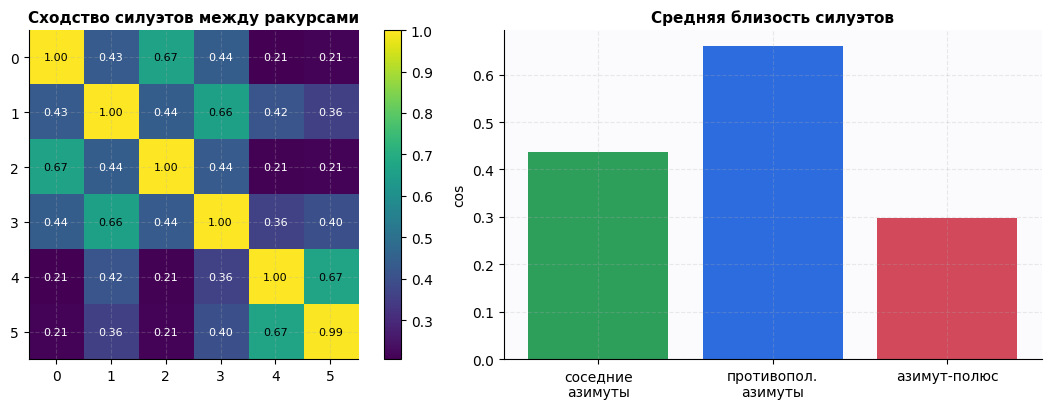

  соседние азимуты 0.437 | противоположные 0.661 | азимут-полюс 0.297
  [+] кольцевая структура подтверждена — циклическая аугментация и TTA включены

  Фолд 0 / 5
  vit_small_patch16_dinov3.lvd1689m | tile=224 | эпох 10
    объектов train / val           7161 / 1803
    шагов на эпоху                 716 (оптимизаторских 238)
    LR бэкбона                     1.59e-06 … 5.00e-05 (layer decay 0.75, блоков 12)
    LR головы                      3.00e-03


fold0 ep 1/10:   0%|          | 0/716 [00:00<?, ?it/s]

val ep1 (TTA x1):   0%|          | 0/91 [00:00<?, ?it/s]

  ep 1/10 | метрика 12.685 (raw)  = quality  6.49 + artefacts  6.20 | loss 0.842 | 1.3 мин | ост. 11м 17с <-- best
        abstr=0.68  artif=0.20  inter=0.10  lowpo=0.51  noisy=0.84  open=0.30  parti=0.59  scale=0.06  set=0.52  simpl=0.66  quali=0.65


fold0 ep 2/10:   0%|          | 0/716 [00:00<?, ?it/s]

...

  ep 9/10 | метрика 13.978 (raw)  = quality  7.06 + artefacts  6.91 | loss 0.640 | 1.7 мин | ост. 1м 43с <-- best
        abstr=0.80  artif=0.35  inter=0.15  lowpo=0.63  noisy=0.85  open=0.32  parti=0.64  scale=0.24  set=0.68  simpl=0.71  quali=0.71


fold0 ep10/10:   0%|          | 0/716 [00:00<?, ?it/s]

val ep10 (TTA x1):   0%|          | 0/91 [00:00<?, ?it/s]

val-EMA ep10 (TTA x1):   0%|          | 0/91 [00:00<?, ?it/s]

  ep10/10 | метрика 13.947 (EMA)  = quality  7.02 + artefacts  6.93 | loss 0.626 | 1.7 мин | ост. 0м 00с
        abstr=0.81  artif=0.35  inter=0.17  lowpo=0.62  noisy=0.85  open=0.32  parti=0.63  scale=0.22  set=0.70  simpl=0.71  quali=0.70


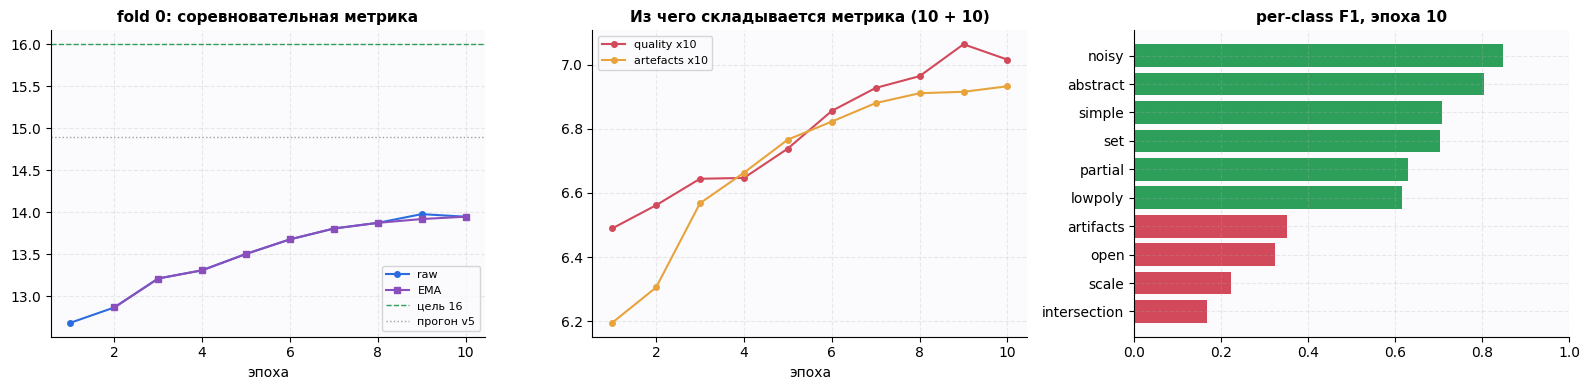

  фолд 0: лучшая эпоха 13.978 | в снапшот-ансамбле [13.98, 13.95, 13.87]


OOF snap1/3 (TTA x8):   0%|          | 0/91 [00:00<?, ?it/s]

test snap1/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

OOF snap2/3 (TTA x8):   0%|          | 0/91 [00:00<?, ?it/s]

test snap2/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

...

  ep 9/10 | метрика 14.119 (EMA)  = quality  7.30 + artefacts  6.81 | loss 0.638 | 1.9 мин | ост. 1м 48с <-- best
        abstr=0.78  artif=0.34  inter=0.18  lowpo=0.61  noisy=0.86  open=0.35  parti=0.54  scale=0.26  set=0.61  simpl=0.72  quali=0.73


fold1 ep10/10:   0%|          | 0/718 [00:00<?, ?it/s]

val ep10 (TTA x1):   0%|          | 0/90 [00:00<?, ?it/s]

val-EMA ep10 (TTA x1):   0%|          | 0/90 [00:00<?, ?it/s]

  ep10/10 | метрика 14.164 (EMA)  = quality  7.35 + artefacts  6.82 | loss 0.628 | 2.5 мин | ост. 0м 00с <-- best
        abstr=0.78  artif=0.35  inter=0.19  lowpo=0.62  noisy=0.85  open=0.33  parti=0.55  scale=0.26  set=0.61  simpl=0.72  quali=0.73


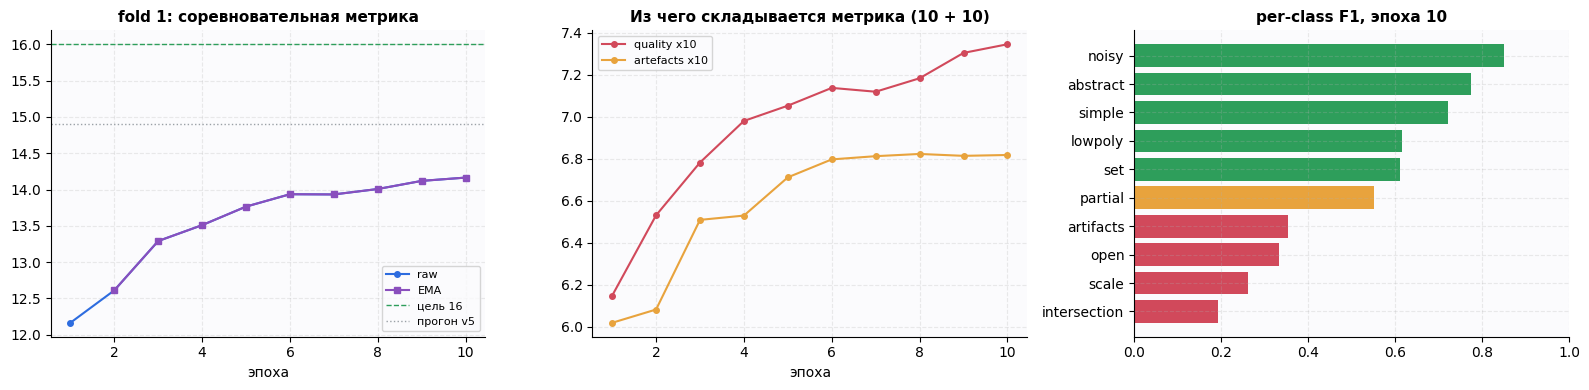

  фолд 1: лучшая эпоха 14.164 | в снапшот-ансамбле [14.16, 14.12, 14.01]


OOF snap1/3 (TTA x8):   0%|          | 0/90 [00:00<?, ?it/s]

test snap1/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

OOF snap2/3 (TTA x8):   0%|          | 0/90 [00:00<?, ?it/s]

test snap2/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

...

  ep 9/10 | метрика 13.957 (raw)  = quality  7.05 + artefacts  6.91 | loss 0.636 | 1.5 мин | ост. 1м 46с <-- best
        abstr=0.79  artif=0.29  inter=0.13  lowpo=0.66  noisy=0.84  open=0.31  parti=0.61  scale=0.21  set=0.67  simpl=0.73  quali=0.70


fold2 ep10/10:   0%|          | 0/719 [00:00<?, ?it/s]

val ep10 (TTA x1):   0%|          | 0/89 [00:00<?, ?it/s]

val-EMA ep10 (TTA x1):   0%|          | 0/89 [00:00<?, ?it/s]

  ep10/10 | метрика 13.873 (raw)  = quality  6.94 + artefacts  6.93 | loss 0.632 | 2.5 мин | ост. 0м 00с
        abstr=0.79  artif=0.29  inter=0.14  lowpo=0.67  noisy=0.85  open=0.31  parti=0.62  scale=0.20  set=0.67  simpl=0.72  quali=0.69


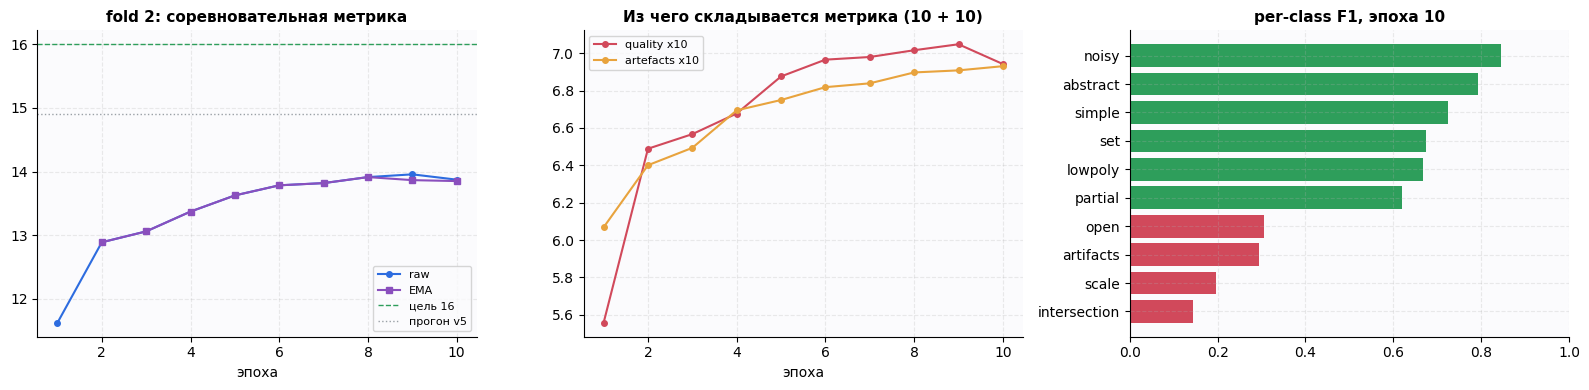

  фолд 2: лучшая эпоха 13.957 | в снапшот-ансамбле [13.96, 13.91, 13.87]


OOF snap1/3 (TTA x8):   0%|          | 0/89 [00:00<?, ?it/s]

test snap1/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

OOF snap2/3 (TTA x8):   0%|          | 0/89 [00:00<?, ?it/s]

test snap2/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

...

  ep 9/10 | метрика 13.819 (EMA)  = quality  6.98 + artefacts  6.84 | loss 0.645 | 1.8 мин | ост. 1м 46с <-- best
        abstr=0.79  artif=0.29  inter=0.21  lowpo=0.59  noisy=0.86  open=0.30  parti=0.58  scale=0.23  set=0.66  simpl=0.73  quali=0.70


fold3 ep10/10:   0%|          | 0/715 [00:00<?, ?it/s]

val ep10 (TTA x1):   0%|          | 0/91 [00:00<?, ?it/s]

val-EMA ep10 (TTA x1):   0%|          | 0/91 [00:00<?, ?it/s]

  ep10/10 | метрика 13.847 (EMA)  = quality  7.01 + artefacts  6.84 | loss 0.636 | 1.8 мин | ост. 0м 00с <-- best
        abstr=0.79  artif=0.30  inter=0.19  lowpo=0.58  noisy=0.86  open=0.30  parti=0.57  scale=0.25  set=0.66  simpl=0.72  quali=0.70


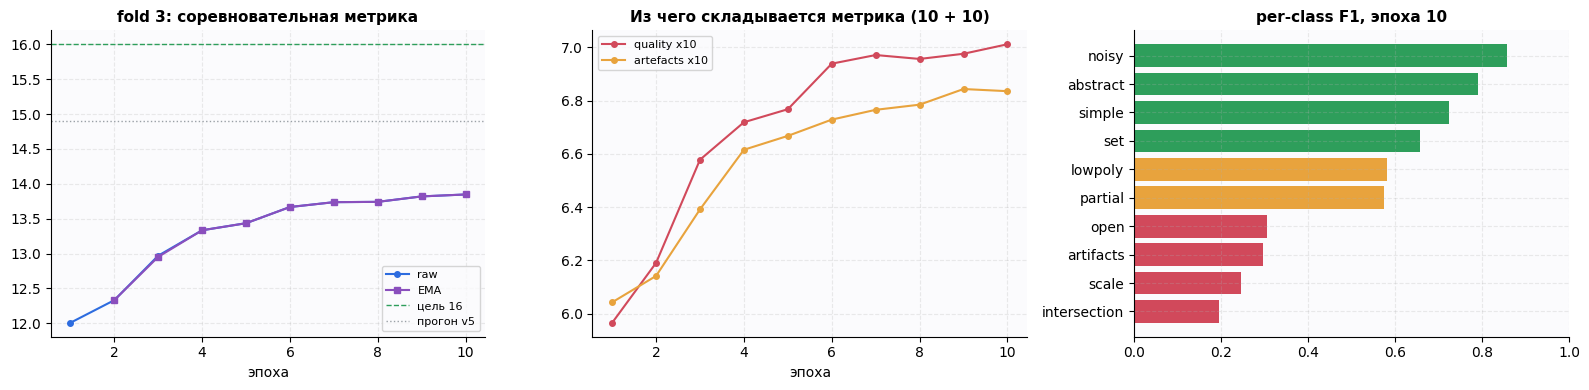

  фолд 3: лучшая эпоха 13.847 | в снапшот-ансамбле [13.85, 13.82, 13.74]


OOF snap1/3 (TTA x8):   0%|          | 0/91 [00:00<?, ?it/s]

test snap1/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

OOF snap2/3 (TTA x8):   0%|          | 0/91 [00:40<?, ?it/s]

test snap2/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

...

  ep 9/10 | метрика 13.953 (raw)  = quality  6.99 + artefacts  6.96 | loss 0.645 | 2.3 мин | ост. 1м 51с <-- best
        abstr=0.82  artif=0.38  inter=0.17  lowpo=0.63  noisy=0.85  open=0.34  parti=0.58  scale=0.23  set=0.64  simpl=0.74  quali=0.70


fold4 ep10/10:   0%|          | 0/716 [00:00<?, ?it/s]

val ep10 (TTA x1):   0%|          | 0/90 [00:00<?, ?it/s]

val-EMA ep10 (TTA x1):   0%|          | 0/90 [00:00<?, ?it/s]

  ep10/10 | метрика 13.861 (raw)  = quality  6.89 + artefacts  6.97 | loss 0.630 | 1.9 мин | ост. 0м 00с
        abstr=0.82  artif=0.37  inter=0.16  lowpo=0.63  noisy=0.85  open=0.35  parti=0.58  scale=0.25  set=0.64  simpl=0.74  quali=0.69


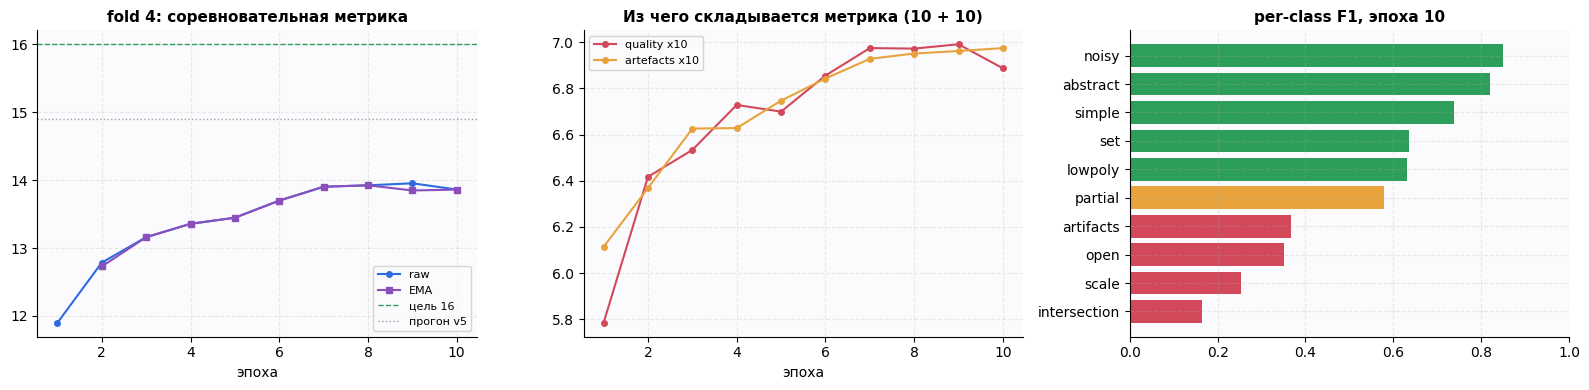

  фолд 4: лучшая эпоха 13.953 | в снапшот-ансамбле [13.95, 13.92, 13.9]


OOF snap1/3 (TTA x8):   0%|          | 0/90 [00:00<?, ?it/s]

test snap1/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

OOF snap2/3 (TTA x8):   0%|          | 0/90 [00:40<?, ?it/s]

test snap2/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

OOF snap3/3 (TTA x8):   0%|          | 0/90 [00:00<?, ?it/s]

test snap3/3 (TTA x8):   0%|          | 0/34 [00:00<?, ?it/s]

  одна лучшая эпоха 13.953  ->  снапшот-ансамбль + TTA  14.047  (++0.094)
    фолд, метрика        |███████████████·····················| 14.047
  [OK] Фолд 4 / 5 — 23.6 мин | метрика 14.047
>>> dinov3s_224: фолд 5/5 готов | от старта ноутбука прошло 2ч 31м

  ПРОГОН A завершён
  dinov3s_224
    OOF метрика                    13.790
    по фолдам                      0:13.91, 1:14.20, 2:13.87, 3:13.83, 4:14.05
    прогон A             |██████████████······················| 13.790


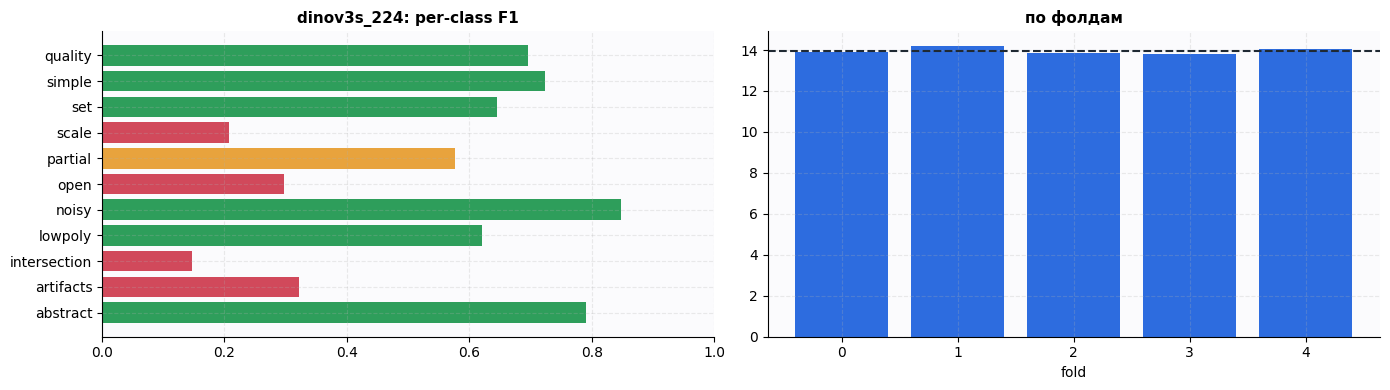

In [20]:
RUN_A = run_configuration(CONFIG_A, 'A')


### 9B. Прогон B — ConvNeXt-S (DINOv3-дистилляция) @ 256

Вторая конфигурация. Отличия от A явные и всего в шести значениях:

| параметр | A | B | почему |
|---|---|---|---|
| `backbone` | `vit_small_patch16_dinov3` | `convnext_small.dinov3_lvd1689m` | разные индуктивные смещения — ради некоррелированности ошибок |
| `tile` | 224 | 256 | свёрточной сети размер не обязан быть кратен патчу |
| `backbone_lr` | 5e-5 | 1e-4 | свёртки переносят больший LR, чем ViT после SSL-претрейна |
| `layer_decay` | 0.75 | 1.0 | послойное затухание LR — приём для ViT |
| `batch_size` | 10 | 8 | компенсация большего разрешения |
| `accum` | 3 | 4 | эффективный батч остаётся ~30 |

Геометрические признаки **не пересчитываются** — они не зависят от разрешения рендера.
Заново считаются только кэш рендеров под 256 и дешёвые силуэтные фичи.


In [22]:
# ============ фикс определения типа бэкбона ============
# IS_VIT вычислялся по подстроке во ВСЁМ имени модели, а в timm имя устроено как
# `архитектура.тег_весов`. У convnext_small.dinov3_lvd1689m тег весов содержит "dinov3",
# потому что это дистилляция DINOv3 — и свёрточная сеть получала img_size, которого
# у неё нет. Смотреть надо только на часть ДО точки.

def apply_config(cfg):
    global IS_VIT
    for k, v in cfg.items():
        setattr(CFG, k, v)
    arch = CFG.backbone.split('.')[0]          # 'convnext_small', 'vit_small_patch16_dinov3'
    IS_VIT = any(arch.startswith(p) for p in ('vit_', 'deit', 'eva', 'beit', 'swin'))
    if IS_VIT:
        patch = 16 if 'patch16' in arch else (14 if 'patch14' in arch else 8)
        if CFG.tile % patch:
            CFG.tile = int(round(CFG.tile / patch) * patch)
            R.warn(f'tile округлён до кратного патчу {patch}: {CFG.tile}')
    R.kv(**{'архитектура': arch, 'ViT-подобная': IS_VIT,
            'img_size передаётся': IS_VIT})
    return CFG

# проверка на обеих конфигурациях, прежде чем тратить часы
for c in CONFIGS:
    a = c['backbone'].split('.')[0]
    v = any(a.startswith(p) for p in ('vit_', 'deit', 'eva', 'beit', 'swin'))
    print(f"  {c['run_tag']:<12s} {a:<32s} IS_VIT={v}")

  dinov3s_224  vit_small_patch16_dinov3         IS_VIT=True
  cnxs_256     convnext_small                   IS_VIT=False


In [ ]:
RUN_B = run_configuration(CONFIG_B, 'B')
RUNS = [RUN_A, RUN_B]


    архитектура                    convnext_small
    ViT-подобная                   False
    img_size передаётся            False

  ПРОГОН B: cnxs_256
  convnext_small.dinov3_lvd1689m @ 256 | эпох 10 | батч 8x4
train: всего в кэше 8964/8964, нет картинки у 0
test: всего в кэше 669/669, нет картинки у 0
  [+] силуэты train @256: из кэша (8964, 34)
  [+] силуэты test @256: из кэша (669, 34)

  Фолд 0 / 5
  convnext_small.dinov3_lvd1689m | tile=256 | эпох 10
    объектов train / val           7161 / 1803
    шагов на эпоху                 895 (оптимизаторских 223)


model.safetensors: reconstructing file:   0%|          |  0.00B /  198MB            

model.safetensors: downloading bytes:           |  0.00B            

fold0 ep 1/10:   0%|          | 0/895 [00:00<?, ?it/s]

val ep1 (TTA x1):   0%|          | 0/113 [00:00<?, ?it/s]

...

fold0 ep 2/10:   0%|          | 0/895 [00:00<?, ?it/s]

val ep2 (TTA x1):   0%|          | 0/113 [00:00<?, ?it/s]

val-EMA ep2 (TTA x1):   0%|          | 0/113 [00:00<?, ?it/s]

  ep 2/10 | метрика  9.560 (EMA)  = quality  4.49 + artefacts  5.07 | loss 0.934 | 3.9 мин | ост. 30м 55с
        abstr=0.58  artif=0.12  inter=0.08  lowpo=0.39  noisy=0.81  open=0.17  parti=0.17  scale=0.04  set=0.25  simpl=0.55  quali=0.45


fold0 ep 3/10:   0%|          | 0/895 [00:00<?, ?it/s]

### 9C. Ансамбль двух прогонов

Усреднение в logit-пространстве и — главное — измерение **корреляции ошибок**. Именно она,
а не сила отдельных моделей, говорит, будет ли прирост: ниже 0.5 источники дополняют друг
друга, выше 0.8 — повторяют.


In [ ]:
R.section('Ансамбль двух прогонов')

tags = [r['tag'] for r in RUNS]
R.kv(**{f'прогон {chr(65 + i)}': f"{r['tag']}  ({r['backbone']} @ {r['tile']})  OOF {r['score']:.3f}"
        for i, r in enumerate(RUNS)})

mask = np.logical_and.reduce([r['mask'] for r in RUNS])
Y_OOF = train_df.loc[mask, CFG.target_cols].values
FOLDS_OOF = train_df.loc[mask, 'fold'].values
CC = ['cnn_' + c for c in CFG.target_cols]

O = [r['oof'].loc[mask, CC].values for r in RUNS]
T = [r['te'].set_index('item_id').reindex(test_df['item_id'])[CC].values for r in RUNS]


def _logit_mix(arrs):
    """Усреднение в logit-пространстве: среднее вероятностей стягивает уверенные
    предсказания к середине, среднее логитов сохраняет уверенность при согласии моделей."""
    z = np.mean([np.log(np.clip(a, 1e-6, 1 - 1e-6) / (1 - np.clip(a, 1e-6, 1 - 1e-6)))
                 for a in arrs], 0)
    return 1 / (1 + np.exp(-z))


def _sc(P):
    return competition_metric(Y_OOF, (P > quick_thresholds(Y_OOF, P)).astype(int))[0]


solo = [_sc(o) for o in O]
oof_ens, te_ens = _logit_mix(O), _logit_mix(T)
ens = _sc(oof_ens)

# Главный показатель полезности ансамбля — не сила моделей, а независимость их ошибок.
E = [np.abs(o - Y_OOF) for o in O]
r_err = float(np.mean([np.corrcoef(E[0][:, i], E[1][:, i])[0, 1] for i in range(11)]))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
names = [f'{t}\n(одиночно)' for t in tags] + ['ансамбль']
vals = solo + [ens]
ax[0].bar(range(3), vals, color=[PAL['grey'], PAL['grey'], PAL['good']])
for i, v in enumerate(vals):
    ax[0].text(i, v + .03, f'{v:.3f}', ha='center', weight='bold', fontsize=10)
ax[0].set_xticks(range(3)); ax[0].set_xticklabels(names, fontsize=8)
ax[0].set_ylim(min(vals) - .4, max(vals) + .3); ax[0].set_title('Что дал ансамбль')

f1a = per_class_f1(Y_OOF, (O[0] > quick_thresholds(Y_OOF, O[0])).astype(int))
f1b = per_class_f1(Y_OOF, (O[1] > quick_thresholds(Y_OOF, O[1])).astype(int))
f1e = per_class_f1(Y_OOF, (oof_ens > quick_thresholds(Y_OOF, oof_ens)).astype(int))
x = np.arange(11)
ax[1].bar(x - .25, f1a.values, .25, label=tags[0], color=PAL['main'])
ax[1].bar(x, f1b.values, .25, label=tags[1], color=PAL['alt'])
ax[1].bar(x + .25, f1e.values, .25, label='ансамбль', color=PAL['good'])
ax[1].set_xticks(x); ax[1].set_xticklabels(CFG.target_cols, rotation=80, fontsize=8)
ax[1].legend(fontsize=8); ax[1].set_title('F1 по классам')

ax[2].bar(['корреляция\nошибок'], [r_err],
          color=PAL['good'] if r_err < .5 else PAL['warn'] if r_err < .8 else PAL['bad'])
ax[2].axhline(.5, color=PAL['good'], ls='--'); ax[2].axhline(.8, color=PAL['bad'], ls='--')
ax[2].set_ylim(0, 1); ax[2].text(0, r_err + .03, f'{r_err:.2f}', ha='center', weight='bold')
ax[2].set_title('<0.5 берём смело, >0.8 прироста не будет')
plt.tight_layout(); plt.show()

R.kv(**{'ансамбль OOF': f'{ens:.3f}',
        'прирост к лучшему одиночному': f'{ens - max(solo):+.3f}',
        'корреляция ошибок': f'{r_err:.2f} '
                             f'({"хорошая диверсификация" if r_err < .5 else "источники похожи"})'})

# Дальше по пайплайну CNN — это ансамбль двух прогонов.
oof_cnn = pd.DataFrame({'item_id': train_df['item_id']})
for c in CFG.target_cols:
    oof_cnn['cnn_' + c] = np.nan
oof_cnn.loc[mask, CC] = oof_ens
test_cnn = pd.DataFrame(te_ens, columns=CC).assign(item_id=test_df['item_id'].values)

have_oof = pd.Series(mask, index=oof_cnn.index)
use = mask
y_oof, p_oof = Y_OOF, oof_ens
th0 = quick_thresholds(y_oof, p_oof)
CNN_SCORE = ens
_atomic(CFG.work / 'oof_cnn.csv', lambda p: oof_cnn.to_csv(p, index=False))
_atomic(CFG.work / 'test_cnn.csv', lambda p: test_cnn.to_csv(p, index=False))
R.done('Ансамбль двух прогонов', f'метрика {ens:.3f}')


### 9D. Диагностика признаков

Эти две проверки требуют собранной таблицы признаков, поэтому стоят после прогонов,
а не в §5: до первого `run_configuration` силуэтных фич ещё не существует.


In [ ]:
if 'feat_tr' in globals():
    wr = feat_tr['weld_ratio']
    print('доля мешей с дублированными вершинами (weld_ratio > 0.1): %.1f%%' % (100 * (wr > 0.1).mean()))
    print('медианный weld_ratio: %.3f  (0.67 = ровно 3 вершины на грань)' % wr.median())
    print('watertight после сварки: %.1f%% мешей (до сварки было бы 0%%)' % (100 * feat_tr['watertight'].mean()))
    print('манифолдных рёбер (2 грани): в среднем %.1f%% (до сварки было бы 0%%)'
          % (100 * feat_tr['manifold_edge_ratio'].mean()))
    print('двугранные углы посчитаны у %.1f%% мешей (до сварки — 0%%)'
          % (100 * (feat_tr['dihedf_mean'] > 0).mean()))

    topo = ['boundary_edge_ratio', 'n_boundary_loops', 'watertight', 'nonmanifold_edge_ratio',
            'dihedf_mean', 'dihed_entropy', 'solidity', 'sphericity', 'normal_top6_mass',
            'n_comp', 'comp_top1', 'defect_std', 'valence_std', 'vol_ratio', 'inside_frac_max']
    mg = train_df.merge(feat_tr, on='item_id', how='left').fillna(0.0)
    tt = pd.DataFrame({t: [np.corrcoef(mg[c], mg[t])[0, 1] for c in topo]
                       for t in CFG.target_cols}, index=topo)
    display(tt.round(3).style.background_gradient(cmap='coolwarm', vmin=-.5, vmax=.5))
    print('>>> Если в этой таблице есть |r| > 0.2 — топологическая ветка заработала.')
else:
    R.warn('признаки ещё не собраны — ячейка отработает после §9A')


In [ ]:
if 'feat_tr' in globals():
    # --- быстрая проверка полезности фич: корреляция с метками ---
    merged = train_df.merge(feat_tr, on='item_id', how='left').fillna(0.0)
    cc = pd.DataFrame({c: [np.corrcoef(merged[c], merged[t])[0, 1] for t in CFG.target_cols]
                       for c in FEAT_COLS}, index=CFG.target_cols).T
    top = cc.abs().max(1).sort_values(ascending=False).head(20).index
    display(cc.loc[top].round(3).style.background_gradient(cmap='coolwarm', vmin=-.5, vmax=.5))
    print('>>> Топ-фича на каждый класс:')
    for t in CFG.target_cols:
        print(f'  {t:13s} <- {cc[t].abs().idxmax():22s} (r={cc[t][cc[t].abs().idxmax()]:+.3f})')
else:
    R.warn('признаки ещё не собраны — ячейка отработает после §9A')


## 9.05. Дашборд прогресса

Отдельная ячейка, не зависящая от остального пайплайна: читает `training_log.csv` и
список готовых фолдов прямо с диска. Можно запускать в любой момент — хоть во время
обучения в другом процессе/сессии, хоть после обрыва — она не требует переменных из
текущего рантайма, только файлы на `CFG.work` (значит, и на новой Drive-папке §1.1).

In [ ]:
def show_progress_dashboard():
    """Читает training_log.csv и список артефактов прямо с диска, поэтому работает
    в любой момент: во время обучения из другой сессии, после обрыва, до §9."""
    done = sorted(p.stem for p in ART.glob(f'{CFG.run_tag}_fold*_preds.joblib'))
    ckpts = sorted(p.name for p in CKPT.glob(f'{CFG.run_tag}_fold*.pt'))
    R.section('Дашборд прогресса', f'{CFG.run_tag} | {CFG.work}')
    R.kv(**{'готовые фолды': [d.split('_fold')[1].split('_')[0] for d in done] or 'нет',
            'фолды в процессе': ckpts or 'нет'})

    if not LOG_CSV.exists():
        R.warn('training_log.csv ещё нет — обучение не начиналось.')
        return
    log = pd.read_csv(LOG_CSV)
    if 'fold' in log:
        log = log[log['fold'].notna()]
    if len(log) == 0:
        R.warn('лог пуст.')
        return
    log = log.drop_duplicates(['fold', 'epoch'], keep='last')

    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.28)

    # 1. метрика по эпохам
    ax = fig.add_subplot(gs[0, 0])
    for fold, g in log.groupby('fold'):
        ax.plot(g['epoch'], g['val_metric'], marker='o', ms=3, label=f'fold {int(fold)}')
    ax.axhline(16, color=PAL['good'], ls='--', lw=1)
    ax.text(0.02, 16.05, 'цель 16', color=PAL['good'], fontsize=8, transform=ax.get_yaxis_transform())
    ax.axhline(14.9, color=PAL['grey'], ls=':', lw=1)
    ax.set_xlabel('эпоха'); ax.set_ylabel('метрика'); ax.legend(fontsize=7)
    ax.set_title('Валидационная метрика')

    # 2. разложение метрики
    ax = fig.add_subplot(gs[0, 1])
    agg = log.groupby('epoch')[['f1_quality', 'f1_artefacts']].mean()
    ax.stackplot(agg.index, 10 * agg['f1_quality'], 10 * agg['f1_artefacts'],
                 labels=['quality (10 б.)', 'artefacts (10 б.)'],
                 colors=[PAL['bad'], PAL['warn']], alpha=0.85)
    ax.axhline(16, color=PAL['good'], ls='--', lw=1)
    ax.set_xlabel('эпоха'); ax.legend(fontsize=8, loc='lower right')
    ax.set_title('Вклад половин метрики (среднее по фолдам)')

    # 3. компоненты лосса
    ax = fig.add_subplot(gs[0, 2])
    lc = [c for c in ('loss_bce', 'loss_asl', 'loss_softf1', 'loss_count', 'loss_consist')
          if c in log.columns]
    if lc:
        ag = log.groupby('epoch')[lc].mean()
        for c in lc:
            ax.plot(ag.index, ag[c] / (ag[c].iloc[0] + 1e-9), label=c.replace('loss_', ''))
        ax.set_ylabel('доля от значения на 1-й эпохе'); ax.legend(fontsize=7)
    ax.set_xlabel('эпоха'); ax.set_title('Компоненты функции потерь')

    # 4. тепловая карта per-class F1 по эпохам
    ax = fig.add_subplot(gs[1, 0:2])
    f1c = [c for c in log.columns if c.startswith('f1_') and c not in ('f1_quality', 'f1_artefacts')]
    if f1c:
        H = log.groupby('epoch')[f1c].mean().T
        im = ax.imshow(H.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
        ax.set_yticks(range(len(f1c))); ax.set_yticklabels([c[3:] for c in f1c], fontsize=8)
        ax.set_xticks(range(len(H.columns))); ax.set_xticklabels(H.columns, fontsize=7)
        ax.set_xlabel('эпоха'); ax.set_title('per-class F1: как учится каждый класс')
        ax.grid(False)
        plt.colorbar(im, ax=ax, fraction=0.02)

    # 5. прогресс и ETA
    ax = fig.add_subplot(gs[1, 2]); ax.axis('off'); ax.grid(False)
    epochs_done = log.groupby('fold')['epoch'].max()
    total_exp = CFG.epochs * len(CFG.folds_to_run)
    total_done = int(epochs_done.reindex(CFG.folds_to_run, fill_value=0).clip(upper=CFG.epochs).sum())
    frac = total_done / max(total_exp, 1)
    ax.barh([0], [1], color='#e8eaed', height=0.35)
    ax.barh([0], [frac], color=PAL['main'], height=0.35)
    ax.set_xlim(0, 1); ax.set_ylim(-1.6, 0.8)
    ax.text(0.5, 0.42, f'{total_done} / {total_exp} эпох  ({100 * frac:.0f}%)',
            ha='center', fontsize=11, weight='bold')
    sec = log['sec'].median() if 'sec' in log.columns and log['sec'].notna().any() else np.nan
    if np.isnan(sec) and len(log) >= 2:
        d = pd.to_datetime(log['time']).diff().dt.total_seconds()
        sec = d[d > 0].median()
    lines = [f'медиана на эпоху: {sec / 60:.1f} мин' if not np.isnan(sec) else 'время на эпоху: —',
             f'осталось: {_fmt_eta(sec * (total_exp - total_done))}' if not np.isnan(sec) else '',
             f'лучшая метрика: {log["val_metric"].max():.3f}',
             f'последняя: {log.sort_values(["fold", "epoch"])["val_metric"].iloc[-1]:.3f}']
    for i, t in enumerate(x for x in lines if x):
        ax.text(0.0, -0.25 - 0.3 * i, t, fontsize=9)
    ax.set_title('Прогресс прогона')
    plt.show()

    print(log.groupby('fold')['val_metric'].agg(['max', 'last', 'count'])
          .rename(columns={'max': 'лучшая', 'last': 'последняя', 'count': 'эпох'}).round(3).to_string())


show_progress_dashboard()


## 9.1. Сколько стоит доверять лидерборду

Тест — **669 объектов**. Прежде чем гоняться за десятыми долями, надо знать цену деления шкалы.
Бутстрап показывает: одна и та же модель на случайных 669 объектах даёт разброс
около **±0.4 балла**, а 95%-й интервал шириной ~1.5 балла.

Отсюда практический вывод для этой задачи: разница между двумя сабмитами меньше ~0.8 балла
**не является** свидетельством того, что одно решение лучше другого. Ориентироваться надо
на OOF по 8964 объектам, а на лидерборд — только как на проверку отсутствия грубых ошибок.

In [ ]:
def leaderboard_noise(pred, y, n_test=669, n_boot=2000):
    rng = np.random.default_rng(CFG.seed)
    idx = np.arange(len(y))
    sc = np.array([competition_metric(y[i], pred[i])[0]
                   for i in (rng.choice(idx, n_test, replace=False) for _ in range(n_boot))])
    return sc

_p_tmp = (oof_cnn.loc[have_oof, ['cnn_' + c for c in CFG.target_cols]].values > th0).astype(int)
_sc = leaderboard_noise(_p_tmp, y_oof)
print(f'метрика на всех {len(y_oof)} объектах OOF: '
      f'{competition_metric(y_oof, _p_tmp)[0]:.3f}')
print(f'та же модель на случайных 669: {_sc.mean():.3f} ± {_sc.std():.3f}')
print(f'95%% интервал: [{np.percentile(_sc, 2.5):.2f}, {np.percentile(_sc, 97.5):.2f}] '
      f'-> ширина {np.percentile(_sc, 97.5) - np.percentile(_sc, 2.5):.2f} балла')
plt.figure(figsize=(9, 3))
plt.hist(_sc, bins=50, color='steelblue')
plt.axvline(_sc.mean(), color='k', ls='--', label='среднее')
plt.title('Разброс метрики на выборке размером с тест (669 объектов)')
plt.legend(); plt.tight_layout(); plt.show()

## 9.2.0. Импорт прогонов из архива

Ансамблю нужны **только** файлы `{tag}_fold{k}_preds.joblib` — сохранённые OOF- и
тест-вероятности. Веса моделей (`*.pth`) для него не требуются: предсказания уже посчитаны.

В ранних версиях ноутбука артефакты писались без префикса прогона (`fold0_preds.joblib`),
в текущей — с ним (`cnx288_fold0_preds.joblib`). Ячейка ниже принимает и то, и другое:
берёт zip-архив или папку, вытаскивает предсказания фолдов и кладёт их в `artifacts/`
под нужным именем.

In [ ]:
REQUIRED_FOR_INFERENCE = {
    'train_df': '§2 (загрузка датасета) и §6 (фолды)',
    'test_df': '§2 (загрузка датасета)',
    'feat_tr': '§5 (признаки)', 'feat_te': '§5 (признаки)',
    'FEAT_COLS': '§5 (дедупликация признаков)',
    'MeshViewDataset': '§7 (датасет)', 'MultiViewNet': '§8 (модель)',
    'predict': '§9 (обучение)', 'quick_thresholds': '§9 (обучение)',
    'TRAIN_DIR': '§2', 'TEST_DIR': '§2',
}

def check_ready(names=None):
    """Что уже определено в сессии, а какие ячейки ещё надо выполнить."""
    names = names or REQUIRED_FOR_INFERENCE
    missing = {k: v for k, v in names.items() if k not in globals()}
    if not missing:
        print('всё нужное определено'); return True
    print('не выполнены ячейки:')
    for cell in sorted(set(missing.values())):
        print(f'  {cell:35s} -> не хватает: '
              f'{", ".join(k for k, v in missing.items() if v == cell)}')
    print('\nпроще всего: Runtime -> Run all. Всё тяжёлое лежит в кэше, '
          'обучение при CFG.resume=True пропускается.')
    return False

def list_runs():
    """Какие прогоны уже доступны для ансамбля."""
    found = {}
    for p in ART.glob('*fold*_preds.joblib'):
        tag = p.stem.split('_fold')[0] or '(без тега)'
        found.setdefault(tag, []).append(int(p.stem.split('_fold')[1].split('_')[0]))
    if not found:
        print('в artifacts/ нет ни одного прогона')
    for t, ks in sorted(found.items()):
        ok = sorted(ks) == list(range(CFG.n_folds))
        print(f'  {t:14s} фолды {sorted(ks)} {"— полный" if ok else "— НЕПОЛНЫЙ, для ансамбля не годится"}')
    return found

def import_run(source, tag, overwrite=False):
    """source: путь к .zip или к папке. tag: под каким именем прогон войдёт в ансамбль."""
    src = Path(source)
    moved = []
    if src.suffix == '.zip':
        with zipfile.ZipFile(src) as z:
            members = [m for m in z.namelist() if 'fold' in m and m.endswith('_preds.joblib')]
            if not members:
                print('в архиве нет файлов *fold*_preds.joblib. Содержимое:')
                for m in z.namelist()[:30]:
                    print('   ', m)
                return []
            for m in members:
                k = Path(m).stem.split('fold')[1].split('_')[0]
                dst = ART / f'{tag}_fold{k}_preds.joblib'
                if dst.exists() and not overwrite:
                    print(f'  {dst.name} уже есть, пропускаю (overwrite=True чтобы перезаписать)')
                    continue
                with z.open(m) as f:
                    _atomic(dst, lambda p, data=f.read(): Path(p).write_bytes(data))
                moved.append(dst.name)
    else:
        for p in sorted(src.rglob('*fold*_preds.joblib')):
            k = p.stem.split('fold')[1].split('_')[0]
            dst = ART / f'{tag}_fold{k}_preds.joblib'
            if dst.exists() and not overwrite:
                print(f'  {dst.name} уже есть, пропускаю'); continue
            _atomic(dst, lambda pth, s=p: shutil.copyfile(s, pth))
            moved.append(dst.name)
    print(f'импортировано {len(moved)} файлов под тегом «{tag}»')
    # сверка: предсказания должны совпадать по числу объектов с текущими train/test
    if moved:
        d = load_artifact(f'{tag}_fold' + moved[0].split('_fold')[1].replace('_preds.joblib', '')
                          + '_preds')
        n_te = len(d['te_ids'])
        if n_te != len(test_df):
            print(f'  ВНИМАНИЕ: в импортированном прогоне {n_te} тестовых объектов, '
                  f'а сейчас {len(test_df)} — это другой датасет, ансамбль будет неверным')
        else:
            print(f'  сверка пройдена: {n_te} тестовых объектов, метрика прогона '
                  f'по его собственному OOF считается в §9.2')
    return moved

print('доступные прогоны:')
list_runs()
print()
check_ready()

# --- ПРИМЕР: раскомментируйте и укажите свой путь ---
# import_run('/content/drive/MyDrive/sber_meshqc_solution.zip', tag='cnx288')
# import_run('/content/drive/MyDrive/sber_meshqc/artifacts', tag='cnx288')
# list_runs()

### 9.2.1. Запасной путь: восстановить предсказания из сохранённых весов

Если предсказаний прошлого прогона не осталось, но есть его **веса** (`{tag}_cnn_fold*.pth`),
переобучать не нужно — достаточно инференса: 5 фолдов по паре минут вместо нескольких часов.

Веса привязаны к своей конфигурации, поэтому её надо указать явно (бэкбон, `tile`, режим видов).
Ячейка временно подменяет `CFG`, пересобирает под неё кэш рендеров и таблицу признаков
(если их нет — они кэшируются по `tile`, поэтому старые подхватятся сами), затем возвращает
`CFG` в исходное состояние.

In [ ]:
# В версии 7 оба прогона выполняются в одном проходе, поэтому восстанавливать
# предсказания из чужих весов не требуется. Ячейка оставлена как справочная.
print('доступные прогоны:')
list_runs()


## 9.2. Ансамбли: как они устроены в этом пайплайне

Ансамблирование здесь идёт на **пяти уровнях**, и их полезно различать: они стоят разного
времени и дают разный прирост.

| уровень | что усредняется | цена | типичный прирост | где в коде |
|---|---|---|---|---|
| 1. Эпохи | 3 лучшие эпохи одного фолда | бесплатно (только инференс) | +0.15…0.3 | `CFG.n_snapshots`, §9 |
| 2. TTA | вид и его отражение | ×2 инференс | +0.05…0.1 | `CFG.tta`, §9 |
| 3. Фолды | 5 моделей на тест | бесплатно (уже обучены) | — (нужен для OOF) | §9 |
| 4. Источники | CNN, GBM, STACK, POWERSET, DINO | часы на обучение каждого | +0.4…0.8 | §11 |
| 5. Конфигурации | несколько `run_tag` | ×N обучение | +0.2…0.4 | эта ячейка |

### Почему усреднение идёт в logit-пространстве

Модели откалиброваны по-разному: GBM с `scale_pos_weight` систематически завышает
вероятности редких классов, CNN после ASL — занижает. Среднее вероятностей стягивает
уверенные предсказания к середине и теряет как раз то, ради чего ансамбль и строится.
Среднее логитов `σ(Σ wᵢ·logit(pᵢ))` — это среднее геометрическое шансов; оно сохраняет
уверенность, если модели согласны, и не даёт одной некалиброванной модели перетянуть
результат. В §11 обе схемы перебираются, и выбор делается по OOF — на прошлых прогонах
всегда выигрывал logit.

### Как подбираются веса

`average='weighted'` использует support **истинных** меток, поэтому вторая половина метрики
аддитивна по классам, и веса можно подбирать **для каждого класса независимо** — это точная
оптимизация, а не эвристика. Отсюда таблица весов в §11, где, например, `abstract`
опирается на POWERSET и CNN, а `open` — на GBM и STACK.

Ограничитель: по-классовые веса включаются только для классов с support ≥ 300
(`MIN_SUPPORT_PERCLASS`). Для `intersection` и `scale` (по 107 объектов) подбор весов
по 3-5 вариантам на класс — это подгонка под шум, поэтому им достаются глобальные веса.

### Главное правило отбора: диверсификация важнее качества

Добавлять в ансамбль модель стоит не тогда, когда она сильная, а когда она **ошибается
в других местах**. Слабая модель со слабо коррелированными ошибками полезнее сильной,
дублирующей уже имеющуюся. Поэтому §10.4 печатает корреляцию ошибок с дообученной сетью:
ниже 0.5 — берём смело, выше 0.8 — прироста почти не будет.

Практические пары с низкой корреляцией ошибок в этой задаче:
свёрточная сеть против ViT (разные индуктивные смещения), дообученная сеть против
замороженной (разные источники сигнала), рендеры против геометрии (разные модальности вообще).

### Ловушка, о которой стоит знать

OOF-вероятность объекта — это предсказание **одной** модели (той, в чьём валидационном фолде
он оказался), а тестовая — среднее **пяти**. Среднее менее разбросано, поэтому распределения
на OOF и на тесте различаются, и подобранные по OOF пороги на тесте слегка съезжают.
Полностью это лечится только вложенной кросс-валидацией порогов; здесь мы измеряем эффект
в §11 (вложенная оценка против OOF) и держим правило простым, чтобы разрыв не рос.

### Рецепт: как добавить вторую конфигурацию

1. Дообучите первую (`CFG.run_tag = 'dinos224'`) до конца — она сохранит `dinos224_fold*_preds`.
2. В новой копии ноутбука поменяйте **две строки** и перезапустите §1-§9:
   `CFG.backbone = 'convnext_tiny.fb_in22k_ft_in1k'`, `CFG.run_tag = 'cnx288'`
   (для свёрточной сети можно вернуть `view_mode = 'grid'` и `tile = 288`).
3. Впишите `CFG.ensemble_tags = ['dinos224', 'cnx288']` и выполните ячейку ниже —
   она подхватит сохранённые предсказания обоих прогонов и усреднит их.
4. Дальше §10-§12 отработают уже поверх ансамбля.

Артефакты каждого прогона изолированы по `run_tag`, поэтому прогоны не мешают друг другу
и порядок их запуска не важен. Ансамблировать имеет смысл 2-3 конфигурации: четвёртая
и далее обычно добавляют меньше, чем стоит их обучение.

In [ ]:
# Ансамбль конфигураций выполняется в §9C сразу после обоих прогонов.
R.ok('ансамбль уже собран в §9C')


## 10. LightGBM на геометрии + стэкинг с учётом корреляции классов

Два уровня:

1. **Level-1 GBM** — 11 бинарных LightGBM на ~120 гео/визуальных фичах. Он ловит то,
   что CNN видит плохо: точную топологию (`open`, `artifacts`, `lowpoly`) и метрику кадра (`scale`).
2. **Level-2 стэкинг** — на вход подаются **вероятности всех 11 классов** от CNN и GBM
   (+ производные: сумма вероятностей дефектов, максимум, «мягкое ИЛИ»
   `1 - Π(1 - p_i)`). Именно здесь работает **корреляция классов**: модель для `abstract`
   видит, что объект уже помечен как `set`+`simple`, а голова `quality` видит распределение
   всех дефектов сразу. Это классический *stacked classifier chain* / *conditional dependency
   network* для multi-label (Read et al. 2011; Cheng & Hüllermeier 2009) — он даёт основной
   прирост именно на «трудных» коррелированных классах.

In [ ]:
import lightgbm as lgb

LGB_PARAMS = dict(objective='binary', learning_rate=0.03, num_leaves=31, min_child_samples=30,
                  feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
                  reg_lambda=1.0, n_estimators=700, verbosity=-1, n_jobs=-1, seed=CFG.seed)

def fit_gbm(X, Y, Xte, folds, name='gbm', params=None):
    """Возвращает (oof_prob (n,11), test_prob (m,11), список моделей)."""
    params = {**LGB_PARAMS, **(params or {})}
    oof = np.zeros((len(X), 11)); te = np.zeros((len(Xte), 11)); models = []
    for i, col in enumerate(CFG.target_cols):
        for k in range(CFG.n_folds):
            tri, vai = np.where(folds != k)[0], np.where(folds == k)[0]
            spw = max((Y[tri, i] == 0).sum() / max((Y[tri, i] == 1).sum(), 1), 1.0)
            m = lgb.LGBMClassifier(**params, scale_pos_weight=min(spw, 20.0))
            m.fit(X[tri], Y[tri, i], eval_set=[(X[vai], Y[vai, i])],
                  eval_metric='average_precision',
                  callbacks=[lgb.early_stopping(60, verbose=False)])
            oof[vai, i] = m.predict_proba(X[vai])[:, 1]
            te[:, i] += m.predict_proba(Xte)[:, 1] / CFG.n_folds
            models.append((col, k, m))
    th = quick_thresholds(Y, oof)
    print(f'{name} OOF метрика: %.3f (quality %.3f | artefacts %.3f)'
          % competition_metric(Y, (oof > th).astype(int)))
    return oof, te, models

R.section('LightGBM на геометрии', f'{len(FEAT_COLS)} признаков x 11 классов x {CFG.n_folds} фолдов')
Xg  = feat_tr.set_index('item_id').reindex(train_df['item_id'])[FEAT_COLS].fillna(0).values
Xgt = feat_te.set_index('item_id').reindex(test_df['item_id'])[FEAT_COLS].fillna(0).values
Yg  = train_df[CFG.target_cols].values
folds_arr = train_df['fold'].values

_g = cached(f'gbm_geometry_{FEAT_VER}', lambda: dict(zip(('oof', 'te', 'models'),
                                            fit_gbm(Xg, Yg, Xgt, folds_arr, name='GBM(geometry)'))))
oof_gbm, te_gbm, gbm_models = _g['oof'], _g['te'], _g['models']
display(per_class_f1(Yg, (oof_gbm > quick_thresholds(Yg, oof_gbm)).astype(int))
        .round(3).to_frame('f1_gbm'))

In [ ]:
# --- важность фич по классам: чем именно объясняется каждый дефект ---
imp = {}
for col in CFG.target_cols:
    g = [m for c, k, m in gbm_models if c == col]
    v = np.mean([m.booster_.feature_importance('gain') for m in g], 0)
    imp[col] = pd.Series(v, index=FEAT_COLS).sort_values(ascending=False)
for col in ['abstract', 'quality', 'noisy', 'lowpoly', 'open', 'set', 'intersection', 'scale']:
    print(f'{col:13s}: ' + ', '.join(imp[col].head(5).index))

## 10.4. Замороженный DINOv2 как отдельный источник

Дообученный DINOv2 из §9 — это одна модель с одной траекторией обучения. Отдельно берём тот же
SSL-претрейн **без дообучения**: прогоняем 6 видов через замороженный ViT-B/14, получаем
эмбеддинги и обучаем на них лёгкий классификатор. Это даёт три вещи:

1. **Дешёвую проверку качества признаков.** Линейный/бустинговый классификатор поверх
   замороженного DINOv2 — стандартный способ измерить, сколько семантики в признаках
   (linear probing, Oquab et al., 2023). Если он один даёт метрику близкую к дообученной сети,
   значит дообучение почти ничего не добавляет и время лучше потратить на ансамбль.
2. **Диверсификацию для ансамбля.** Его ошибки слабо коррелируют с ошибками дообученной сети:
   он не видел меток вообще, поэтому не повторяет её систематических промахов.
3. **Устойчивость.** Замороженные признаки не переобучаются под обучающую выборку.

Эмбеддинги 6 видов агрегируем как `[среднее ‖ максимум]`, сжимаем PCA до 128 компонент
(PCA обучается без меток, на train+test — это допустимо и снимает разницу масштабов),
и обучаем по фолдам тот же LightGBM, что и на геометрии.

In [ ]:
@torch.no_grad()
def dino_embeddings(ids, img_dir, split):
    # замороженный бэкбон ДРУГОГО размера, чем дообучаемый: его ошибки слабее
    # коррелируют с ошибками §9, а именно это решает, даст ли ансамбль прирост
    try:
        m = timm.create_model(CFG.dino_frozen_model, pretrained=True, num_classes=0,
                              img_size=CFG.tile).to(CFG.device).eval()
    except Exception as e:
        R.warn(f'{CFG.dino_frozen_model} недоступен ({e}); падаю на DINOv2 ViT-B/14')
        CFG.dino_frozen_model = 'vit_base_patch14_reg4_dinov2.lvd142m'
        tl = int(round(CFG.tile / 14) * 14)
        m = timm.create_model(CFG.dino_frozen_model, pretrained=True, num_classes=0,
                              img_size=tl).to(CFG.device).eval()
    mean = torch.tensor(MEAN, device=CFG.device).view(1, 3, 1, 1)
    std = torch.tensor(STD, device=CFG.device).view(1, 3, 1, 1)
    out, bs = [], 16
    for s0 in tqdm(range(0, len(ids), bs), desc=f'DINO {split}'):
        chunk = ids[s0:s0 + bs]
        batch = []
        for iid in chunk:
            p = Path(img_dir) / f'{iid}.png'
            batch.append(load_views(p, CFG.tile) if p.exists()
                         else np.full((6, CFG.tile, CFG.tile, 3), 255, np.uint8))
        x = torch.from_numpy(np.stack(batch)).to(CFG.device)
        B = x.shape[0]
        x = x.permute(0, 1, 4, 2, 3).reshape(B * 6, 3, CFG.tile, CFG.tile).float() / 255.0
        x = (x - mean) / std
        with autocast(enabled=CFG.amp):
            z = m(x).float().view(B, 6, -1)
        out.append(torch.cat([z.mean(1), z.max(1).values], 1).cpu().numpy())
    del m; gc.collect(); torch.cuda.empty_cache()
    return np.vstack(out).astype(np.float32)

if CFG.use_dino_frozen:
    from sklearn.decomposition import PCA
    Etr = cached(rt('dino_emb_train'),
                 lambda: dino_embeddings(train_df['item_id'].tolist(), IMG_TRAIN, 'train'), compress=1)
    Ete = cached(rt('dino_emb_test'),
                 lambda: dino_embeddings(test_df['item_id'].tolist(), IMG_TEST, 'test'), compress=1)
    print('размерность эмбеддинга:', Etr.shape[1])

    def _pca():
        p = PCA(n_components=min(CFG.dino_pca, Etr.shape[1]), random_state=CFG.seed)
        p.fit(np.vstack([Etr, Ete]))          # без меток -> утечки нет
        return p
    pca = cached(rt('dino_pca'), _pca)
    Ptr, Pte = pca.transform(Etr), pca.transform(Ete)
    print(f'PCA {Ptr.shape[1]} компонент объясняют {pca.explained_variance_ratio_.sum():.1%} дисперсии')

    _d = cached(rt('dino_gbm'), lambda: dict(zip(('oof', 'te', 'models'),
                fit_gbm(Ptr, Yg, Pte, folds_arr, name='DINOv2 frozen + LGBM'))))
    oof_dino, te_dino = _d['oof'], _d['te']
    display(pd.DataFrame({
        'CNN (дообученный)': per_class_f1(Yg[use], (p_oof > th0).astype(int)),
        'DINOv2 замороженный': per_class_f1(Yg, (oof_dino > quick_thresholds(Yg, oof_dino)).astype(int))
    }).round(3))

    # насколько источники независимы: корреляция ошибок решает, даст ли ансамбль прирост
    e_cnn = np.abs(p_oof - Yg[use]); e_dino = np.abs(oof_dino[use] - Yg[use])
    r_err = np.mean([np.corrcoef(e_cnn[:, i], e_dino[:, i])[0, 1] for i in range(11)])
    print(f'\nсредняя корреляция ошибок с дообученной сетью: {r_err:.2f}')
    print('  < 0.5 — источники дополняют друг друга, ансамбль даст заметный прирост')
    print('  > 0.8 — источники повторяют друг друга, прироста почти не будет')
else:
    oof_dino = te_dino = None
    print('замороженный DINOv2 выключен (CFG.use_dino_frozen = False)')

In [ ]:
def stack_features(cnn_prob, gbm_prob):
    """Level-2 фичи: сырые вероятности обеих моделей + агрегаты, кодирующие зависимость меток."""
    parts = [cnn_prob, gbm_prob, np.abs(cnn_prob - gbm_prob), (cnn_prob + gbm_prob) / 2]
    for P in (cnn_prob, gbm_prob):
        d = P[:, :10]
        soft_or = 1 - np.prod(1 - d, axis=1, keepdims=True)      # P(хоть один дефект)
        parts += [d.sum(1, keepdims=True), d.max(1, keepdims=True),
                  np.sort(d, 1)[:, -2:-1], soft_or,
                  (-(d * np.log(d + 1e-9) + (1 - d) * np.log(1 - d + 1e-9))).mean(1, keepdims=True)]
    return np.concatenate(parts, 1).astype(np.float32)

S_tr = stack_features(oof_cnn[['cnn_' + c for c in CFG.target_cols]].fillna(0.5).values, oof_gbm)
S_te = stack_features(test_cnn.set_index('item_id').reindex(test_df['item_id'])
                      [['cnn_' + c for c in CFG.target_cols]].values, te_gbm)
# добавляем сырые гео-фичи — level-2 может уточнить решение по топологии
S_tr = np.concatenate([S_tr, Xg], 1)
S_te = np.concatenate([S_te, Xgt], 1)
# globals().get, а не голое имя: ячейку §10.4 могли не выполнить (или выключить флагом),
# и стэкинг обязан работать без неё
_od, _td = globals().get('oof_dino'), globals().get('te_dino')
if _od is not None:           # замороженный DINOv2 участвует и в стэкинге
    S_tr = np.concatenate([S_tr, _od], 1)
    S_te = np.concatenate([S_te, _td], 1)
    print('в стэкинг добавлены вероятности замороженного DINOv2')

STACK_PARAMS = dict(learning_rate=0.02, num_leaves=15, min_child_samples=40,
                    feature_fraction=0.6, n_estimators=600)
_st = cached(rt(f'stack_{FEAT_VER}'), lambda: dict(zip(('oof', 'te'),
             fit_gbm(S_tr[use], Yg[use], S_te, folds_arr[use],
                     name='STACK (level-2)', params=STACK_PARAMS)[:2])))
oof_st, te_st = _st['oof'], _st['te']

## 10.5. Label-powerset: совместное распределение меток

### Зачем

`quality` — это **половина метрики** и по определению функция *совместного* распределения:
`quality = 1` ⟺ все десять дефектов равны нулю. До сих пор мы оценивали её двумя способами,
и оба плохи:

* отдельной головой — она не обязана быть согласована с предсказанными дефектами;
* произведением маргиналов `∏(1 − pᵢ)` — это прямое предположение **независимости** меток,
  которое разметка опровергает (см. матрицу ко-встречаемости в §3).

Здесь мы моделируем совместное распределение честно. В обучающей выборке всего **208**
различных комбинаций меток, причём топ-25 покрывают **94.4%** объектов, топ-30 — 95.3%.
Это позволяет решать задачу как **многоклассовую по комбинациям** (label powerset,
Tsoumakas & Katakis, 2007): один softmax по 30 комбинациям + класс «прочее».

Из совместного распределения бесплатно получаются обе нужные величины:

* **маргиналы** `P(classᵢ = 1) = Σ_c P(c) · [i ∈ c]` — уже согласованные между собой;
* **`P(quality)` = `P(комбинация «все нули»)`** — без предположения независимости.

### Почему это помогает и редким классам

`intersection` и `scale` встречаются в одиночку лишь в 31 и 29 случаях из 107 — в 71-73%
они идут в связке с другими дефектами (`intersection` чаще с `lowpoly`/`artifacts`,
`scale` — с `set`/`partial`). Powerset предсказывает такую связку целиком, а не пытается
независимо поймать 1.2% позитивов.

### Проверка на симуляции (level-1 качества как в предыдущем прогоне)

| величина | level-1 | маргиналы powerset | смесь 50/50 |
|---|---|---|---|
| weighted F1 дефектов | 0.669 | 0.658 | **0.696** |
| F1(quality) | 0.667 (голова) / 0.451 (произведение маргиналов) | **0.734** | 0.738 |
| итог | 13.35 | — | **14.35** |

Сырые маргиналы powerset для редких классов хуже (их «съедает» класс «прочее»), поэтому
powerset входит в бленд **как ещё один источник**, а не заменяет остальные — вес каждому
классу подбирается отдельно в §11.

In [ ]:
POWERSET_K = 30

def fit_powerset(S_train, Y_train, S_test, folds):
    """Многоклассовая модель по комбинациям меток -> (маргиналы, P(все нули)) для train и test."""
    combos = pd.Series(list(map(tuple, Y_train[:, :10]))).value_counts()
    top = list(combos.index[:POWERSET_K])
    cmap = {c: i for i, c in enumerate(top)}
    zero_key = tuple([0] * 10)
    if zero_key not in cmap:                       # «хороший объект» обязан быть в словаре
        cmap[zero_key] = len(cmap); top.append(zero_key)
    K = len(top)
    lab = np.array([cmap.get(tuple(r), K) for r in Y_train[:, :10]])
    cover = float((lab < K).mean())
    print(f'  комбинаций всего {len(combos)}, взято {K}, покрытие {cover:.1%}')

    M = np.zeros((K + 1, 10))                      # матрица «комбинация -> метки»
    for c, i in cmap.items():
        M[i] = c
    # класс «прочее»: усредняем метки попавших в него объектов (иначе он вносил бы нули)
    rest = lab == K
    if rest.any():
        M[K] = Y_train[rest][:, :10].mean(0)

    oof = np.zeros((len(S_train), K + 1)); te = np.zeros((len(S_test), K + 1))
    for k in range(CFG.n_folds):
        tr_i, va_i = np.where(folds != k)[0], np.where(folds == k)[0]
        m = lgb.LGBMClassifier(objective='multiclass', num_class=K + 1, n_estimators=400,
                               learning_rate=0.05, num_leaves=31, min_child_samples=30,
                               feature_fraction=0.7, bagging_fraction=0.8, bagging_freq=1,
                               verbosity=-1, n_jobs=-1, seed=CFG.seed)
        m.fit(S_train[tr_i], lab[tr_i], eval_set=[(S_train[va_i], lab[va_i])],
              callbacks=[lgb.early_stopping(50, verbose=False)])
        oof[va_i] = m.predict_proba(S_train[va_i])
        te += m.predict_proba(S_test) / CFG.n_folds

    def unpack(p):
        marg = p @ M                                # (n,10) согласованные маргиналы
        p_zero = p[:, cmap[zero_key]]               # P(нет ни одного дефекта)
        return np.column_stack([marg, p_zero])      # (n,11) — тот же формат, что у прочих источников
    return unpack(oof), unpack(te), {'K': K, 'cover': cover}

_pw = cached(rt(f'powerset_{FEAT_VER}'), lambda: dict(zip(('oof', 'te', 'info'),
             fit_powerset(S_tr[use], Yg[use], S_te, folds_arr[use]))))
oof_pw, te_pw = _pw['oof'], _pw['te']

th_pw = quick_thresholds(Yg[use], oof_pw)
print('powerset OOF метрика: %.3f (quality %.3f | artefacts %.3f)'
      % competition_metric(Yg[use], (oof_pw > th_pw).astype(int)))
cmp_pw = pd.DataFrame({
    'level-1 (стэк)': per_class_f1(Yg[use], (oof_st > quick_thresholds(Yg[use], oof_st)).astype(int)),
    'powerset': per_class_f1(Yg[use], (oof_pw > th_pw).astype(int))}).round(3)
cmp_pw['дельта'] = (cmp_pw['powerset'] - cmp_pw['level-1 (стэк)']).round(3)
display(cmp_pw)
print('P(quality) без предположения независимости: F1 %.3f | через произведение маргиналов: F1 %.3f'
      % (f1_score(Yg[use][:, 10], (oof_pw[:, 10] > th_pw[10]).astype(int), zero_division=0),
         f1_score(Yg[use][:, 10],
                  (np.prod(1 - oof_st[:, :10], 1) > 0.5).astype(int), zero_division=0)))

## 11. Решающее правило: по-классовый бленд, точные пороги, стратегия `quality`

### Ключевое наблюдение, которое упрощает всю оптимизацию

`f1_score(..., average='weighted')` взвешивает по **support истинных меток**, а он от
предсказаний не зависит. Значит вторая половина метрики строго аддитивна:

$$\text{score} = 10\cdot F_1(\text{quality}) + 10\sum_{i=1}^{10} w_i F_1(\text{class}_i),\qquad w_i=\frac{n_i}{\sum_j n_j}$$

Отсюда два следствия, которых не использовал прошлый прогон:

1. **Пороги и веса бленда для каждого дефекта можно подбирать независимо** — это не эвристика,
   а точная покоординатная оптимизация. Никакого coordinate ascent по всем 11 порогам не нужно.
2. Порог, максимизирующий $F_1$, находится **точно** за один проход сортировки
   (перебор сетки 0.02 его лишь приближал): отсортировав объекты по убыванию вероятности,
   $F_1@k = \frac{2\,TP@k}{k + P}$, и достаточно взять максимум по $k$.

### Что добавлено

* **По-классовые веса бленда** CNN/GBM/STACK вместо одного глобального вектора: GBM силён на
  `noisy`/`lowpoly` (топология), CNN — на `abstract`/`set` (семантика), и смешивать их
  в одинаковой пропорции для всех классов заведомо неоптимально.
* **Бленд в logit-пространстве** как альтернатива усреднению вероятностей (выбор по OOF):
  модели откалиброваны по-разному, среднее вероятностей сжимает уверенные предсказания.
* **`quality` как смесь** прямой головы и «мягкого правила» $\prod_i (1-p_i)$ с весом $\alpha$,
  подбираемым по OOF. Жёсткое OR-правило прошлого прогона — частный случай $\alpha=0$
  с бинаризацией до перемножения, и оно теряло 0.41 балла.
* **Честная вложенная оценка**: правило настраивается на 4 фолдах и проверяется на 5-м.
  Разница между «настроено и проверено на одних данных» и вложенной оценкой показывает,
  сколько из прироста — переобучение решающего правила.

### Плато вместо острого максимума

Для редких классов (`intersection`, `scale` — по 107 объектов) точный argmax $F_1$ по порогу
переобучается на единичные объекты. Поэтому берём **середину плато**: среди порогов, дающих
$F_1 \ge 0.995\,F_1^{max}$, выбираем медианный.

In [ ]:
import itertools

R.section('Решающее правило', 'выбор варианта по ВЛОЖЕННОЙ оценке, а не по подгонке на OOF')


def to_logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def to_rank(p):
    """Ранговое пространство бленда.

    Логит-среднее всё ещё чувствительно к калибровке: GBM со `scale_pos_weight` смещает
    целое распределение, и среднее тянется за ним. F1-порог зависит только от ПОРЯДКА
    объектов, поэтому ранги — самый безопасный способ смешать плохо откалиброванные
    источники. Какое из трёх пространств лучше, решает вложенная оценка.
    """
    p = np.asarray(p, dtype=np.float64)
    sq = p.ndim == 1
    if sq:
        p = p[:, None]
    out = np.empty_like(p); n = len(p)
    for j in range(p.shape[1]):
        o = np.argsort(p[:, j], kind='stable')
        r = np.empty(n); r[o] = np.arange(n)
        out[:, j] = r / max(n - 1, 1)
    return out[:, 0] if sq else out


def combine(parts, w, space):
    w = np.asarray(w, dtype=np.float64)
    w = np.ones(len(parts)) if w.sum() <= 0 else w / w.sum()
    if space == 'prob':
        return sum(wi * p for wi, p in zip(w, parts))
    if space == 'rank':
        return sum(wi * to_rank(p) for wi, p in zip(w, parts))
    return 1.0 / (1.0 + np.exp(-sum(wi * to_logit(p) for wi, p in zip(w, parts))))


_WG = {}


def weight_grid(k, coarse=False):
    key = (k, coarse)
    if key not in _WG:
        step = (0, .5, 1.) if (coarse or k > 3) else (0, .25, .5, .75, 1.)
        _WG[key] = [w for w in itertools.product(step, repeat=k) if sum(w) > 0]
    return _WG[key]


def fit_rule(parts, Y, space=None, min_support=300, coarse=False):
    spaces = ['prob', 'logit', 'rank'] if space is None else [space]
    grid = weight_grid(len(parts), coarse)
    best = None
    for sp in spaces:
        sup = Y[:, :10].sum(0).astype(np.float64); wc = sup / max(sup.sum(), 1)
        gb, gw = -1, tuple([1] * len(parts))
        for w in grid:
            pb = combine(parts, w, sp)
            v = sum(wc[i] * exact_f1_threshold(Y[:, i], pb[:, i])[1] for i in range(10))
            if v > gb:
                gb, gw = v, w
        W = np.tile(np.asarray(gw, dtype=np.float64), (11, 1))
        for i in range(11):
            if int(Y[:, i].sum()) < min_support:
                continue
            cb, cw = -1, gw
            for w in grid:
                v = exact_f1_threshold(Y[:, i],
                                       combine([p[:, [i]] for p in parts], w, sp)[:, 0])[1]
                if v > cb:
                    cb, cw = v, w
            W[i] = cw
        prob = np.column_stack([combine([p[:, [i]] for p in parts], W[i], sp)[:, 0]
                                for i in range(11)])
        th = np.array([exact_f1_threshold(Y[:, i], prob[:, i])[0] for i in range(10)])
        pd_ = (prob[:, :10] > th).astype(int)
        fa = f1_score(Y[:, :10], pd_, average='weighted', zero_division=0)
        soft = np.prod(1 - np.clip(prob[:, :10], 0, 1), 1)
        hard = (pd_.sum(1) == 0).astype(float)
        qb = (-1, .5, .5, 'mix')
        for a in np.arange(0, 1.01, .05):
            pq = a * prob[:, 10] + (1 - a) * soft
            t, v = exact_f1_threshold(Y[:, 10], pq)
            if v > qb[0]:
                qb = (v, float(a), float(t), 'mix')
        for mode in ('and', 'or'):
            for a in np.arange(0, 1.01, .1):
                pq = a * prob[:, 10] + (1 - a) * soft
                t, _ = exact_f1_threshold(Y[:, 10], pq)
                q = ((pq > t) * hard if mode == 'and' else np.maximum((pq > t), hard))
                v = f1_score(Y[:, 10], q.astype(int), zero_division=0)
                if v > qb[0]:
                    qb = (v, float(a), float(t), mode)
        tot = 10 * qb[0] + 10 * fa
        if best is None or tot > best['oof']:
            best = {'space': sp, 'W': W, 'th': th, 'q_alpha': qb[1], 'q_th': qb[2],
                    'q_mode': qb[3], 'oof': tot, 'rate': pd_.mean(0)}
    return best


def apply_rule(parts, RL, rates=None):
    """rates: целевые доли положительных. Если переданы, пороги берутся как квантили
    распределения ИМЕННО этой выборки — см. §11.2 про сдвиг OOF против теста."""
    W = np.asarray(RL['W'])
    if W.shape != (11, len(parts)):
        raise ValueError(f'правило обучено на {W.shape[1]} источниках, подано {len(parts)}')
    prob = np.column_stack([combine([p[:, [i]] for p in parts], W[i], RL['space'])[:, 0]
                            for i in range(11)])
    if rates is None:
        th = RL['th']
    else:
        th = np.array([np.quantile(prob[:, i], 1 - min(max(rates[i], 1e-4), .999))
                       for i in range(10)])
    pd_ = (prob[:, :10] > th).astype(int)
    soft = np.prod(1 - np.clip(prob[:, :10], 0, 1), 1)
    hard = (pd_.sum(1) == 0).astype(int)
    pq = RL['q_alpha'] * prob[:, 10] + (1 - RL['q_alpha']) * soft
    qh = (pq > RL['q_th']).astype(int)
    q = {'mix': qh, 'and': qh * hard, 'or': np.maximum(qh, hard)}[RL['q_mode']]
    return np.concatenate([pd_, q[:, None]], 1), prob


def bag_rules(Rs):
    out = dict(Rs[0])
    out['W'] = np.mean([np.asarray(r['W']) for r in Rs], 0)
    out['th'] = np.mean([r['th'] for r in Rs], 0)
    out['q_alpha'] = float(np.mean([r['q_alpha'] for r in Rs]))
    out['q_th'] = float(np.mean([r['q_th'] for r in Rs]))
    for k in ('q_mode', 'space'):
        v = [r[k] for r in Rs]; out[k] = max(set(v), key=v.count)
    out['rate'] = np.mean([r['rate'] for r in Rs], 0)
    return out


def fit_bagged(parts, Y, folds, min_support=300, coarse=False):
    """Порог — оценка по выборке, у неё есть дисперсия. Настройка правила на пяти
    подвыборках и усреднение снижает её, не стоя ни одной эпохи обучения."""
    ks = np.unique(folds)
    Rs = [fit_rule([p[folds != k] for p in parts], Y[folds != k], None, min_support, coarse)
          for k in ks]
    sp_list = [r['space'] for r in Rs]
    sp = max(set(sp_list), key=sp_list.count)
    Rs = [r if r['space'] == sp else
          fit_rule([p[folds != k] for p in parts], Y[folds != k], sp, min_support, coarse)
          for r, k in zip(Rs, ks)]
    return bag_rules(Rs)


def nested_eval(fit_fn, parts, Y, folds):
    sc = []
    for k in np.unique(folds):
        tr, va = folds != k, folds == k
        Rk = fit_fn([p[tr] for p in parts], Y[tr], folds[tr])
        pk, _ = apply_rule([p[va] for p in parts], Rk)
        sc.append(competition_metric(Y[va], pk)[0])
    return np.array(sc)


# ---------------------------------- источники ----------------------------------
P_oof = [p_oof, oof_gbm[use], oof_st, oof_pw]
P_te  = [test_cnn.set_index('item_id').reindex(test_df['item_id'])[CC].values,
         te_gbm, te_st, te_pw]
SOURCES = ['CNN(ансамбль)', 'GBM', 'STACK', 'POWERSET']
_od, _td = globals().get('oof_dino'), globals().get('te_dino')
if _od is not None:
    P_oof.append(_od[use]); P_te.append(_td); SOURCES.append('DINO')
Y_use, folds_use = y_oof, FOLDS_OOF
R.kv(**{'источники': ', '.join(SOURCES), 'объектов OOF': len(Y_use)})

VARIANTS = {
    'по-классовые веса (как раньше)': lambda P, Y, f: fit_rule(P, Y, min_support=300),
    'только глобальные веса':         lambda P, Y, f: fit_rule(P, Y, min_support=10 ** 9),
    'бэггинг правила':                lambda P, Y, f: fit_bagged(P, Y, f, min_support=300),
    'бэггинг + глобальные веса':      lambda P, Y, f: fit_bagged(P, Y, f, min_support=10 ** 9),
    'бэггинг + глобальные + грубая':  lambda P, Y, f: fit_bagged(P, Y, f, min_support=10 ** 9,
                                                                 coarse=True),
}

rows = {}
for nm, fn in VARIANTS.items():
    t0 = time.time()
    s = nested_eval(fn, P_oof, Y_use, folds_use)
    rows[nm] = (s.mean(), s.std(), time.time() - t0)
    print(f'  {nm:<34s} вложенная {s.mean():6.3f} ± {s.std():.3f}   ({time.time() - t0:.0f} c)')

NEST = pd.DataFrame(rows, index=['вложенная', 'разброс', 'сек']).T.sort_values(
    'вложенная', ascending=False)
BEST_RULE_NAME = NEST.index[0]
RULE = cached(f'rule_{len(SOURCES)}src_{FEAT_VER}',
              lambda: VARIANTS[BEST_RULE_NAME](P_oof, Y_use, folds_use))
if np.asarray(RULE['W']).shape != (11, len(P_oof)):
    RULE = save_artifact(f'rule_{len(SOURCES)}src_{FEAT_VER}',
                         VARIANTS[BEST_RULE_NAME](P_oof, Y_use, folds_use))

pred_oof, prob_oof = apply_rule(P_oof, RULE)
OOF_SCORE, f_q, f_a = competition_metric(Y_use, pred_oof)
NESTED_SCORE = float(NEST.iloc[0]['вложенная'])

R.kv(**{'выбранный вариант': BEST_RULE_NAME,
        'пространство бленда': RULE['space'],
        'quality': f"{RULE['q_mode']}, alpha={RULE['q_alpha']:.2f}",
        'OOF метрика': f'{OOF_SCORE:.3f}',
        'вложенная (ожидание на ЛБ)': f'{NESTED_SCORE:.3f}',
        'разрыв = переобучение правила': f'{OOF_SCORE - NESTED_SCORE:.3f}'})

fig, ax = plt.subplots(1, 2, figsize=(15, 4.3))
r_ = NEST.sort_values('вложенная')
ax[0].barh(range(len(r_)), r_['вложенная'], xerr=r_['разброс'], capsize=4,
           color=[PAL['good'] if i == len(r_) - 1 else PAL['grey'] for i in range(len(r_))])
ax[0].set_yticks(range(len(r_))); ax[0].set_yticklabels(r_.index, fontsize=8)
ax[0].set_xlim(min(r_['вложенная']) - .3, max(r_['вложенная']) + .3)
ax[0].set_title('Вложенная метрика вариантов правила')

wdf = pd.DataFrame(RULE['W'], index=CFG.target_cols, columns=SOURCES)
im = ax[1].imshow(wdf.values, cmap='Blues', aspect='auto')
ax[1].set_xticks(range(len(SOURCES))); ax[1].set_xticklabels(SOURCES, rotation=25,
                                                             ha='right', fontsize=8)
ax[1].set_yticks(range(11)); ax[1].set_yticklabels(CFG.target_cols, fontsize=8); ax[1].grid(False)
for i in range(11):
    for j in range(len(SOURCES)):
        ax[1].text(j, i, f'{wdf.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax[1].set_title('Веса источников по классам')
plt.tight_layout(); plt.show()


In [ ]:
# (источники и правило собраны ячейкой выше)


In [ ]:
# Вложенная оценка уже посчитана при выборе варианта правила (см. таблицу выше):
# каждый вариант настраивался на 4 фолдах и проверялся на 5-м.
nested = nested_eval(VARIANTS[BEST_RULE_NAME], P_oof, Y_use, folds_use)
print('вложенная оценка по фолдам:', np.round(nested, 3))
print('вложенная средняя: %.3f (± %.3f)  |  настроено-и-проверено на OOF: %.3f'
      % (nested.mean(), nested.std(), OOF_SCORE))
print('>>> На лидерборде стоит ожидать величину, близкую к вложенной оценке.')


In [ ]:
rep = pd.DataFrame({'f1': per_class_f1(Y_use, pred_oof).round(3),
                    'true_rate': Y_use.mean(0).round(3),
                    'pred_rate': pred_oof.mean(0).round(3),
                    'weight': np.append(Y_use[:, :10].sum(0) / Y_use[:, :10].sum(), np.nan).round(3)},
                   index=CFG.target_cols)
rep['получено, баллов'] = (10 * rep['f1'] * rep['weight']).round(3)
rep['потолок, баллов'] = (10 * rep['weight']).round(3)
rep.loc['quality', ['получено, баллов', 'потолок, баллов']] = [round(10 * f_q, 3), 10.0]
rep['резерв'] = (rep['потолок, баллов'] - rep['получено, баллов']).round(3)
display(rep.sort_values('резерв', ascending=False))

# ---------- инфографика: получено против потолка + калибровка предсказаний ----------
fig = plt.figure(figsize=(16, 5.5))
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.0, 1.0], wspace=0.3)

ax = fig.add_subplot(gs[0, 0])
b = rep.drop(index='quality').sort_values('потолок, баллов')
y = np.arange(len(b))
ax.barh(y, b['потолок, баллов'], color='#e3e6ea', label='потолок')
ax.barh(y, b['получено, баллов'], color=PAL['main'], label='получено')
ax.set_yticks(y); ax.set_yticklabels(b.index)
for i, (g, c) in enumerate(zip(b['получено, баллов'], b['потолок, баллов'])):
    ax.text(c + 0.02, i, f'резерв {c - g:.2f}', va='center', fontsize=8, color=PAL['grey'])
ax.set_xlim(0, b['потолок, баллов'].max() * 1.45)
ax.legend(fontsize=8, loc='lower right')
ax.set_title(f'Дефекты: получено {b["получено, баллов"].sum():.2f} из 10 возможных')

ax = fig.add_subplot(gs[0, 1])
ax.bar(['получено', 'резерв'], [10 * f_q, 10 - 10 * f_q], color=[PAL['bad'], '#e3e6ea'])
ax.bar(['получено', 'резерв'], [0, 0])
ax.set_ylim(0, 10.5); ax.set_title(f'quality: {10 * f_q:.2f} из 10')
ax.text(0, 10 * f_q + 0.2, f'F1={f_q:.3f}', ha='center', fontsize=10, weight='bold')

ax = fig.add_subplot(gs[0, 2])
x = np.arange(11)
ax.bar(x - 0.2, rep['true_rate'], 0.4, label='истинная доля', color=PAL['dark'])
ax.bar(x + 0.2, rep['pred_rate'], 0.4, label='предсказанная', color=PAL['warn'])
ax.set_xticks(x); ax.set_xticklabels(CFG.target_cols, rotation=90, fontsize=8)
ax.legend(fontsize=8); ax.set_title('Не пересаливаем ли с дефектами')
plt.show()

over = rep.drop(index='quality')
bias = (over['pred_rate'] - over['true_rate'])
worst = bias.abs().idxmax()
print(f'>>> Сильнее всего смещена доля предсказаний у «{worst}»: '
      f'{over.loc[worst, "pred_rate"]:.3f} против истинных {over.loc[worst, "true_rate"]:.3f} '
      f'({bias[worst]:+.3f}).')
print('>>> Перебор с дефектами напрямую режет quality: объект с одной ложной сработкой '
      'перестаёт считаться хорошим.')

# сравнение с правилом прошлого прогона (глобальные веса + жёсткое OR)
R_old = dict(RULE); R_old['q_alpha'] = 0.0; R_old['q_mode'] = 'and'
R_old['W'] = np.tile(RULE['W'][0], (11, 1))
p_old, _ = apply_rule(P_oof, R_old)
s_old = competition_metric(Y_use, p_old)[0]
print(f'>>> Правило прошлого прогона на тех же вероятностях: {s_old:.3f}  ->  новое: {OOF_SCORE:.3f} '
      f'({OOF_SCORE - s_old:+.3f})')


### 11.1. Разбор просевших классов

In [ ]:
from sklearn.metrics import confusion_matrix

for cls in ['abstract', 'quality', 'open', 'artifacts']:
    i = CFG.target_cols.index(cls)
    tn, fp, fn, tp = confusion_matrix(Y_use[:, i], pred_oof[:, i]).ravel()
    print(f'--- {cls:10s} precision {tp / max(tp + fp, 1):.3f} | recall {tp / max(tp + fn, 1):.3f} '
          f'| FP={fp} FN={fn}')
    miss = (Y_use[:, i] == 1) & (pred_oof[:, i] == 0)
    if miss.sum() and cls != 'quality':
        co = pd.Series(Y_use[miss][:, :10].mean(0), index=CFG.artifact_cols)
        base = pd.Series(Y_use[Y_use[:, i] == 1][:, :10].mean(0), index=CFG.artifact_cols)
        lift = (co / (base + 1e-9)).drop(cls).sort_values(ascending=False).head(3)
        print('    чаще всего пропускается вместе с:', {k: round(v, 2) for k, v in lift.items()})

## 12. Сабмит

In [ ]:
R.section('Сабмит', 'коррекция порогов под сдвиг распределения OOF -> тест')

pred_te_abs, prob_te = apply_rule(P_te, RULE)
rate_oof = pred_oof.mean(0)
prior = Y_use.mean(0)
std_oof, std_te = prob_oof.std(0), prob_te.std(0)
shrink = float(np.median(std_te / (std_oof + 1e-9)))

# Вероятность OOF даёт ОДНА модель (та, в чьём валидационном фолде объект оказался),
# а тестовая — среднее пяти фолдов, да ещё и двух прогонов. Среднее менее разбросано,
# поэтому один и тот же абсолютный порог отсекает на тесте другую долю объектов.
# Переходим от абсолютного порога к целевой доле; для редких классов доля по 669 объектам
# сама шумная, поэтому подмешиваем априорную долю из train.
n_exp = rate_oof[:10] * len(P_te[0])
lam = np.clip(n_exp / (n_exp + 25.0), 0, 1)
rates_target = lam * rate_oof[:10] + (1 - lam) * prior[:10]
pred_te_q, _ = apply_rule(P_te, RULE, rates=rates_target)
pred_te_q[:, 10] = pred_te_abs[:, 10]
pred_te_mix = ((pred_te_abs.astype(float) + pred_te_q.astype(float)) >= 1.5).astype(int)
pred_te_mix[:, 10] = pred_te_abs[:, 10]

if shrink < 0.90:
    PRED_TE = pred_te_q
    R.warn(f'разброс на тесте сжат в {1 / shrink:.2f} раза — перехожу на пороги по доле')
elif shrink < 0.97:
    PRED_TE = pred_te_mix
    R.warn(f'сжатие умеренное ({shrink:.2f}) — беру консервативный вариант '
           f'(метка ставится при согласии обоих порогов)')
else:
    PRED_TE = pred_te_abs
    R.ok(f'сжатия практически нет ({shrink:.2f}) — оставляю абсолютные пороги')

sub = pd.DataFrame(PRED_TE, columns=CFG.target_cols)
sub.insert(0, 'item_id', test_df['item_id'].values)
sub = sub[['item_id'] + CFG.target_cols]
assert len(sub) == len(test_df) and sub['item_id'].is_unique
assert set(sub.columns) == set(pd.read_csv(TRAIN_CSV).columns)
sub.to_csv('submission.csv', index=False)
_atomic(CFG.work / 'submission.csv', lambda p: sub.to_csv(p, index=False))

R.kv(**{'submission.csv': f'{sub.shape[0]} строк',
        'изменено против абс. порога': int((PRED_TE != pred_te_abs).sum()),
        'доля quality=1': f"{sub['quality'].mean():.3f} (в train {train_df['quality'].mean():.3f})"})

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
x = np.arange(11)
ax[0].bar(x - .27, prior, .27, label='train', color=PAL['dark'])
ax[0].bar(x, rate_oof, .27, label='OOF', color=PAL['main'])
ax[0].bar(x + .27, PRED_TE.mean(0), .27, label='сабмит', color=PAL['good'])
ax[0].set_xticks(x); ax[0].set_xticklabels(CFG.target_cols, rotation=80, fontsize=8)
ax[0].legend(fontsize=8); ax[0].set_title('Доли меток')

ax[1].bar(range(11), std_te / (std_oof + 1e-9), color=PAL['alt'])
ax[1].axhline(1, color=PAL['dark'], ls='--')
ax[1].set_xticks(range(11)); ax[1].set_xticklabels(CFG.target_cols, rotation=80, fontsize=8)
ax[1].set_title(f'Сжатие разброса вероятностей (медиана {shrink:.2f})')

rep = pd.DataFrame({'f1': per_class_f1(Y_use, pred_oof),
                    'вес': np.append(Y_use[:, :10].sum(0) / Y_use[:, :10].sum(), np.nan)},
                   index=CFG.target_cols)
rep['получено'] = np.append(10 * rep['вес'].values[:10] * rep['f1'].values[:10], 10 * f_q)
rep['потолок'] = np.append(10 * rep['вес'].values[:10], 10.0)
b = rep.drop(index='quality').sort_values('потолок')
yy = np.arange(len(b))
ax[2].barh(yy, b['потолок'], color='#e3e6ea', label='потолок')
ax[2].barh(yy, b['получено'], color=PAL['main'], label='получено')
ax[2].set_yticks(yy); ax[2].set_yticklabels(b.index, fontsize=8)
ax[2].legend(fontsize=8); ax[2].set_title('Дефекты: получено против потолка')
plt.tight_layout(); plt.show()

display(rep.round(3))
display(sub.head())


## 13. Интерпретируемость (для экспертной оценки, 2 балла)

Три независимых способа объяснить решение:

1. **Grad-CAM** по мозаике/видам — какая область рендера подняла логит конкретного дефекта;
2. **Веса attention по видам** (в режиме `multiview`) — какой ракурс решил исход;
3. **Геометрическая карта** — окраска треугольников по двугранному углу: физическая причина
   `lowpoly`/`noisy`/`artifacts` прямо на меше, без «веры» в нейросеть.

Ниже — и удачные примеры, и fail-кейсы (объекты с максимальной ошибкой OOF).

In [ ]:
class GradCAM:
    def __init__(self, model, layer):
        self.model, self.a, self.g = model, None, None
        layer.register_forward_hook(lambda m, i, o: setattr(self, 'a', o))
        layer.register_full_backward_hook(lambda m, gi, go: setattr(self, 'g', go[0]))

    def __call__(self, views, feats, cls):
        self.model.zero_grad()
        out = self.model(views, feats)
        out[0, cls].backward()
        a, g = self.a.detach(), self.g.detach()
        if a.dim() == 3:                                   # ViT: (B, N_tokens, C)
            w = g.mean(1, keepdim=True)
            cam = F.relu((w * a).sum(-1))[0]
            n_pref = cam.shape[0] - int(math.isqrt(cam.shape[0])) ** 2
            cam = cam[n_pref:]
            s = int(math.isqrt(cam.shape[0]))
            cam = cam[:s * s].view(s, s)
        elif a.dim() == 4 and a.shape[1] < a.shape[-1]:    # (B,C,H,W)
            w = g.mean((2, 3), keepdim=True)
            cam = F.relu((w * a).sum(1))[0]
        else:                                              # (B,H,W,C) как у convnext
            w = g.mean((1, 2), keepdim=True)
            cam = F.relu((w * a).sum(-1))[0]
        cam = cam - cam.min()
        return (cam / (cam.max() + 1e-8)).cpu().numpy()

def explain(item_id, cls_name, model, img_dir, feats_df, ax=None):
    i = CFG.target_cols.index(cls_name)
    ds = MeshViewDataset(pd.DataFrame({'item_id': [item_id]}), img_dir, feats_df,
                         train=False, labels=False)
    b = ds[0]
    v = b['views'][None].to(CFG.device); f = b['feats'][None].to(CFG.device)
    # последний свёрточный слой -> карта активаций (B,C,H,W); для ViT-бэкбона возьмите блок attention
    convs = [m for m in model.backbone.modules() if isinstance(m, nn.Conv2d)]
    if convs:
        layer = convs[-1]
    else:   # ViT: берём норму последнего блока — её выход (B, N, C) обрабатывается ниже
        layer = model.backbone.blocks[-1].norm1
    cam = GradCAM(model, layer)(v, f, i)
    raw = np.asarray(Image.open(Path(img_dir) / f'{item_id}.png').convert('RGB'))
    cam_img = np.asarray(Image.fromarray((cam * 255).astype(np.uint8))
                         .resize((raw.shape[1], raw.shape[0]), Image.BILINEAR)) / 255.0
    ax = ax or plt.subplots(figsize=(9, 6))[1]
    ax.imshow(raw); ax.imshow(cam_img, cmap='jet', alpha=0.45); ax.axis('off')
    with torch.no_grad():
        p = torch.sigmoid(model(v, f))[0, i].item()
    ax.set_title(f'{item_id[:8]} | {cls_name}: p={p:.2f}', fontsize=10)

# грузим модель первого обученного фолда
apply_config(CONFIG_A)   # Grad-CAM показываем на конфигурации A
IMG_TRAIN, _ = build_image_cache(train_df['item_id'].tolist(), TRAIN_DIR, 'train')
feat_tr, feat_te = assemble_features(IMG_TRAIN, IMG_TEST or build_image_cache(
    test_df['item_id'].tolist(), TEST_DIR, 'test')[0], CFG.tile)
model_ex = MultiViewNet(len(FEAT_COLS)).to(CFG.device)
model_ex.load_state_dict(_to_fp32(torch.load(CFG.work / f'{CFG.run_tag}_cnn_fold{CFG.folds_to_run[0]}.pth',
                                             map_location='cpu', weights_only=False)))
model_ex.eval()

ids_use = train_df.loc[use, 'item_id'].values
Y_use = Y_use
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, cls in zip(axes.ravel(), ['noisy', 'simple', 'abstract', 'lowpoly', 'open', 'set']):
    j = CFG.target_cols.index(cls)
    hit = np.where((Y_use[:, j] == 1) & (pred_oof[:, j] == 1))[0]
    if len(hit):
        explain(ids_use[hit[0]], cls, model_ex, IMG_TRAIN, feat_tr, ax=ax)
plt.suptitle('Grad-CAM: удачные срабатывания'); plt.tight_layout(); plt.show()

# fail-кейсы: максимальная уверенная ошибка
err = np.abs(prob_oof - Y_use).max(1)
worst = np.argsort(-err)[:3]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, w_ in zip(axes, worst):
    j = int(np.argmax(np.abs(prob_oof[w_] - Y_use[w_])))
    explain(ids_use[w_], CFG.target_cols[j], model_ex, IMG_TRAIN, feat_tr, ax=ax)
    ax.set_title(ax.get_title() + f' | true={int(Y_use[w_, j])}', fontsize=9)
plt.suptitle('Fail-кейсы (наибольшее расхождение с разметкой)'); plt.tight_layout(); plt.show()

In [ ]:
# --- геометрическая интерпретация: двугранный угол на меше ---
def geometric_explanation(item_id, npz_dir):
    d = np.load(Path(npz_dir) / f'{item_id}.npz')
    V = np.asarray(d['vertices'], float); Fc = np.asarray(d['faces'], np.int64)
    P = V[Fc]
    nrm = np.cross(P[:, 1] - P[:, 0], P[:, 2] - P[:, 0])
    nrm /= (np.linalg.norm(nrm, axis=1, keepdims=True) + 1e-12)
    E = np.sort(np.concatenate([Fc[:, [0, 1]], Fc[:, [1, 2]], Fc[:, [2, 0]]], 0), 1)
    fid = np.tile(np.arange(len(Fc)), 3)
    o = np.lexsort((E[:, 1], E[:, 0])); Es, fids = E[o], fid[o]
    new = np.ones(len(Es), bool); new[1:] = (Es[1:] != Es[:-1]).any(1)
    grp = np.cumsum(new) - 1; cnt = np.bincount(grp)
    ang_face = np.zeros(len(Fc)); two = np.where(cnt == 2)[0]
    st = np.searchsorted(grp, two)
    a1, a2 = fids[st], fids[st + 1]
    ang = np.degrees(np.arccos(np.clip((nrm[a1] * nrm[a2]).sum(1), -1, 1)))
    np.maximum.at(ang_face, a1, ang); np.maximum.at(ang_face, a2, ang)

    c = V[Fc].mean(1)
    fig = plt.figure(figsize=(13, 5))
    for k, (e1, e2) in enumerate([(0, 1), (0, 2)]):
        ax = fig.add_subplot(1, 2, k + 1)
        s = ax.scatter(c[:, e1], c[:, e2], c=np.clip(ang_face, 0, 90), s=2, cmap='inferno')
        ax.set_aspect('equal'); ax.set_title(f'проекция {"XYZ"[e1]}{"XYZ"[e2]}')
        plt.colorbar(s, ax=ax, label='макс. двугранный угол, °')
    bnd = float((cnt == 1).mean()); nm = float((cnt >= 3).mean())
    plt.suptitle(f'{item_id[:8]} | граничных рёбер {bnd:.1%} (-> open), '
                 f'non-manifold {nm:.1%} (-> artifacts), '
                 f'средний угол {ang.mean():.1f}° (-> lowpoly/noisy)')
    plt.tight_layout(); plt.show()

for cls in ['lowpoly', 'noisy', 'open']:
    j = CFG.target_cols.index(cls)
    hit = np.where(Y_use[:, j] == 1)[0]
    if len(hit):
        print(f'=== пример класса {cls} ===')
        geometric_explanation(ids_use[hit[0]], TRAIN_DIR)

## 14. Альтернативные варианты решения и обоснование

Ноутбук выше — «рабочая лошадка» (multi-view CNN + геометрия + стэкинг). Ниже — что ещё
стоит попробовать, отсортировано по ожидаемому приросту к метрике. Каждый пункт включается
заменой одного блока, архитектура ноутбука это допускает.

### A. Self-supervised ViT — **реализовано в версии 4** (§1, §9, §10.4)
`dinov2_vitb14` / `siglip-so400m` вместо `convnext_tiny`. DINOv2 обучен на 142M изображений
без меток и его фичи известны сильной **линейной разделимостью по семантике формы**
(Oquab et al., 2023) — а `abstract`, `simple`, `set` — это ровно семантические категории.
На похожих задачах контроля качества 3D-ассетов (нет публичного бенчмарка, но есть
практика Objaverse-фильтрации: работы **Objaverse-XL**, **Cap3D**, **CLIP-based mesh filtering**)
замороженный DINOv2 + линейная голова уже даёт baseline уровня fine-tuned CNN.
Дёшево проверяется: извлечь эмбеддинги 6 видов один раз (~15 мин), дальше обучать только голову.

### B. CLIP zero-shot для `abstract` — **реализовано в версии 4** (§5.2)
`abstract` = «3D-надписи, графики, таблицы, схемы, поддержки для 3D-печати, Minecraft».
Это буквально текстовые промпты. Считаем косинусную близость рендеров к
`"a 3D text sign"`, `"a bar chart"`, `"3D printing support structure"`, `"minecraft voxel blocks"`
и подаём 10–20 таких скоров как фичи в GBM. Стоимость — один прогон CLIP, риска переобучения нет,
а класс стоит ~0.9 балла и в baseline проседал.

### C. Обучение с учётом иерархии меток / conditional models (**+0.3 … +0.7**)
Вместо 11 независимых сигмоид: сначала бинарная модель «good vs low» (она же `quality`),
затем модели дефектов, обученные **только на плохих объектах**. Это точная факторизация
`P(defects, quality) = P(quality)·P(defects | low)` и она согласована с тождеством
`quality = [нет дефектов]`, которое мы проверили в §3. Плюс — `quality` перестаёт быть
производной от 10 шумных порогов. В ноутбуке это стратегия `and`, полная версия — отдельные модели.

### D. Мультизадачная регуляризация числом дефектов (**+0.2 … +0.5**)
Дополнительная голова, предсказывающая `count = Σ defects` (регрессия/ординальная).
Даёт градиент, связывающий классы между собой, и на инференсе позволяет выбрать
top-k дефектов вместо независимых порогов — это напрямую бьёт в проблему «модель ставит
слишком много дефектов и убивает `quality`» (см. инфографику прошлой модели: `pred_rate(quality)=0.09`
при истинных 0.153).

### E. Настоящий 3D-бранч вместо PointNet: **сеточные/спектральные фичи**  (**+0.2 … +0.6**)
Если хочется нейросети по геометрии — не DGCNN по вершинам, а MeshCNN / SubdivNet / Laplacian-spectrum
(первые 64 собственных числа Лапласа–Бельтрами). Спектр — инвариант формы, отлично отделяющий
примитивы (`simple`) и шумные сканы (`noisy`); считается за секунды через `scipy.sparse.linalg.eigsh`
на кот-матрице. Прошлое решение проиграло именно потому, что PointNet/DGCNN по 2048 вершинам
**теряет** и топологию, и плотность сетки — то есть ровно то, чем определены `lowpoly`/`open`/`artifacts`.

### F. Псевдо-лейблинг на тесте (**+0.2 … +0.4**, но осторожно)
Тест всего 669 объектов. Добавить в обучение объекты с уверенностью > 0.95 / < 0.05,
дообучить 3 эпохи. Прирост маленький, риск подгонки под собственные ошибки — делать только
если OOF-метрика после этого не падает.

### G. Что пробовать **не** стоит
* **Тяжёлые 3D-трансформеры (Point-BERT, PointMAE)** — 9k объектов слишком мало, а претрейн
  на ShapeNet смещён к «чистым» мешам, то есть к одному классу целевой переменной.
* **Ререндер мешей своими руками (pytorch3d/trimesh offscreen)** — организаторы отдали
  ровно те 6 ракурсов, по которым размечали; свои ракурсы = рассинхрон с разметкой
  (особенно для `partial`, определённого «через ракурсы»).
* **Балансировка через oversampling редких классов** — во взвешенном F1 `intersection` и `scale`
  вместе стоят < 0.25 балла (см. §3), а oversampling портит частые классы, которые стоят 8+ баллов.

### Куда ещё расти: разбор резервов по классам

Текущее состояние (прогон 2): `quality` 7.05 + дефекты 7.00 = 14.05.
Сколько прибавится, если довести класс до **идеального** F1 = 1.0:

| класс | support | потолок, баллов |
|---|---|---|
| simple | 1929 | +0.55 |
| noisy | 2549 | +0.42 |
| lowpoly | 1107 | +0.41 |
| open | 544 | +0.39 |
| set | 936 | +0.33 |
| artifacts | 435 | +0.31 |
| abstract | 1194 | +0.27 |
| partial | 376 | +0.15 |
| **intersection** | 107 | **+0.10** |
| **scale** | 107 | **+0.08** |
| quality | — | +2.95 |

`intersection` и `scale` вместе стоят **0.18 балла даже при идеальном предсказании** — в восемь
раз меньше, чем нужный нам прирост. Отдельно проверено, что `average='weighted'` берёт support
**истинных** меток, поэтому предсказания по этим классам не влияют на веса остальных:
идеальный ответ даёт 1.0000, он же с занулёнными `intersection`/`scale` — 0.9769.
Их не надо вылизывать по отдельности — но powerset ловит их «в связке» бесплатно,
поскольку в 71–73% случаев они идут вместе с другими дефектами.

**Половина всего резерва — это `quality`** (+2.95 из ~5.95 доступных). Именно поэтому §10.5
моделирует совместное распределение меток: `quality` по определению есть `P(все дефекты = 0)`.

### Ожидаемый вклад изменений версии 3

| изменение | ожидаемый вклад в OOF |
|---|---|
| label-powerset: маргиналы + `P(все нули)` вместо предположения независимости | +0.3 … +0.7 |
| разрешение вида 224 → 288 (структура поверхности для `noisy`/`lowpoly`/`artifacts`) | +0.3 … +0.5 |
| mixup для мультилейбла, 16 эпох | +0.1 … +0.3 |
| ансамбль двух конфигураций (§9.2, требует второго прогона) | +0.2 … +0.4 |
| **итого** | **15.0 … 15.9** |

Если после переобучения OOF всё ещё ниже 15.5, следующие по силе шаги — пункты A и B
ниже (DINOv2 и CLIP-признаки для `abstract`), они не требуют менять пайплайн.

## 14.1. Архив решения

Складываем в один zip всё, что нужно, чтобы воспроизвести сабмит без повторного обучения:
веса лучшей эпохи каждого фолда, решающее правило с порогами, список фич, OOF- и
тест-вероятности, лог обучения по эпохам и сам `submission.csv`.
Архив кладётся на Drive, поэтому переживает перезапуск рантайма.

In [ ]:
def make_archive(name=None):
    name = name or f'sber_meshqc_{CFG.run_tag}.zip'
    out = CFG.work / name
    items = []
    if Path('submission.csv').exists():
        items.append((Path('submission.csv'), 'submission.csv'))
    for p in sorted(CFG.work.glob('*cnn_fold*.pth')):
        items.append((p, f'models/{p.name}'))
    names = [f'rule_{len(SOURCES)}src_{FEAT_VER}', f'gbm_geometry_{FEAT_VER}',
             rt(f'stack_{FEAT_VER}'), rt(f'powerset_{FEAT_VER}'), f'feat_cols_{FEAT_VER}'] \
            + [f"{c['run_tag']}_cnn_preds" for c in CONFIGS] \
            + [f'{c["run_tag"]}_fold{k}_preds' for c in CONFIGS for k in range(CFG.n_folds)]
    for nm in names:
        if art_path(nm).exists():
            items.append((art_path(nm), f'artifacts/{art_path(nm).name}'))
    for p in [LOG_CSV, CFG.work / 'oof_cnn.csv', CFG.work / 'test_cnn.csv',
              CFG.cache / f'feats_train_{CFG.tile}_{FEAT_VER}.parquet',
              CFG.cache / f'feats_test_{CFG.tile}_{FEAT_VER}.parquet']:
        if Path(p).exists():
            items.append((Path(p), f'data/{Path(p).name}'))

    meta = {'oof_score': float(OOF_SCORE), 'nested_score': float(NESTED_SCORE),
            'runs': [c['run_tag'] for c in CONFIGS],
            'sources': SOURCES, 'quality_mode': RULE['q_mode'],
            'q_alpha': float(RULE['q_alpha']), 'q_threshold': float(RULE['q_th']),
            'blend_space': RULE['space'],
            'thresholds': dict(zip(CFG.artifact_cols, np.round(RULE['th'], 4).tolist())),
            'rule_variant': BEST_RULE_NAME,
            'run_tag': CFG.run_tag, 'backbone': CFG.backbone, 'tile': CFG.tile,
            'epochs': CFG.epochs, 'mixup': CFG.mixup, 'folds': CFG.folds_to_run,
            'feat_ver': FEAT_VER, 'n_features': len(FEAT_COLS), 'powerset_k': POWERSET_K,
            'backbones': [c['backbone'] for c in CONFIGS],
            'seed': CFG.seed, 'created': time.strftime('%Y-%m-%d %H:%M:%S')}

    def _write(tmp):
        with zipfile.ZipFile(tmp, 'w', zipfile.ZIP_DEFLATED, compresslevel=6) as z:
            for src, dst in items:
                z.write(src, dst)
            z.writestr('meta.json', json.dumps(meta, ensure_ascii=False, indent=2))
    _atomic(out, _write)
    print(f'архив: {out}  ({out.stat().st_size / 1e6:.1f} МБ, файлов {len(items) + 1})')
    for _, dst in items:
        print('   ', dst)
    return out

ARCHIVE = make_archive()

## 15. Чек-лист воспроизводимости (требование организаторов)

* все установки библиотек — в §0, данные качаются `kagglehub` внутри ноутбука;
* `seed_everything(42)` вызывается до каждого фолда, фолды детерминированы (`MultilabelStratifiedKFold(random_state=42)`);
* `cudnn.deterministic=False` оставлен ради скорости — расхождения только на уровне fp-погрешности, что регламент допускает;
* инференс (§12) читает те же веса `cnn_fold*.pth` и те же пороги, что дали OOF-метрику;
* `submission.csv` формируется в порядке `test.csv` и с теми же колонками, что `train.csv` (проверяется `assert`);
* прерванный прогон продолжается с последнего чекпоинта, включая состояния ГСЧ, поэтому
  продолженное обучение идёт по той же траектории, что и непрерывное;
* чтобы пересчитать конкретный шаг заново, добавьте его имя в `CFG.force_recompute`
  (например `[RULE_NAME]`) или удалите соответствующий файл в `artifacts/`;
* имена артефактов 2-го уровня включают `run_tag`, версию фич и состав источников,
  поэтому кэш от другой конфигурации не подхватывается молча;
* чтобы обучить всё с нуля, поставьте `CFG.resume = False` или очистите папку `CFG.work`.

In [ ]:
R.section('ИТОГ')

solo_scores = {r['tag']: r['score'] for r in RUNS}
R.kv(**{'прогон A': f"{RUNS[0]['tag']}: {solo_scores[RUNS[0]['tag']]:.3f}",
        'прогон B': f"{RUNS[1]['tag']}: {solo_scores[RUNS[1]['tag']]:.3f}",
        'ансамбль CNN': f'{CNN_SCORE:.3f}',
        'весь пайплайн (OOF)': f'{OOF_SCORE:.3f}',
        'ВЛОЖЕННАЯ ОЦЕНКА': f'{NESTED_SCORE:.3f}',
        'ожидание на лидерборде': f'{NESTED_SCORE:.2f} ± 0.4 (669 объектов)',
        'разложение': f'quality {10 * f_q:.2f} + artefacts {10 * f_a:.2f}',
        'источники': ' + '.join(SOURCES),
        'правило': f"{BEST_RULE_NAME} | {RULE['space']}",
        'всего времени': _fmt_eta(time.time() - RUN_T0)})
R.bar(NESTED_SCORE, 12, 18, label='вложенная')
R.bar(16.0, 12, 18, label='цель')

fig = plt.figure(figsize=(15, 4.6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.3, 1], wspace=.3)

ax = fig.add_subplot(gs[0, 0]); ax.axis('off'); ax.grid(False)
ax.text(.5, .72, f'{NESTED_SCORE:.2f}', ha='center', fontsize=50, weight='bold',
        color=PAL['good'] if NESTED_SCORE >= 16 else PAL['main'])
ax.text(.5, .52, 'вложенная оценка из 20', ha='center', fontsize=10, color=PAL['grey'])
ax.text(.5, .34, f'на OOF {OOF_SCORE:.2f}', ha='center', fontsize=11)
ax.text(.5, .16, f'quality {10 * f_q:.2f} + artefacts {10 * f_a:.2f}', ha='center', fontsize=10)

ax = fig.add_subplot(gs[0, 1])
stages = {f'A\n{RUNS[0]["tag"]}': solo_scores[RUNS[0]['tag']],
          f'B\n{RUNS[1]["tag"]}': solo_scores[RUNS[1]['tag']],
          'ансамбль\nCNN': CNN_SCORE, '+ GBM/стэк/\npowerset': OOF_SCORE,
          'вложенно\n(честно)': NESTED_SCORE}
cols = [PAL['grey'], PAL['grey'], PAL['main'], PAL['main'], PAL['good']]
ax.bar(range(5), list(stages.values()), color=cols)
for i, v in enumerate(stages.values()):
    ax.text(i, v + .05, f'{v:.2f}', ha='center', fontsize=9, weight='bold')
ax.axhline(16, color=PAL['bad'], ls='--', lw=1.2)
ax.set_xticks(range(5)); ax.set_xticklabels(stages, fontsize=7.5)
ax.set_ylim(min(stages.values()) - .6, max(max(stages.values()), 16) + .5)
ax.set_title('Путь метрики по пайплайну')

ax = fig.add_subplot(gs[0, 2])
pc = per_class_f1(Y_use, pred_oof).sort_values()
ax.barh(pc.index, pc.values,
        color=[PAL['bad'] if v < .5 else PAL['warn'] if v < .7 else PAL['good'] for v in pc.values])
ax.set_xlim(0, 1); ax.set_title('Итоговый per-class F1')
plt.show()

print()
if NESTED_SCORE >= 16:
    print('Цель достигнута по честной оценке. На 669 объектах теста разброс ±0.4 —')
    print('если лимит попыток позволяет, отправьте и сабмит с абсолютными порогами тоже.')
else:
    gap = 16 - NESTED_SCORE
    print(f'До 16 по честной оценке не хватает {gap:.2f}. Что осталось, по убыванию отдачи:')
    print('  1. Третья конфигурация в CONFIGS (например vit_base_patch16_dinov3 @ 224).')
    print('     Добавляется одной строкой и одной ячейкой-прогоном; +0.2...0.4, но это')
    print('     ещё ~2 часа и обычно даёт меньше, чем переход от одной модели к двум.')
    print('  2. CFG.epochs 10 -> 14, если бюджет времени позволяет: +0.1...0.2.')
    print('  3. Псевдо-разметка теста поверх готового ансамбля: +0.2...0.4, но обязательно')
    print('     проверяйте вложенную оценку — приём легко уходит в подгонку под свои ошибки.')
print()
print(f'Файлы: submission.csv (корень) и {CFG.work / "submission.csv"} (переживает рестарт).')
